In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/demiruzun/best-baraas-videos-subtitles/PowerBIDataModelingPortfolioProject.txt
/kaggle/input/datasets/demiruzun/best-baraas-videos-subtitles/DatabricksLivBootcampDay1.txt
/kaggle/input/datasets/demiruzun/best-baraas-videos-subtitles/Python_Full_Course_for _eginners.txt
/kaggle/input/datasets/demiruzun/best-baraas-videos-subtitles/IntrotoDataArchitecturePart1.txt
/kaggle/input/datasets/demiruzun/best-baraas-videos-subtitles/DatabricksLivBootcampDay2.txt
/kaggle/input/datasets/demiruzun/best-baraas-videos-subtitles/Data ModelingPowerBI5.txt
/kaggle/input/datasets/demiruzun/best-baraas-videos-subtitles/SQL_Full _Course_for Beginners.txt
/kaggle/input/datasets/demiruzun/best-baraas-videos-subtitles/IntrotoDataArchitecturePart2.txt


In [2]:
import os
import glob

# 1. Найдём файл автоматически (на случай пробелов/опечаток в пути)
matches = glob.glob("/kaggle/input/**/*SQL_Full*Course*.txt", recursive=True)
print("Найдено файлов:", matches)

FILE = matches[0] if matches else None
print("Используем:", FILE)

# 2. Базовая статистика
if FILE:
    with open(FILE, "r", encoding="utf-8", errors="replace") as f:
        text = f.read()

    lines = text.splitlines()
    words = text.split()
    chars = len(text)
    bytes_size = os.path.getsize(FILE)

    print(f"\n📊 Статистика файла:")
    print(f"  Строк:        {len(lines):,}")
    print(f"  Слов:         {len(words):,}")
    print(f"  Символов:     {chars:,}")
    print(f"  Размер (байт):{bytes_size:,}")

    print(f"\n👀 Первые 1000 символов:\n")
    print("─" * 60)
    print(text[:1000])
    print("─" * 60)

Найдено файлов: ['/kaggle/input/datasets/demiruzun/best-baraas-videos-subtitles/SQL_Full _Course_for Beginners.txt']
Используем: /kaggle/input/datasets/demiruzun/best-baraas-videos-subtitles/SQL_Full _Course_for Beginners.txt

📊 Статистика файла:
  Строк:        48,358
  Слов:         363,984
  Символов:     1,847,696
  Размер (байт):1,847,697

👀 Первые 1000 символов:

────────────────────────────────────────────────────────────
Hello and welcome to this unique course
to master SQL. My name is Barzalini and
I lead big data projects at
Mercedes-Benz over a decade of
experience in SQL data engineering,
building data warehouses and data
analytics. Now, of course, the first
question is what makes this course so
special. Well, not only you will learn
how to write SQL codes, but more
important than that, you will learn how
exactly SQL works behind the scenes. So
I'm going to break complex concept in
SQL using hundreds of animated visuals.
This makes it really easier to
understand SQL and as 

In [3]:
import re
import glob
from collections import Counter

# --- 1. Автопоиск файла (обходим проблему с пробелами в пути) ---
matches = glob.glob("/kaggle/input/**/*SQL_Full*Course*.txt", recursive=True)
print("Найдено:", matches)

path = matches[0]  # берём первый найденный
print("Используем:", path)

# --- 2. Чтение ---
with open(path, encoding="utf-8", errors="replace") as f:
    text = f.read()

# --- 3. Нормализация пробелов ---
text_flat = re.sub(r'\s+', ' ', text).strip()

# --- 4. Разбивка на предложения ---
sentence_endings = re.compile(r'(?<=[.!?])\s+(?=[A-Z0-9"\'])')
raw_sentences = sentence_endings.split(text_flat)
sentences = [s.strip() for s in raw_sentences if s.strip()]

# --- 5. Токенизация слов ---
word_pattern = re.compile(r"[A-Za-z']+")
words_raw = word_pattern.findall(text_flat)
words = [w.strip("'").lower() for w in words_raw if w.strip("'")]

word_count = len(words)
sentence_count = len(sentences)

# --- 6. Вывод ---
print("WORD_COUNT", word_count)
print("SENTENCE_COUNT", sentence_count)
print("SAMPLE_SENTENCES")
for s in sentences[:5]:
    print(" -", s)

# --- 7. Базовая диагностика корпуса ---
print("\n--- EXTRA STATS ---")
print("CHARS", len(text))
print("AVG_WORDS_PER_SENTENCE", round(word_count / max(sentence_count, 1), 2))

# Топ-20 слов (без стоп-слов — грубый фильтр по длине)
stop_rough = {"the","and","a","to","of","in","is","it","that","for","on","you",
              "this","with","as","are","be","or","an","at","by","we","can"}
top_words = Counter(w for w in words if w not in stop_rough).most_common(20)
print("\nTOP_20_WORDS:")
for w, c in top_words:
    print(f"  {w:15s} {c}")

# Проверка на мусор/таймкоды субтитров
has_timestamps = bool(re.search(r'\d{2}:\d{2}:\d{2}', text))
print("\nHAS_TIMESTAMPS:", has_timestamps)

# Язык (грубая эвристика: кириллица?)
cyrillic_ratio = len(re.findall(r'[а-яА-Я]', text)) / max(len(text), 1)
print("CYRILLIC_RATIO:", round(cyrillic_ratio, 4))

Найдено: ['/kaggle/input/datasets/demiruzun/best-baraas-videos-subtitles/SQL_Full _Course_for Beginners.txt']
Используем: /kaggle/input/datasets/demiruzun/best-baraas-videos-subtitles/SQL_Full _Course_for Beginners.txt
WORD_COUNT 362537
SENTENCE_COUNT 24701
SAMPLE_SENTENCES
 - Hello and welcome to this unique course to master SQL.
 - My name is Barzalini and I lead big data projects at Mercedes-Benz over a decade of experience in SQL data engineering, building data warehouses and data analytics.
 - Now, of course, the first question is what makes this course so special.
 - Well, not only you will learn how to write SQL codes, but more important than that, you will learn how exactly SQL works behind the scenes.
 - So I'm going to break complex concept in SQL using hundreds of animated visuals.

--- EXTRA STATS ---
CHARS 1847696
AVG_WORDS_PER_SENTENCE 14.68

TOP_20_WORDS:
  so              12229
  have            7252
  going           5879
  go              5291
  now             5042
 

In [4]:
import re
import glob
from collections import Counter

# --- Загрузка ---
matches = glob.glob("/kaggle/input/**/*SQL_Full*Course*.txt", recursive=True)
path = matches[0]
print("Файл:", path)

with open(path, encoding="utf-8", errors="replace") as f:
    raw = f.read()

print(f"\n📏 Размер: {len(raw):,} символов")
print(f"📄 Строк:  {raw.count(chr(10)) + 1:,}")

# ============================================================
# 1. ПЕРВЫЕ / ПОСЛЕДНИЕ 500 СИМВОЛОВ — смотрим "сырой" вид
# ============================================================
print("\n" + "="*60)
print("ПЕРВЫЕ 500 СИМВОЛОВ (repr, чтобы видеть спецсимволы):")
print("="*60)
print(repr(raw[:500]))

print("\n" + "="*60)
print("ПОСЛЕДНИЕ 500 СИМВОЛОВ:")
print("="*60)
print(repr(raw[-500:]))

# ============================================================
# 2. КАКИЕ СИМВОЛЫ ВООБЩЕ ЕСТЬ? (не-ASCII, спецсимволы)
# ============================================================
print("\n" + "="*60)
print("НЕ-ASCII СИМВОЛЫ (unicodes):")
print("="*60)
non_ascii = Counter(c for c in raw if ord(c) > 127)
for ch, cnt in non_ascii.most_common(30):
    print(f"  {repr(ch):12s}  U+{ord(ch):04X}  {cnt:6,}×")

# ============================================================
# 3. УПРАВЛЯЮЩИЕ / СЛУЖЕБНЫЕ СИМВОЛЫ
# ============================================================
print("\n" + "="*60)
print("УПРАВЛЯЮЩИЕ СИМВОЛЫ:")
print("="*60)
ctrl = Counter(c for c in raw if ord(c) < 32 and c not in '\n\t\r')
if ctrl:
    for ch, cnt in ctrl.most_common():
        print(f"  {repr(ch)}  U+{ord(ch):04X}  {cnt:,}×")
else:
    print("  ✅ не найдено")

# ============================================================
# 4. ПОДОЗРИТЕЛЬНЫЕ ПАТТЕРНЫ (мусор из субтитров / OCR)
# ============================================================
print("\n" + "="*60)
print("ПОДОЗРИТЕЛЬНЫЕ ПАТТЕРНЫ:")
print("="*60)

checks = {
    "Таймкоды (00:12:34)":       r'\d{1,2}:\d{2}:\d{2}',
    "SRT-нумерация строк":       r'(?m)^\s*\d+\s*$',
    "HTML-теги":                 r'<[^>]+>',
    "Множественные пробелы":     r' {3,}',
    "Множественные переводы":    r'\n{3,}',
    "Повторяющиеся знаки":       r'([!?.,])\1{2,}',
    "Смешанные алфавиты":        r'[A-Za-z][А-Яа-я]|[А-Яа-я][A-Za-z]',
    "Длинные капс-фрагменты":    r'\b[A-Z]{5,}\b',
    "Повторы слов (the the)":    r'\b(\w+)\s+\1\b',
    "Битые символы (�)":         r'[\ufffd]',
    "Спецсимволы непонятные":    r'[^\w\s.,!?;:\-\'"()\[\]{}%/+=*&<>@#$^~`|\\]',
    "URL":                       r'https?://\S+',
    "Email":                     r'\S+@\S+\.\S+',
}

for label, pattern in checks.items():
    found = re.findall(pattern, raw)
    n = len(found)
    status = "✅" if n == 0 else "⚠️"
    print(f"  {status} {label:35s} {n:,}×")
    if n > 0 and n <= 5:
        for ex in found[:5]:
            ex_show = ex if isinstance(ex, str) else ex[0]
            print(f"        пример: {repr(ex_show[:80])}")

# ============================================================
# 5. ПОДОЗРИТЕЛЬНЫЕ СТРОКИ (покажем несколько примеров)
# ============================================================
print("\n" + "="*60)
print("СТРОКИ С МУСОРОМ (примеры):")
print("="*60)
lines = raw.split('\n')
suspicious = []
for i, line in enumerate(lines):
    if (re.search(r'\d{2}:\d{2}', line) or 
        re.search(r'<[^>]+>', line) or
        re.search(r'[\ufffd]', line) or
        (line.strip() and not re.search(r'[A-Za-z]', line.strip()))):
        suspicious.append((i+1, line[:100]))

print(f"  Всего подозрительных строк: {len(suspicious):,}")
for ln, txt in suspicious[:15]:
    print(f"    стр. {ln:5d}: {repr(txt)}")
if len(suspicious) > 15:
    print(f"    ... и ещё {len(suspicious)-15} строк")

# ============================================================
# 6. ЧАСТОТА ЗНАКОВ ПУНКТУАЦИИ (стиль речи!)
# ============================================================
print("\n" + "="*60)
print("ПУНКТУАЦИЯ (важно для понимания стиля — ASR vs рукопись):")
print("="*60)
for p in ['.', ',', '?', '!', ':', ';', '-', '—', '…', '"', "'"]:
    n = raw.count(p)
    print(f"  {repr(p):6s} {n:6,}×")

# ============================================================
# 7. ЯЗЫК: ASCII vs кириллица vs другое
# ============================================================
print("\n" + "="*60)
print("ЯЗЫКОВОЙ СОСТАВ:")
print("="*60)
total = len(raw)
ascii_n = sum(1 for c in raw if ord(c) < 128)
cyr_n   = len(re.findall(r'[А-Яа-я]', raw))
other_n = total - ascii_n - cyr_n
print(f"  ASCII:     {ascii_n/total*100:5.2f}%")
print(f"  Кириллица: {cyr_n/total*100:5.2f}%")
print(f"  Прочее:    {other_n/total*100:5.2f}%")

Файл: /kaggle/input/datasets/demiruzun/best-baraas-videos-subtitles/SQL_Full _Course_for Beginners.txt

📏 Размер: 1,847,696 символов
📄 Строк:  48,358

ПЕРВЫЕ 500 СИМВОЛОВ (repr, чтобы видеть спецсимволы):
"Hello and welcome to this unique course\nto master SQL. My name is Barzalini and\nI lead big data projects at\nMercedes-Benz over a decade of\nexperience in SQL data engineering,\nbuilding data warehouses and data\nanalytics. Now, of course, the first\nquestion is what makes this course so\nspecial. Well, not only you will learn\nhow to write SQL codes, but more\nimportant than that, you will learn how\nexactly SQL works behind the scenes. So\nI'm going to break complex concept in\nSQL using hundreds of anim"

ПОСЛЕДНИЕ 500 СИМВОЛОВ:
'I know about SQL\nand you can now solve any complex task\nusing SQL like I do in my real projects.\nAnd I hope that you have enjoyed the\njourney. And if you do and you want me\nto create more free courses like this,\nmake sure to support the channel by

In [5]:
import re
import glob
from collections import Counter

matches = glob.glob("/kaggle/input/**/*SQL_Full*Course*.txt", recursive=True)
with open(matches[0], encoding="utf-8", errors="replace") as f:
    raw = f.read()

# === 1. ПОСМОТРИМ НА 85 ПОВТОРОВ ===
print("="*60)
print("ПОВТОРЫ СЛОВ (что именно повторяется):")
print("="*60)
repeats = re.findall(r'\b(\w+)\s+\1\b', raw, flags=re.IGNORECASE)
rep_counter = Counter(w.lower() for w in repeats)
for w, c in rep_counter.most_common(20):
    print(f"  {w:15s} {c}×")

# === 2. КАК ВЫГЛЯДЯТ "ПРЕДЛОЖЕНИЯ" ПО ТОЧКАМ ===
print("\n" + "="*60)
print("СРЕДНЯЯ ДЛИНА ПРЕДЛОЖЕНИЯ (по split на '. '):")
print("="*60)
# Нормализуем переводы строк → пробелы
text_flat = re.sub(r'\s+', ' ', raw).strip()
sentences_rough = [s.strip() for s in re.split(r'(?<=[.!?])\s+', text_flat) if s.strip()]
lengths = [len(s.split()) for s in sentences_rough]
print(f"  Всего предложений: {len(sentences_rough):,}")
print(f"  Средняя длина: {sum(lengths)/len(lengths):.1f} слов")
print(f"  Медиана: {sorted(lengths)[len(lengths)//2]} слов")
print(f"  Мин: {min(lengths)}, Макс: {max(lengths)}")
print(f"\n  Распределение длин:")
buckets = Counter()
for L in lengths:
    if L <= 5: buckets['1-5'] += 1
    elif L <= 10: buckets['6-10'] += 1
    elif L <= 15: buckets['11-15'] += 1
    elif L <= 20: buckets['16-20'] += 1
    elif L <= 30: buckets['21-30'] += 1
    else: buckets['30+'] += 1
for k in ['1-5','6-10','11-15','16-20','21-30','30+']:
    print(f"    {k:8s} {buckets.get(k,0):6,}  {'█' * (buckets.get(k,0)//50)}")

# === 3. САМЫЕ ДЛИННЫЕ ПРЕДЛОЖЕНИЯ (проверка на "склейку") ===
print("\n" + "="*60)
print("ТОП-5 САМЫХ ДЛИННЫХ 'ПРЕДЛОЖЕНИЙ':")
print("="*60)
longest = sorted(sentences_rough, key=lambda s: -len(s.split()))[:5]
for s in longest:
    print(f"  [{len(s.split())} слов] {s[:150]}...")

# === 4. ПРОВЕРКА ДЕФИСОВ И СКОБОК ===
print("\n" + "="*60)
print("ДЕФИСЫ (-) — контекст:")
print("="*60)
hyphens = re.findall(r'\b\w+-\w+\b', raw)
print(f"  Всего слов с дефисом: {len(hyphens):,}")
print(f"  Уникальных: {len(set(hyphens))}")
for h in list(set(hyphens))[:15]:
    print(f"    {h}")

# === 5. ЗАГЛАВНЫЕ БУКВЫ В СЕРЕДИНЕ ТЕКСТА ===
print("\n" + "="*60)
print("SQL-ТЕРМИНЫ В КАПСЕ (проверка, что это не мусор):")
print("="*60)
caps_words = re.findall(r'\b[A-Z]{2,}\b', raw)
caps_freq = Counter(caps_words)
print(f"  Всего CAPS-токенов: {len(caps_words):,}")
print(f"  Уникальных: {len(caps_freq)}")
for w, c in caps_freq.most_common(20):
    print(f"    {w:15s} {c}×")

ПОВТОРЫ СЛОВ (что именно повторяется):
  so              18×
  0               6×
  it              5×
  you             4×
  the             4×
  that            4×
  is              4×
  if              3×
  many            3×
  union           2×
  this            2×
  all             2×
  i               2×
  sales           2×
  as              2×
  three           2×
  one             2×
  very            2×
  no              2×
  and             2×

СРЕДНЯЯ ДЛИНА ПРЕДЛОЖЕНИЯ (по split на '. '):
  Всего предложений: 24,920
  Средняя длина: 14.6 слов
  Медиана: 12 слов
  Мин: 1, Макс: 333

  Распределение длин:
    1-5       3,148  ██████████████████████████████████████████████████████████████
    6-10      7,352  ███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
    11-15     5,700  ██████████████████████████████████████████████████████████████████████████████████████████████████████

In [6]:
import re
import glob
import json
import nltk
from collections import Counter
from nltk.corpus import stopwords

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

# ============ ЗАГРУЗКА + ЧИСТКА ============
matches = glob.glob("/kaggle/input/**/*SQL_Full*Course*.txt", recursive=True)
path = matches[0]

with open(path, encoding="utf-8", errors="replace") as f:
    raw = f.read()

def clean_transcript(raw):
    text = re.sub(r'\s+', ' ', raw).strip()
    text = re.sub(
        r'\b(so|it|the|you|that|is|if|a|an|and|to|of|in|we|i)\s+\1\b',
        r'\1', text, flags=re.IGNORECASE
    )
    text = text.replace('time-conuming', 'time-consuming')
    text = re.sub(r' {2,}', ' ', text).strip()
    return text

text = clean_transcript(raw)
print(f"✅ Загружено и очищено: {len(text):,} символов")
print(f"   Было: {len(raw):,}, стало: {len(text):,} (убрано {len(raw)-len(text):,})")

# ============ 1. КОЛИЧЕСТВО СЛОВ ============
word_re = re.compile(r"[A-Za-z]+(?:'[A-Za-z]+)?")
words_all = word_re.findall(text)
words_lower = [w.lower() for w in words_all]
print(f"\n1️⃣  WORD_COUNT: {len(words_all):,}")

# ============ 2. КОЛИЧЕСТВО ПРЕДЛОЖЕНИЙ ============
sentences = nltk.sent_tokenize(text)
print(f"2️⃣  SENTENCE_COUNT: {len(sentences):,}")
print(f"    Средняя длина: {len(words_all)/len(sentences):.1f} слов/предл.")

# ============ 3. ЧАСТОТА СЛОВ ============
stop_en = set(stopwords.words('english'))
freq_all = Counter(words_lower)
freq_nostop = Counter(w for w in words_lower if w not in stop_en and len(w) > 2)

print(f"\n3️⃣  TOP-30 СЛОВ (все):")
for w, c in freq_all.most_common(30):
    print(f"   {w:15s} {c:6,}")

print(f"\n3️⃣b TOP-30 СЛОВ (без стоп-слов, len>2):")
for w, c in freq_nostop.most_common(30):
    print(f"   {w:15s} {c:6,}")

# ============ 4. ЧАСТОТА СЛОВОСОЧЕТАНИЙ (n-grams) ============
# Для n-грамм берём «контентные» слова: убираем знаки, но СОХРАНЯЕМ порядок
tokens_content = [w for w in words_lower if w not in stop_en and len(w) > 2]

def ngrams(tokens, n):
    return list(zip(*[tokens[i:] for i in range(n)]))

for n in (2, 3, 4):
    grams = Counter(ngrams(tokens_content, n))
    print(f"\n4️⃣  TOP-20 {n}-GRAMS (без стоп-слов):")
    for g, c in grams.most_common(20):
        print(f"   {' '.join(g):40s} {c:5,}")

# Отдельно: n-граммы СО стоп-словами (для оборотов речи)
grams_all_2 = Counter(ngrams(words_lower, 2))
grams_all_3 = Counter(ngrams(words_lower, 3))
print(f"\n4️⃣b TOP-20 БИГРАММ (со стоп-словами):")
for g, c in grams_all_2.most_common(20):
    print(f"   {' '.join(g):40s} {c:5,}")

# ============ 5. ОБОРОТЫ РЕЧИ ============
markers = [
    # Интерактивные
    "you know", "i mean", "let's say", "let's see", "as you can see",
    "kind of", "sort of", "basically", "actually", "right", "okay", "ok",
    "so", "well", "now", "then", "here", "look", "see", "imagine",
    "for example", "for instance", "in other words", "that means",
    "the thing is", "the point is", "keep in mind", "remember",
    "by the way", "as well", "of course", "at the end", "first of all",
    "let me show", "let me explain", "i want you to", "you can see",
    "make sense", "does that make sense", "any questions",
    # Response tokens
    "i see", "got it", "exactly", "sure", "really", "absolutely",
    # Хеджи
    "i guess", "to be fair", "maybe", "probably",
    # Структура
    "first", "firstly", "second", "secondly", "next", "finally",
    "lastly", "to sum up", "let's move on", "before we move on",
    # Проверка понимания
    "are you following", "so far", "you got it", "clear",
    # Академические
    "in fact", "essentially", "generally speaking", "that is to say",
    "as a matter of fact", "on top of that",
]

text_lower = text.lower()
marker_counts = {}
for m in markers:
    c = len(re.findall(r'\b' + re.escape(m) + r'\b', text_lower))
    if c > 0:
        marker_counts[m] = c

print(f"\n5️⃣  ОБОРОТЫ РЕЧИ (по убыванию):")
for m, c in sorted(marker_counts.items(), key=lambda x: -x[1]):
    print(f"   {m:30s} {c:5,}")

# ============ 6. ЧАСТОТА ПРЕДЛОЖЕНИЙ ============
sent_norm = [
    re.sub(r'\s+', ' ', s.strip().lower())
    for s in sentences if len(s.split()) > 1
]
sent_freq = Counter(sent_norm)
repeated = [(s, c) for s, c in sent_freq.most_common(50) if c > 1]

print(f"\n6️⃣  TOP-25 ПОВТОРЯЮЩИХСЯ ПРЕДЛОЖЕНИЙ:")
if not repeated:
    print("   (повторов нет)")
for s, c in repeated[:25]:
    preview = s if len(s) < 90 else s[:87] + "..."
    print(f"   [{c:3d}×] {preview}")

# ============ СОХРАНЕНИЕ ============
out = {
    "word_count": len(words_all),
    "sentence_count": len(sentences),
    "avg_sentence_length": round(len(words_all)/len(sentences), 2),
    "top_words_all": freq_all.most_common(200),
    "top_words_nostop": freq_nostop.most_common(200),
    "top_bigrams": [(" ".join(g), c) for g, c in Counter(ngrams(tokens_content, 2)).most_common(100)],
    "top_trigrams": [(" ".join(g), c) for g, c in Counter(ngrams(tokens_content, 3)).most_common(100)],
    "top_4grams": [(" ".join(g), c) for g, c in Counter(ngrams(tokens_content, 4)).most_common(50)],
    "discourse_markers": marker_counts,
    "repeated_sentences": repeated[:50],
}
with open("/kaggle/working/sql_course_profile.json", "w", encoding="utf-8") as f:
    json.dump(out, f, ensure_ascii=False, indent=2)

print("\n💾 Сохранено: /kaggle/working/sql_course_profile.json")

✅ Загружено и очищено: 1,847,540 символов
   Было: 1,847,696, стало: 1,847,540 (убрано 156)

1️⃣  WORD_COUNT: 362,490
2️⃣  SENTENCE_COUNT: 24,836
    Средняя длина: 14.6 слов/предл.

3️⃣  TOP-30 СЛОВ (все):
   the             28,074
   and             16,754
   to              13,943
   so              12,211
   we              11,386
   have             7,252
   is               6,540
   you              6,374
   it               6,031
   going            5,879
   go               5,291
   in               5,180
   now              5,042
   of               4,601
   a                4,568
   that             4,518
   this             4,440
   can              3,859
   data             3,504
   are              3,306
   for              3,104
   let's            3,102
   as               2,905
   like             2,777
   with             2,561
   one              2,314
   order            2,303
   we're            2,258
   here             2,251
   from             2,109

3️⃣b TOP-30 

In [7]:
import re
import glob
import json
import random
from collections import Counter

# ============ ЗАГРУЗКА ============
matches = glob.glob("/kaggle/input/**/*SQL_Full*Course*.txt", recursive=True)
with open(matches[0], encoding="utf-8", errors="replace") as f:
    raw = f.read()

# Чистка (та же, что раньше)
text = re.sub(r'\s+', ' ', raw).strip()
text = re.sub(
    r'\b(so|it|the|you|that|is|if|a|an|and|to|of|in|we|i)\s+\1\b',
    r'\1', text, flags=re.IGNORECASE
)

# ============ ПРЕДЛОЖЕНИЯ ============
sentences = [s.strip() for s in re.split(r'(?<=[.!?])\s+', text) if len(s.split()) >= 3]
print(f"Всего предложений: {len(sentences):,}")

# ============ МАРКЕРЫ (расширенный список) ============
markers = [
    # Указатели/переходы
    "so", "now", "then", "here", "next", "first", "second", "finally",
    "of course", "well", "okay", "all right",
    # Вовлечение
    "you can see", "as you can see", "see", "look", "imagine",
    # Действие (его signature!)
    "let's", "let's go", "let's say", "let's see", "let's check",
    "let's execute", "let's start", "let's move on",
    # Объяснение
    "that means", "for example", "for instance", "in other words",
    # Уверенность/завершение
    "that's it", "so that's it", "very simple", "it's very simple",
    # Проверка
    "right", "clear", "so far", "make sense", "any questions",
    # Хеджи
    "maybe", "probably", "kind of", "sort of",
    # Акцент
    "really", "actually", "exactly", "absolutely",
]

# ============ ИЗВЛЕЧЕНИЕ КОНТЕКСТА ============
random.seed(42)  # для воспроизводимости

marker_data = {}
for m in markers:
    pattern = r'\b' + re.escape(m) + r'\b'
    # Все предложения с этим маркером
    examples = [s for s in sentences if re.search(pattern, s, re.IGNORECASE)]
    count = len(examples)
    if count == 0:
        continue
    
    # Берём до 8 примеров, но разной длины (короткие и средние)
    short = [s for s in examples if len(s.split()) <= 10][:4]
    mid   = [s for s in examples if 10 < len(s.split()) <= 18][:4]
    sample = short + mid
    if len(sample) > 8:
        sample = random.sample(sample, 8)
    
    marker_data[m] = {
        "count": count,
        "examples": sample,
    }

# Сортировка по частоте
marker_sorted = sorted(marker_data.items(), key=lambda x: -x[1]["count"])

print(f"\n📊 Найдено маркеров: {len(marker_sorted)}\n")
for m, d in marker_sorted[:20]:
    print(f"  {m:25s} {d['count']:5,}×")

# ============ СОХРАНЕНИЕ ============
with open("/kaggle/working/markers_with_context.json", "w", encoding="utf-8") as f:
    json.dump(dict(marker_sorted), f, ensure_ascii=False, indent=2)

print("\n💾 Сохранено: /kaggle/working/markers_with_context.json")

Всего предложений: 23,971

📊 Найдено маркеров: 42

  so                        11,840×
  now                       4,834×
  let's                     2,976×
  here                      2,126×
  see                       1,814×
  let's go                  1,639×
  first                     1,493×
  then                      1,436×
  well                      1,301×
  you can see               1,142×
  as you can see              788×
  of course                   667×
  right                       640×
  next                        613×
  that means                  538×
  for example                 510×
  second                      461×
  really                      460×
  very simple                 390×
  exactly                     350×

💾 Сохранено: /kaggle/working/markers_with_context.json


In [8]:
!pip install -q genanki

In [9]:
import genanki
import json
import random
import re

# ============ СТИЛЬ КАРТОЧКИ ============
MODEL_ID = random.randint(1 << 30, 1 << 31)
DECK_ID  = random.randint(1 << 30, 1 << 31)

model = genanki.Model(
    MODEL_ID,
    'Discourse Marker',
    fields=[
        {'name': 'Marker'},
        {'name': 'Meaning'},
        {'name': 'Example1'},
        {'name': 'Example2'},
        {'name': 'Example3'},
        {'name': 'Function'},
        {'name': 'AudioHint'},
    ],
    templates=[{
        'name': 'Card 1',
        'qfmt': '''
            <div style="text-align:center;font-size:28px;margin:20px 0;">
                {{Marker}}
            </div>
            <div style="text-align:center;color:#888;font-size:14px;">
                ({{Function}})
            </div>
        ''',
        'afmt': '''
            <div style="text-align:center;font-size:24px;color:#2c3e50;margin:10px 0;">
                {{Marker}}
            </div>
            <hr>
            <div style="font-size:16px;margin:10px 0;">
                <b>Meaning:</b> {{Meaning}}
            </div>
            <div style="font-size:15px;background:#f8f9fa;padding:10px;border-radius:6px;">
                <b>Examples:</b><br>
                1. {{Example1}}<br>
                2. {{Example2}}<br>
                3. {{Example3}}
            </div>
            <div style="font-size:13px;color:#666;margin-top:10px;">
                💡 {{AudioHint}}
            </div>
        ''',
    }],
    css='''
        .card { font-family: -apple-system, sans-serif; }
    '''
)

deck = genanki.Deck(DECK_ID, 'SQL Course — Discourse Markers')

# ============ ДАННЫЕ ============
# Загружаем сохранённые маркеры с контекстом
with open("/kaggle/working/markers_with_context.json", encoding="utf-8") as f:
    markers = json.load(f)

# Ручные описания (это ключевое — их надо написать осознанно!)
MEANINGS = {
    "so":            "Итак / Значит — открывает объяснение или вывод",
    "now":           "Теперь — переход к следующему шагу",
    "then":          "Затем / Тогда — последовательность или условие",
    "here":          "Здесь / Вот тут — указание на место в коде/экране",
    "next":          "Дальше — переход к следующему пункту",
    "first":         "Во-первых / Сначала — начало перечисления",
    "second":        "Во-вторых — второй пункт",
    "finally":       "Наконец — последний пункт",
    "of course":     "Конечно — уверенность, само собой разумеется",
    "well":          "Ну / Что ж — пауза, раздумье перед ответом",
    "okay":          "Окей — переключение внимания, начало нового блока",
    "all right":     "Хорошо / Ладно — сигнал «продолжаем»",
    "you can see":   "Ты видишь — вовлечение, показ результата",
    "as you can see":"Как ты видишь — вовлечение, показ результата",
    "see":           "Смотри — приглашение обратить внимание",
    "look":          "Смотри — акцент на важном",
    "imagine":       "Представь — гипотетический пример",
    "let's":         "Давай(те) — инклюзивное приглашение к действию",
    "let's go":      "Давай пойдём — начало действия",
    "let's say":     "Скажем / Допустим — введение примера",
    "let's see":     "Давай посмотрим — переход к демонстрации",
    "let's check":   "Давай проверим — проверка гипотезы/кода",
    "let's execute": "Давай выполним — запуск кода",
    "let's start":   "Давай начнём — старт",
    "let's move on": "Давай двигаться дальше — смена темы",
    "that means":    "Это значит — объяснение следствия",
    "for example":   "Например — иллюстрация",
    "for instance":  "Например — иллюстрация",
    "in other words":"Другими словами — переформулировка",
    "that's it":     "Вот и всё — завершение",
    "so that's it":  "Ну вот и всё — завершение",
    "very simple":   "Очень просто — ободрение",
    "it's very simple":"Это очень просто — ободрение",
    "right":         "Верно / Так — проверка понимания",
    "clear":         "Ясно? — проверка понимания",
    "so far":        "Пока что — промежуточный итог",
    "make sense":    "Имеет смысл? / Понятно? — проверка",
    "any questions": "Есть вопросы? — проверка",
    "maybe":         "Может быть — неуверенность",
    "probably":      "Вероятно — предположение",
    "kind of":       "Вроде / Типа — смягчение",
    "sort of":       "Вроде — смягчение",
    "really":        "Действительно — усиление",
    "actually":      "На самом деле — уточнение/контраст",
    "exactly":       "Именно так — согласие, подтверждение",
    "absolutely":    "Абсолютно — сильное согласие",
}

# Функции (для категоризации)
FUNCTIONS = {
    "so": "Transition", "now": "Transition", "then": "Sequence",
    "here": "Pointing", "next": "Sequence", "first": "Sequence",
    "second": "Sequence", "finally": "Sequence", "of course": "Confidence",
    "well": "Filler", "okay": "Transition", "all right": "Transition",
    "you can see": "Engagement", "as you can see": "Engagement",
    "see": "Engagement", "look": "Emphasis", "imagine": "Example",
    "let's": "Action", "let's go": "Action", "let's say": "Example",
    "let's see": "Action", "let's check": "Action",
    "let's execute": "Action", "let's start": "Action",
    "let's move on": "Transition", "that means": "Explanation",
    "for example": "Example", "for instance": "Example",
    "in other words": "Explanation", "that's it": "Closing",
    "so that's it": "Closing", "very simple": "Encouragement",
    "it's very simple": "Encouragement", "right": "Check",
    "clear": "Check", "so far": "Check", "make sense": "Check",
    "any questions": "Check", "maybe": "Hedge", "probably": "Hedge",
    "kind of": "Hedge", "sort of": "Hedge", "really": "Emphasis",
    "actually": "Clarify", "exactly": "Agreement", "absolutely": "Agreement",
}

# Хинты для произношения
AUDIO_HINTS = {
    "so": "Произносится коротко, [soʊ], часто как «so…» с паузой после",
    "all right": "Слитно, [ɔːl raɪt], иногда «awright» в беглой речи",
    "let's": "[lets], не [let-s], слитно",
    "of course": "[əv kɔːrs], первое слово проглатывается",
    "as you can see": "Слитно, с ударением на CAN",
    "that's it": "[ðæts ɪt], слитно",
    "kind of": "В беглой речи → [ˈkaɪndə]",
    "sort of": "В беглой речи → [ˈsɔːrtə]",
}

# ============ СОЗДАНИЕ КАРТОЧЕК ============
added = 0
for marker, data in markers.items():
    if marker not in MEANINGS:
        continue  # пропускаем редкие
    
    examples = data.get("examples", [])
    if len(examples) < 3:
        continue
    
    # Обрезаем примеры до разумной длины
    ex1 = examples[0][:200]
    ex2 = examples[1][:200] if len(examples) > 1 else ""
    ex3 = examples[2][:200] if len(examples) > 2 else ""
    
    # Подсветка маркера в примерах
    pattern = re.compile(r'\b' + re.escape(marker) + r'\b', re.IGNORECASE)
    ex1 = pattern.sub(f"<b style='color:#e74c3c'>{marker}</b>", ex1, count=1)
    ex2 = pattern.sub(f"<b style='color:#e74c3c'>{marker}</b>", ex2, count=1)
    ex3 = pattern.sub(f"<b style='color:#e74c3c'>{marker}</b>", ex3, count=1)
    
    note = genanki.Note(
        model=model,
        fields=[
            marker,
            MEANINGS[marker],
            ex1,
            ex2,
            ex3,
            FUNCTIONS.get(marker, "—"),
            AUDIO_HINTS.get(marker, f"Частота в корпусе: {data['count']}×"),
        ]
    )
    deck.add_note(note)
    added += 1

print(f"✅ Добавлено карточек: {added}")

# ============ ЭКСПОРТ ============
output_path = "/kaggle/working/SQL_Course_Discourse_Markers.apkg"
genanki.Package(deck).write_to_file(output_path)
print(f"💾 Колода сохранена: {output_path}")
print(f"   Размер: {os.path.getsize(output_path) / 1024:.1f} KB")

✅ Добавлено карточек: 38
💾 Колода сохранена: /kaggle/working/SQL_Course_Discourse_Markers.apkg
   Размер: 72.2 KB


In [10]:
# !pip install -q nltk pandas tabulate
import re
import os
import glob
import json
import nltk
import pandas as pd
from collections import Counter
from nltk.corpus import stopwords

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.max_colwidth', 60)

In [11]:
# ============================================================
# КОРПУС-АНАЛИЗ: все .txt файлы из /kaggle/input/
# ============================================================

import re
import os
import glob
import json
import nltk
import pandas as pd
from collections import Counter
from nltk.corpus import stopwords

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 220)
pd.set_option('display.max_colwidth', 80)

# ============================================================
# 1. ПОИСК ВСЕХ .txt ФАЙЛОВ
# ============================================================
all_txt = sorted(glob.glob("/kaggle/input/**/*.txt", recursive=True))

print(f"📂 Найдено .txt файлов: {len(all_txt)}\n")
for i, f in enumerate(all_txt, 1):
    size_kb = os.path.getsize(f) / 1024
    print(f"  {i}. [{size_kb:8.1f} KB] {os.path.basename(f)}")

if not all_txt:
    raise RuntimeError("❌ Не найдено ни одного .txt файла в /kaggle/input/")

📂 Найдено .txt файлов: 8

  1. [   341.3 KB] Data ModelingPowerBI5.txt
  2. [   170.8 KB] DatabricksLivBootcampDay1.txt
  3. [   187.5 KB] DatabricksLivBootcampDay2.txt
  4. [   168.0 KB] IntrotoDataArchitecturePart1.txt
  5. [   146.5 KB] IntrotoDataArchitecturePart2.txt
  6. [   167.5 KB] PowerBIDataModelingPortfolioProject.txt
  7. [   814.1 KB] Python_Full_Course_for _eginners.txt
  8. [  1804.4 KB] SQL_Full _Course_for Beginners.txt


In [12]:
def safe_read(path):
    """Чтение с автоопределением кодировки."""
    for enc in ("utf-8", "utf-8-sig", "latin-1", "cp1252"):
        try:
            with open(path, encoding=enc, errors="replace") as f:
                return f.read()
        except Exception:
            continue
    raise RuntimeError(f"Не удалось прочитать: {path}")


def clean_transcript(raw: str) -> str:
    """Универсальная чистка транскрипта (idempotent)."""
    text = raw
    # SRT-таймкоды
    text = re.sub(r'\d{1,2}:\d{2}:\d{2}[,.\-→>]*\s*', ' ', text)
    # SRT-нумерация строк
    text = re.sub(r'(?m)^\s*\d+\s*$', ' ', text)
    # HTML-теги
    text = re.sub(r'<[^>]+>', ' ', text)
    # Нормализация пробелов
    text = re.sub(r'\s+', ' ', text).strip()
    # Артефактные повторы служебных слов (So\nso → So)
    text = re.sub(
        r'\b(so|it|the|you|that|is|if|a|an|and|to|of|in|we|i)\s+\1\b',
        r'\1', text, flags=re.IGNORECASE
    )
    # Точечные опечатки
    text = text.replace('time-conuming', 'time-consuming')
    # Финальная зачистка
    text = re.sub(r' {2,}', ' ', text).strip()
    return text

In [13]:
WORD_RE = re.compile(r"[A-Za-z]+(?:'[A-Za-z]+)?")
STOP_EN = set(stopwords.words('english'))
SENT_SPLIT = re.compile(r'(?<=[.!?])\s+')


def analyze_file(path: str) -> dict:
    """Возвращает словарь метрик по одному файлу."""
    label = os.path.basename(path).replace(".txt", "")[:40]  # короткая метка

    raw = safe_read(path)
    text = clean_transcript(raw)

    # --- Токены ---
    words_all = WORD_RE.findall(text)
    words_lower = [w.lower() for w in words_all]
    words_nostop = [w for w in words_lower if w not in STOP_EN and len(w) > 2]

    # --- Предложения ---
    sentences = [s.strip() for s in SENT_SPLIT.split(text) if s.strip()]
    sent_lengths = [len(s.split()) for s in sentences]

    # --- Метрики ---
    n_words = len(words_all)
    n_sents = len(sentences)
    n_unique = len(set(words_lower))

    metrics = {
        "file": label,
        "size_kb": round(len(raw) / 1024, 1),
        "chars": len(text),
        "words": n_words,
        "sentences": n_sents,
        "unique_words": n_unique,
        "avg_sent_len": round(n_words / max(n_sents, 1), 2),
        "median_sent_len": sorted(sent_lengths)[len(sent_lengths) // 2] if sent_lengths else 0,
        "max_sent_len": max(sent_lengths) if sent_lengths else 0,
        "min_sent_len": min(sent_lengths) if sent_lengths else 0,
        "ttr": round(n_unique / max(n_words, 1), 4),
        "hapax": sum(1 for w, c in Counter(words_lower).items() if c == 1),
    }

    # --- Местоимения ---
    for pron in ("i", "we", "you", "it", "they"):
        metrics[f"pron_{pron}"] = words_lower.count(pron)

    # --- Пунктуация ---
    for p, name in [('.', 'dot'), (',', 'comma'), ('?', 'q'), ('!', 'excl')]:
        metrics[f"punct_{name}"] = raw.count(p)

    # --- Топ-10 слов (без стоп) ---
    top_words = Counter(words_nostop).most_common(10)
    metrics["top_words"] = ", ".join(f"{w}({c})" for w, c in top_words)

    # --- Топ-10 биграмм (без стоп) ---
    bg = Counter(zip(words_nostop, words_nostop[1:])).most_common(10)
    metrics["top_bigrams"] = ", ".join(f"{a} {b}({c})" for (a, b), c in bg)

    # --- Топ-10 дискурсивных маркеров в этом файле ---
    marker_list = [
        "so", "now", "then", "here", "next", "first", "second", "finally",
        "of course", "well", "okay", "all right",
        "you can see", "as you can see", "see", "look", "imagine",
        "let's", "let's go", "let's say", "let's see", "let's check",
        "let's execute", "let's start", "let's move on",
        "that means", "for example", "for instance", "in other words",
        "that's it", "so that's it", "very simple", "it's very simple",
        "right", "clear", "so far", "make sense",
    ]
    text_lower = text.lower()
    mc = {}
    for m in marker_list:
        c = len(re.findall(r'\b' + re.escape(m) + r'\b', text_lower))
        if c > 0:
            mc[m] = c
    top_markers = sorted(mc.items(), key=lambda x: -x[1])[:10]
    metrics["top_markers"] = ", ".join(f"{m}({c})" for m, c in top_markers)

    return metrics, text, words_lower, sentences


# ============================================================
# 4. ОБРАБОТКА ВСЕХ ФАЙЛОВ
# ============================================================
results = []
corpus_texts = {}      # label → cleaned text
corpus_words = {}      # label → list of words
corpus_sents = {}      # label → list of sentences

for path in all_txt:
    label = os.path.basename(path).replace(".txt", "")[:40]
    print(f"⏳ {label}...", end=" ")
    try:
        m, text, words, sents = analyze_file(path)
        results.append(m)
        corpus_texts[label] = text
        corpus_words[label] = words
        corpus_sents[label] = sents
        print(f"✅ {m['words']:,} слов, {m['sentences']:,} предл.")
    except Exception as e:
        print(f"❌ {e}")

df = pd.DataFrame(results).set_index("file")
print(f"\n✅ Обработано файлов: {len(df)}")

⏳ Data ModelingPowerBI5... ✅ 67,873 слов, 5,127 предл.
⏳ DatabricksLivBootcampDay1... ✅ 34,952 слов, 1,995 предл.
⏳ DatabricksLivBootcampDay2... ✅ 37,582 слов, 2,953 предл.
⏳ IntrotoDataArchitecturePart1... ✅ 33,457 слов, 1,865 предл.
⏳ IntrotoDataArchitecturePart2... ✅ 29,451 слов, 1,643 предл.
⏳ PowerBIDataModelingPortfolioProject... ✅ 33,475 слов, 2,721 предл.
⏳ Python_Full_Course_for _eginners... ✅ 162,732 слов, 12,015 предл.
⏳ SQL_Full _Course_for Beginners... ✅ 362,490 слов, 24,920 предл.

✅ Обработано файлов: 8


In [14]:
# ============ 1. ОБЩИЕ МЕТРИКИ ============
cols_main = ["size_kb", "words", "sentences", "unique_words",
             "avg_sent_len", "median_sent_len", "max_sent_len",
             "ttr", "hapax"]
print("="*120)
print("📊 ОБЩИЕ МЕТРИКИ ПО ФАЙЛАМ")
print("="*120)
display(df[cols_main])


# ============ 2. МЕСТОИМЕНИЯ (на 1000 слов) ============
cols_pron = [c for c in df.columns if c.startswith("pron_")]
df_pron = df[cols_pron].copy()
for c in cols_pron:
    df_pron[c + "_per1k"] = (df_pron[c] / df["words"] * 1000).round(2)
print("\n" + "="*120)
print("🎭 МЕСТОИМЕНИЯ (на 1000 слов)")
print("="*120)
display(df_pron[[c for c in df_pron.columns if c.endswith("_per1k")]])


# ============ 3. ПУНКТУАЦИЯ (на 1000 слов) ============
cols_punct = [c for c in df.columns if c.startswith("punct_")]
df_punct = df[cols_punct].copy()
for c in cols_punct:
    df_punct[c + "_per1k"] = (df_punct[c] / df["words"] * 1000).round(2)
print("\n" + "="*120)
print("✏️  ПУНКТУАЦИЯ (на 1000 слов)")
print("="*120)
display(df_punct[[c for c in df_punct.columns if c.endswith("_per1k")]])


# ============ 4. ТОП-10 СЛОВ / БИГРАММ / МАРКЕРОВ ============
print("\n" + "="*120)
print("🔝 ТОП-10 ПО КАЖДОМУ ФАЙЛУ")
print("="*120)
for label, row in df.iterrows():
    print(f"\n📄 {label}")
    print(f"   Слова:    {row['top_words']}")
    print(f"   Биграммы: {row['top_bigrams']}")
    print(f"   Маркеры:  {row['top_markers']}")

📊 ОБЩИЕ МЕТРИКИ ПО ФАЙЛАМ


,size_kb,words,sentences,unique_words,avg_sent_len,median_sent_len,max_sent_len,ttr,hapax
file,,,,,,,,,
Data ModelingPowerBI5,341.3,67873,5127,1977,13.24,11,227,0.0291,642
DatabricksLivBootcampDay1,170.8,34952,1995,1684,17.52,12,266,0.0482,582
DatabricksLivBootcampDay2,187.5,37582,2953,1715,12.73,11,109,0.0456,562
IntrotoDataArchitecturePart1,168.0,33457,1865,1723,17.94,10,337,0.0515,632
IntrotoDataArchitecturePart2,146.5,29451,1643,1572,17.93,11,368,0.0534,544
PowerBIDataModelingPortfolioProject,167.5,33475,2721,1493,12.30,10,226,0.0446,517
Python_Full_Course_for _eginners,814.1,162732,12015,2808,13.54,12,101,0.0173,786
SQL_Full _Course_for Beginners,1804.4,362490,24920,4008,14.55,12,333,0.0111,1069



🎭 МЕСТОИМЕНИЯ (на 1000 слов)


,pron_i_per1k,pron_we_per1k,pron_you_per1k,pron_it_per1k,pron_they_per1k
file,,,,,
Data ModelingPowerBI5,6.92,29.48,13.29,16.83,3.01
DatabricksLivBootcampDay1,20.46,9.01,34.42,16.25,6.47
DatabricksLivBootcampDay2,24.16,11.65,27.65,16.12,3.96
IntrotoDataArchitecturePart1,22.00,12.34,27.89,13.78,9.15
IntrotoDataArchitecturePart2,21.19,14.16,27.33,18.06,6.52
PowerBIDataModelingPortfolioProject,7.86,35.85,9.83,17.33,2.03
Python_Full_Course_for _eginners,7.74,27.74,23.59,20.37,1.49
SQL_Full _Course_for Beginners,4.18,31.41,17.58,16.64,1.05



✏️  ПУНКТУАЦИЯ (на 1000 слов)


,punct_dot_per1k,punct_comma_per1k,punct_q_per1k,punct_excl_per1k
file,,,,
Data ModelingPowerBI5,72.56,19.88,3.04,0.00
DatabricksLivBootcampDay1,55.28,13.70,1.80,0.00
DatabricksLivBootcampDay2,71.74,75.06,8.30,0.00
IntrotoDataArchitecturePart1,52.04,17.75,3.86,0.00
IntrotoDataArchitecturePart2,53.41,14.97,2.58,0.00
PowerBIDataModelingPortfolioProject,77.58,20.43,3.73,0.00
Python_Full_Course_for _eginners,72.02,88.90,4.06,0.02
SQL_Full _Course_for Beginners,66.56,11.32,2.28,0.00



🔝 ТОП-10 ПО КАЖДОМУ ФАЙЛУ

📄 Data ModelingPowerBI5
   Слова:    going(1377), like(679), one(626), data(460), dimension(446), fact(392), let's(380), table(362), order(360), course(325)
   Биграммы: data model(223), going say(86), fact sales(80), like example(77), fact table(74), two tables(74), going get(62), total sales(62), going going(48), right side(46)
   Маркеры:  so(1741), now(1001), here(442), let's(380), of course(324), see(310), well(300), right(246), let's go(235), then(206)

📄 DatabricksLivBootcampDay1
   Слова:    data(812), going(617), like(325), say(304), yeah(247), bricks(208), okay(204), let's(175), use(158), start(153)
   Биграммы: data bricks(173), let's say(143), data analyst(81), going say(77), data engineer(37), datab bricks(34), going use(29), say know(26), data engineers(24), okay going(24)
   Маркеры:  so(827), now(438), okay(204), here(196), let's(175), let's say(143), well(122), see(95), then(91), of course(69)

📄 DatabricksLivBootcampDay2
   Слова:    going(

In [15]:
# ============ CSV ============
csv_path = "/kaggle/working/corpus_summary.csv"
df.to_csv(csv_path, encoding="utf-8")
print(f"💾 {csv_path}")


# ============ ОБЩИЙ ПРОФИЛЬ ПО КОРПУСУ ============
all_words = [w for words in corpus_words.values() for w in words]
all_sents = [s for sents in corpus_sents.values() for s in sents]

global_word_freq = Counter(all_words)
global_bigram_freq = Counter(zip(all_words, all_words[1:]))
global_trigram_freq = Counter(zip(all_words, all_words[1:], all_words[2:]))

# Маркеры по корпусу
marker_list = [
    "so", "now", "then", "here", "next", "first", "second", "finally",
    "of course", "well", "okay", "all right",
    "you can see", "as you can see", "see", "look", "imagine",
    "let's", "let's go", "let's say", "let's see", "let's check",
    "let's execute", "let's start", "let's move on",
    "that means", "for example", "for instance", "in other words",
    "that's it", "so that's it", "very simple", "it's very simple",
    "right", "clear", "so far", "make sense",
]
full_text_lower = " ".join(corpus_texts.values()).lower()
global_markers = {}
for m in marker_list:
    c = len(re.findall(r'\b' + re.escape(m) + r'\b', full_text_lower))
    if c > 0:
        global_markers[m] = c

# Повторяющиеся предложения
sent_norm = [re.sub(r'\s+', ' ', s.strip().lower()) for s in all_sents if len(s.split()) > 1]
sent_freq = Counter(sent_norm)
repeated = [(s, c) for s, c in sent_freq.most_common(50) if c > 1]


profile = {
    "files": {label: row.to_dict() for label, row in df.iterrows()},
    "totals": {
        "files": len(df),
        "words": sum(df["words"]),
        "sentences": sum(df["sentences"]),
        "unique_words": len(set(all_words)),
        "avg_sent_len": round(sum(df["words"]) / sum(df["sentences"]), 2),
    },
    "global_top_words": global_word_freq.most_common(200),
    "global_top_bigrams": [(" ".join(g), c) for g, c in global_bigram_freq.most_common(100)],
    "global_top_trigrams": [(" ".join(g), c) for g, c in global_trigram_freq.most_common(100)],
    "global_markers": dict(sorted(global_markers.items(), key=lambda x: -x[1])),
    "repeated_sentences": repeated,
}

json_path = "/kaggle/working/corpus_profile.json"
with open(json_path, "w", encoding="utf-8") as f:
    json.dump(profile, f, ensure_ascii=False, indent=2, default=str)
print(f"💾 {json_path}")


# ============ ИТОГИ ПО КОРПУСУ ============
t = profile["totals"]
print("\n" + "="*120)
print("🏆 ИТОГО ПО КОРПУСУ")
print("="*120)
print(f"  Файлов:              {t['files']}")
print(f"  Всего слов:          {t['words']:,}")
print(f"  Всего предложений:   {t['sentences']:,}")
print(f"  Уникальных слов:     {t['unique_words']:,}")
print(f"  Ср. длина предл.:    {t['avg_sent_len']} слов")

print("\n🔝 ТОП-30 СЛОВ ПО КОРПУСУ (без стоп-слов, len>2):")
all_words_nostop = [w for w in all_words if w not in STOP_EN and len(w) > 2]
for w, c in Counter(all_words_nostop).most_common(30):
    print(f"   {w:20s} {c:6,}")

print("\n🎭 ТОП-30 ДИСКУРСИВНЫХ МАРКЕРОВ ПО КОРПУСУ:")
for m, c in list(profile["global_markers"].items())[:30]:
    print(f"   {m:25s} {c:6,}")

💾 /kaggle/working/corpus_summary.csv
💾 /kaggle/working/corpus_profile.json

🏆 ИТОГО ПО КОРПУСУ
  Файлов:              8
  Всего слов:          762,012
  Всего предложений:   53,239
  Уникальных слов:     5,748
  Ср. длина предл.:    14.31 слов

🔝 ТОП-30 СЛОВ ПО КОРПУСУ (без стоп-слов, len>2):
   going                13,257
   data                  7,943
   like                  6,972
   let's                 5,586
   one                   5,115
   order                 3,694
   say                   3,494
   see                   3,361
   use                   3,035
   well                  2,926
   first                 2,657
   table                 2,636
   get                   2,329
   two                   2,319
   course                2,142
   start                 2,127
   right                 2,116
   value                 1,943
   okay                  1,875
   sql                   1,852
   that's                1,777
   query                 1,720
   execute              

In [16]:
# ============================================================
# N-GRAM ANALYSIS (2-10) + VOCABULARY SIZE
# ============================================================

import re
import os
import glob
import json
import nltk
import pandas as pd
from collections import Counter, defaultdict
from nltk.corpus import stopwords

nltk.download('stopwords', quiet=True)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 240)

# ============================================================
# 1. ЗАГРУЗКА И ЧИСТКА ВСЕХ ФАЙЛОВ
# ============================================================

def safe_read(path):
    for enc in ("utf-8", "utf-8-sig", "latin-1", "cp1252"):
        try:
            with open(path, encoding=enc, errors="replace") as f:
                return f.read()
        except Exception:
            continue
    raise RuntimeError(f"Не удалось прочитать: {path}")


def clean_transcript(raw: str) -> str:
    text = raw
    text = re.sub(r'\d{1,2}:\d{2}:\d{2}[,.\-→>]*\s*', ' ', text)
    text = re.sub(r'(?m)^\s*\d+\s*$', ' ', text)
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = re.sub(
        r'\b(so|it|the|you|that|is|if|a|an|and|to|of|in|we|i)\s+\1\b',
        r'\1', text, flags=re.IGNORECASE
    )
    text = text.replace('time-conuming', 'time-consuming')
    text = re.sub(r' {2,}', ' ', text).strip()
    return text


all_txt = sorted(glob.glob("/kaggle/input/**/*.txt", recursive=True))
print(f"📂 Найдено файлов: {len(all_txt)}\n")

corpus_texts = {}
for path in all_txt:
    label = os.path.basename(path).replace(".txt", "")[:40]
    raw = safe_read(path)
    corpus_texts[label] = clean_transcript(raw)
    print(f"  ✅ {label}: {len(corpus_texts[label]):,} символов")

# Объединяем всё в один корпус
FULL_TEXT = " ".join(corpus_texts.values())
print(f"\n📊 Общий размер корпуса: {len(FULL_TEXT):,} символов")

📂 Найдено файлов: 8

  ✅ Data ModelingPowerBI5: 349,531 символов
  ✅ DatabricksLivBootcampDay1: 174,687 символов
  ✅ DatabricksLivBootcampDay2: 191,800 символов
  ✅ IntrotoDataArchitecturePart1: 171,872 символов
  ✅ IntrotoDataArchitecturePart2: 149,820 символов
  ✅ PowerBIDataModelingPortfolioProject: 171,503 символов
  ✅ Python_Full_Course_for _eginners: 833,525 символов
  ✅ SQL_Full _Course_for Beginners: 1,847,540 символов

📊 Общий размер корпуса: 3,890,285 символов


In [17]:
WORD_RE = re.compile(r"[A-Za-z]+(?:'[A-Za-z]+)?")
STOP_EN = set(stopwords.words('english'))

# Все слова (lowercase)
all_words = [w.lower() for w in WORD_RE.findall(FULL_TEXT)]

# Словарь: все уникальные
vocab_all = Counter(all_words)
vocab_size = len(vocab_all)

# Словарь без стоп-слов, len>2
content_words = [w for w in all_words if w not in STOP_EN and len(w) > 2]
vocab_content = Counter(content_words)
vocab_content_size = len(vocab_content)

# Hapax / dis / tris legomena
hapax = sum(1 for w, c in vocab_all.items() if c == 1)
dis   = sum(1 for w, c in vocab_all.items() if c == 2)
tris  = sum(1 for w, c in vocab_all.items() if c == 3)

# Группировка по частоте
freq_dist = Counter(vocab_all.values())  # сколько слов встречается N раз

print("="*80)
print("📖 РАЗМЕР СЛОВАРЯ (VOCABULARY SIZE)")
print("="*80)
print(f"  Всего токенов (слов):          {len(all_words):,}")
print(f"  Уникальных слов (словарь):     {vocab_size:,}")
print(f"  TTR (Type/Token Ratio):        {vocab_size / len(all_words):.4f}")
print(f"\n  Без стоп-слов и len>2:")
print(f"    Уникальных контентных слов:  {vocab_content_size:,}")
print(f"    Токенов контентных:          {len(content_words):,}")
print(f"\n  Редкие слова (hapax legomena): {hapax:,}  ({hapax/vocab_size*100:.1f}% словаря)")
print(f"  Dis legomena (2×):             {dis:,}")
print(f"  Tris legomena (3×):            {tris:,}")

# Распределение: сколько слов с частотой N
print("\n  📊 Распределение слов по частоте:")
print(f"     {'Частота':>8} | {'Слов':>10} | {'% словаря':>10}")
print("     " + "-"*34)
cumulative = 0
for freq in [1, 2, 3, 4, 5, 10, 20, 50, 100, 500, 1000]:
    n_words = sum(1 for c in vocab_all.values() if c == freq) if freq < 10 else \
              sum(1 for c in vocab_all.values() if freq <= c < freq*2)
    label = f"= {freq}" if freq < 10 else f"{freq}-{freq*2-1}"
    print(f"     {label:>8} | {n_words:>10,} | {n_words/vocab_size*100:>9.1f}%")

# Сколько слов покрывают 50%, 80%, 90%, 95%, 99% текста
print("\n  📊 Покрытие текста (сколько слов нужно для X% корпуса):")
sorted_words = vocab_all.most_common()
total_tokens = len(all_words)
cumulative_tokens = 0
for target_pct in [50, 80, 90, 95, 99]:
    target = total_tokens * target_pct / 100
    for i, (w, c) in enumerate(sorted_words):
        cumulative_tokens += c
        if cumulative_tokens >= target:
            print(f"     {target_pct:>3}% текста → топ-{i+1:,} слов ({w!r})")
            cumulative_tokens = 0  # reset
            break

📖 РАЗМЕР СЛОВАРЯ (VOCABULARY SIZE)
  Всего токенов (слов):          762,012
  Уникальных слов (словарь):     5,748
  TTR (Type/Token Ratio):        0.0075

  Без стоп-слов и len>2:
    Уникальных контентных слов:  5,479
    Токенов контентных:          314,578

  Редкие слова (hapax legomena): 1,475  (25.7% словаря)
  Dis legomena (2×):             646
  Tris legomena (3×):            350

  📊 Распределение слов по частоте:
      Частота |       Слов |  % словаря
     ----------------------------------
          = 1 |      1,475 |      25.7%
          = 2 |        646 |      11.2%
          = 3 |        350 |       6.1%
          = 4 |        285 |       5.0%
          = 5 |        221 |       3.8%
        10-19 |        610 |      10.6%
        20-39 |        519 |       9.0%
        50-99 |        349 |       6.1%
      100-199 |        245 |       4.3%
      500-999 |         88 |       1.5%
     1000-1999 |         53 |       0.9%

  📊 Покрытие текста (сколько слов нужно для X% кор

In [18]:
# ============================================================
# Функция генерации n-грамм из списка токенов
# ============================================================
def make_ngrams(tokens, n):
    """Возвращает список кортежей n-грамм."""
    return [tuple(tokens[i:i+n]) for i in range(len(tokens) - n + 1)]


# ============================================================
# Считаем n-граммы для n = 2..10
# Используем "контентные" токены (без стоп-слов) — так фразы осмысленнее
# НО для оборотов речи нужны и стоп-слова, поэтому считаем ДВА набора
# ============================================================

print("="*80)
print("🔗 N-GRAM АНАЛИЗ (n = 2..10)")
print("="*80)

# --- Набор A: контентные слова (без стоп-слов, len>2) ---
print("\n⚙️  Считаем n-граммы на КОНТЕНТНЫХ словах (без стоп-слов)...")
ngrams_content = {}
for n in range(2, 11):
    grams = make_ngrams(content_words, n)
    cnt = Counter(grams)
    ngrams_content[n] = cnt
    print(f"   n={n:2d}: {len(grams):>10,} всего, {len(cnt):>10,} уникальных, "
          f"hapax: {sum(1 for c in cnt.values() if c==1):,}")


# --- Набор B: все слова (включая стоп-слова) — для оборотов ---
print("\n⚙️  Считаем n-граммы на ВСЕХ словах (со стоп-словами)...")
ngrams_all = {}
for n in range(2, 11):
    grams = make_ngrams(all_words, n)
    cnt = Counter(grams)
    ngrams_all[n] = cnt
    print(f"   n={n:2d}: {len(grams):>10,} всего, {len(cnt):>10,} уникальных, "
          f"hapax: {sum(1 for c in cnt.values() if c==1):,}")

🔗 N-GRAM АНАЛИЗ (n = 2..10)

⚙️  Считаем n-граммы на КОНТЕНТНЫХ словах (без стоп-слов)...
   n= 2:    314,577 всего,    124,241 уникальных, hapax: 82,484
   n= 3:    314,576 всего,    255,218 уникальных, hapax: 222,054
   n= 4:    314,575 всего,    292,151 уникальных, hapax: 273,191
   n= 5:    314,574 всего,    299,247 уникальных, hapax: 284,423
   n= 6:    314,573 всего,    300,873 уникальных, hapax: 287,242
   n= 7:    314,572 всего,    301,376 уникальных, hapax: 288,192
   n= 8:    314,571 всего,    301,603 уникальных, hapax: 288,639
   n= 9:    314,570 всего,    301,761 уникальных, hapax: 288,952
   n=10:    314,569 всего,    301,897 уникальных, hapax: 289,225

⚙️  Считаем n-граммы на ВСЕХ словах (со стоп-словами)...
   n= 2:    762,011 всего,    101,565 уникальных, hapax: 55,774
   n= 3:    762,010 всего,    309,825 уникальных, hapax: 225,047
   n= 4:    762,009 всего,    494,752 уникальных, hapax: 411,034
   n= 5:    762,008 всего,    609,704 уникальных, hapax: 541,669
   n= 6: 

In [19]:
def print_top_ngrams(ngrams_dict, n, top_k=20, min_freq=3, label=""):
    """Печатает топ n-грамм."""
    cnt = ngrams_dict[n]
    filtered = [(g, c) for g, c in cnt.most_common() if c >= min_freq]
    print(f"\n{'='*80}")
    print(f"🔝 TOP-{top_k} {n}-GRAMS  {label}  (min_freq≥{min_freq})")
    print(f"{'='*80}")
    if not filtered:
        print("   (нет n-грамм с такой частотой)")
        return
    for i, (g, c) in enumerate(filtered[:top_k], 1):
        phrase = " ".join(g)
        print(f"  {i:3d}. [{c:5,}×] {phrase}")


# --- КОНТЕНТНЫЕ n-граммы (без стоп-слов) ---
for n in range(2, 11):
    print_top_ngrams(ngrams_content, n, top_k=20, min_freq=3, label="(content words)")


# --- ВСЕ n-граммы (со стоп-словами) — топ только для 2-5 ---
print("\n\n" + "#"*80)
print("# N-GRAMS СО СТОП-СЛОВАМИ (для оборотов речи)")
print("#"*80)
for n in range(2, 6):  # 6-10 со стоп-словами дадут мусор
    print_top_ngrams(ngrams_all, n, top_k=15, min_freq=5, label="(all words)")


🔝 TOP-20 2-GRAMS  (content words)  (min_freq≥3)
    1. [1,116×] let's say
    2. [1,080×] going say
    3. [  707×] let's execute
    4. [  676×] would like
    5. [  490×] data model
    6. [  484×] like example
    7. [  478×] going get
    8. [  446×] going use
    9. [  428×] going going
   10. [  394×] execute see
   11. [  382×] sql going
   12. [  372×] going start
   13. [  319×] total sales
   14. [  318×] python going
   15. [  308×] one going
   16. [  307×] data warehouse
   17. [  300×] going happen
   18. [  299×] okay let's
   19. [  278×] data type
   20. [  270×] next one

🔝 TOP-20 3-GRAMS  (content words)  (min_freq≥3)
    1. [  271×] let's execute see
    2. [   95×] say would like
    3. [   90×] next step going
    4. [   86×] what's going happen
    5. [   77×] execute see output
    6. [   77×] that's let's execute
    7. [   76×] let's start first
    8. [   75×] going say okay
    9. [   73×] let's say would
   10. [   67×] inside data model
   11. [   60×] wo

In [20]:
# ============================================================
# Сводная таблица: сколько n-грамм с частотой X
# ============================================================
print("="*100)
print("📊 РАСПРЕДЕЛЕНИЕ N-ГРАММ ПО ЧАСТОТЕ (content words)")
print("="*100)

header = f"{'n':>3} | {'total':>10} | {'unique':>10} |"
for f in [1, 2, 3, 5, 10, 50, 100]:
    header += f" {f:>8} |"
print(header)
print("-" * len(header))

for n in range(2, 11):
    cnt = ngrams_content[n]
    row = f"{n:>3} | {sum(cnt.values()):>10,} | {len(cnt):>10,} |"
    for min_f in [1, 2, 3, 5, 10, 50, 100]:
        n_grams = sum(1 for c in cnt.values() if c >= min_f)
        row += f" {n_grams:>8,} |"
    print(row)

print("\n  (в ячейках — сколько уникальных n-грамм имеют частоту ≥ указанной)")

📊 РАСПРЕДЕЛЕНИЕ N-ГРАММ ПО ЧАСТОТЕ (content words)
  n |      total |     unique |        1 |        2 |        3 |        5 |       10 |       50 |      100 |
------------------------------------------------------------------------------------------------------------
  2 |    314,577 |    124,241 |  124,241 |   41,757 |   21,777 |   10,725 |    4,186 |      388 |      137 |
  3 |    314,576 |    255,218 |  255,218 |   33,164 |    8,667 |    2,733 |      577 |       19 |        1 |
  4 |    314,575 |    292,151 |  292,151 |   18,960 |    1,575 |      330 |       55 |        2 |        0 |
  5 |    314,574 |    299,247 |  299,247 |   14,824 |      304 |       44 |        1 |        0 |        0 |
  6 |    314,573 |    300,873 |  300,873 |   13,631 |       54 |        1 |        0 |        0 |        0 |
  7 |    314,572 |    301,376 |  301,376 |   13,184 |        9 |        0 |        0 |        0 |        0 |
  8 |    314,571 |    301,603 |  301,603 |   12,964 |        3 |        0 |  

In [21]:
# ============================================================
# СОХРАНЕНИЕ N-ГРАММ В ФАЙЛЫ
# ============================================================

# --- 1. Словарь (все слова с частотами) ---
vocab_data = {
    "total_tokens": len(all_words),
    "vocab_size": vocab_size,
    "vocab_size_content": vocab_content_size,
    "hapax": hapax,
    "dis": dis,
    "tris": tris,
    "top_1000_words": vocab_all.most_common(1000),
}
with open("/kaggle/working/vocabulary.json", "w", encoding="utf-8") as f:
    json.dump(vocab_data, f, ensure_ascii=False, indent=2)
print("💾 /kaggle/working/vocabulary.json")


# --- 2. N-граммы (все n, топ-1000 каждый, min_freq≥2) ---
ngram_data = {}
for n in range(2, 11):
    # content
    content_top = [
        {"ngram": " ".join(g), "freq": c}
        for g, c in ngrams_content[n].most_common()
        if c >= 2
    ][:1000]
    # all (со стоп-словами)
    all_top = [
        {"ngram": " ".join(g), "freq": c}
        for g, c in ngrams_all[n].most_common()
        if c >= 2
    ][:1000]
    ngram_data[n] = {
        "content": content_top,
        "all": all_top,
        "stats": {
            "total_content": sum(ngrams_content[n].values()),
            "unique_content": len(ngrams_content[n]),
            "total_all": sum(ngrams_all[n].values()),
            "unique_all": len(ngrams_all[n]),
        }
    }

with open("/kaggle/working/ngrams_2_10.json", "w", encoding="utf-8") as f:
    json.dump(ngram_data, f, ensure_ascii=False, indent=2)
print("💾 /kaggle/working/ngrams_2_10.json")


# --- 3. CSV с топ-100 каждой длины (только content, для Excel) ---
rows = []
for n in range(2, 11):
    for g, c in ngrams_content[n].most_common(100):
        if c >= 2:
            rows.append({"n": n, "ngram": " ".join(g), "freq": c})
df_ngrams = pd.DataFrame(rows)
df_ngrams.to_csv("/kaggle/working/ngrams_top100.csv", index=False, encoding="utf-8")
print("💾 /kaggle/working/ngrams_top100.csv")

💾 /kaggle/working/vocabulary.json
💾 /kaggle/working/ngrams_2_10.json
💾 /kaggle/working/ngrams_top100.csv


In [22]:
import re
import os
import glob
import json
from collections import Counter, defaultdict
from nltk.corpus import stopwords

# ============================================================
# 1. ЗАГРУЗКА И ЧИСТКА
# ============================================================
def safe_read(path):
    for enc in ("utf-8", "utf-8-sig", "latin-1", "cp1252"):
        try:
            with open(path, encoding=enc, errors="replace") as f:
                return f.read()
        except Exception:
            continue
    raise RuntimeError(f"Не удалось прочитать: {path}")


def clean_transcript(raw):
    text = raw
    text = re.sub(r'\d{1,2}:\d{2}:\d{2}[,.\-→>]*\s*', ' ', text)
    text = re.sub(r'(?m)^\s*\d+\s*$', ' ', text)
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = re.sub(
        r'\b(so|it|the|you|that|is|if|a|an|and|to|of|in|we|i)\s+\1\b',
        r'\1', text, flags=re.IGNORECASE
    )
    text = text.replace('time-conuming', 'time-consuming')
    text = re.sub(r' {2,}', ' ', text).strip()
    return text


all_txt = sorted(glob.glob("/kaggle/input/**/*.txt", recursive=True))
corpus_texts = {}
for path in all_txt:
    label = os.path.basename(path).replace(".txt", "")[:40]
    corpus_texts[label] = clean_transcript(safe_read(path))

FULL_TEXT = " ".join(corpus_texts.values())
print(f"📊 Корпус: {len(FULL_TEXT):,} символов из {len(corpus_texts)} файлов")


# ============================================================
# 2. РАЗБИВКА НА ПРЕДЛОЖЕНИЯ (умная)
# ============================================================
WORD_RE = re.compile(r"[A-Za-z]+(?:'[A-Za-z]+)?")
STOP_EN = set(stopwords.words('english'))

# Граница предложения — точка/!/? НЕ перед союзами/связками
# Это сохраняет "so now let's..." как одно "предложение"
CONTINUATION = r'(?:so|and|but|now|because|if|then|or|well|okay|right|yes|no|of|to|in|on|for|with|from|as)'
SENT_SPLIT = re.compile(
    rf'(?<=[.!?])\s+(?!(?:{CONTINUATION})\b)',
    re.IGNORECASE
)

sentences = [s.strip() for s in SENT_SPLIT.split(FULL_TEXT) if s.strip()]
print(f"📝 Разбито на {len(sentences):,} предложений (с учётом связок)")

# ============================================================
# 3. N-GRAM С УЧЁТОМ ГРАНИЦ ПРЕДЛОЖЕНИЙ
# ============================================================
def make_ngrams_within_sentences(sentences, n, lowercase=True, content_only=False):
    """
    Считает n-граммы ВНУТРИ предложений, не пересекая .!?
    
    Args:
        sentences: список предложений
        n: длина n-граммы
        lowercase: приводить к нижнему регистру
        content_only: убирать стоп-слова и слова len<=2
    """
    grams = Counter()
    for sent in sentences:
        tokens = WORD_RE.findall(sent)
        if lowercase:
            tokens = [t.lower() for t in tokens]
        if content_only:
            tokens = [t for t in tokens if t not in STOP_EN and len(t) > 2]
        for i in range(len(tokens) - n + 1):
            grams[tuple(tokens[i:i+n])] += 1
    return grams


# ============================================================
# 4. СЧИТАЕМ ДЛЯ n = 2..10 (два набора: content и all)
# ============================================================
ngrams_content = {}   # без стоп-слов
ngrams_all = {}       # со стоп-словами

print("\n⚙️  Считаем n-граммы ВНУТРИ предложений:")
print(f"{'n':>3} | {'content: unique':>18} | {'content: total':>16} | {'all: unique':>14} | {'all: total':>14}")
print("-" * 80)

for n in range(2, 11):
    cnt_c = make_ngrams_within_sentences(sentences, n, content_only=True)
    cnt_a = make_ngrams_within_sentences(sentences, n, content_only=False)
    ngrams_content[n] = cnt_c
    ngrams_all[n] = cnt_a
    print(f"{n:>3} | {len(cnt_c):>18,} | {sum(cnt_c.values()):>16,} | "
          f"{len(cnt_a):>14,} | {sum(cnt_a.values()):>14,}")


# ============================================================
# 5. ФИЛЬТРАЦИЯ: убираем n-граммы, состоящие ТОЛЬКО из стоп-слов/коротких
# ============================================================
def is_meaningful(gram):
    """n-грамма осмысленна, если есть хотя бы одно контентное слово."""
    return any(w not in STOP_EN and len(w) > 2 for w in gram)


ngrams_filtered = {}
for n in range(2, 11):
    filtered = Counter({
        g: c for g, c in ngrams_all[n].items()
        if is_meaningful(g) and c >= 2
    })
    ngrams_filtered[n] = filtered


# ============================================================
# 6. ВЫВОД ТОПОВ
# ============================================================
def print_top(ngrams_dict, n, top_k=20, label=""):
    cnt = ngrams_dict[n]
    print(f"\n{'='*80}")
    print(f"🔝 TOP-{top_k} {n}-GRAMS {label}  (внутри предложений, freq≥2)")
    print(f"{'='*80}")
    if not cnt:
        print("   (нет n-грамм с такой частотой)")
        return
    for i, (g, c) in enumerate(cnt.most_common(top_k), 1):
        print(f"  {i:3d}. [{c:5,}×] {' '.join(g)}")


print("\n\n" + "#"*80)
print("# N-GRAMS ВНУТРИ ПРЕДЛОЖЕНИЙ (со стоп-словами, отфильтрованные)")
print("#"*80)
for n in range(2, 11):
    print_top(ngrams_filtered, n, top_k=15)


# ============================================================
# 7. СРАВНЕНИЕ: сколько "мусорных" n-грамм мы отсекли?
# ============================================================
print("\n\n" + "="*80)
print("📊 СРАВНЕНИЕ: наивные vs с границами предложений")
print("="*80)

# Наивный подход для сравнения
all_words_list = [w.lower() for w in WORD_RE.findall(FULL_TEXT)]
naive_ngrams = {}
for n in range(2, 11):
    naive = Counter(tuple(all_words_list[i:i+n]) for i in range(len(all_words_list) - n + 1))
    naive_ngrams[n] = naive

print(f"\n{'n':>3} | {'naive unique':>14} | {'smart unique':>14} | {'отсечено':>12}")
print("-" * 60)
for n in range(2, 11):
    naive_u = len(naive_ngrams[n])
    smart_u = len(ngrams_filtered[n])
    print(f"{n:>3} | {naive_u:>14,} | {smart_u:>14,} | {naive_u - smart_u:>12,}")

📊 Корпус: 3,890,285 символов из 8 файлов
📝 Разбито на 17,748 предложений (с учётом связок)

⚙️  Считаем n-граммы ВНУТРИ предложений:
  n |    content: unique |   content: total |    all: unique |     all: total
--------------------------------------------------------------------------------
  2 |            117,454 |          296,905 |         96,070 |        744,265
  3 |            227,997 |          280,094 |        288,380 |        726,655
  4 |            246,667 |          264,406 |        454,345 |        709,244
  5 |            238,868 |          249,868 |        550,324 |        692,197
  6 |            227,439 |          236,470 |        593,310 |        675,658
  7 |            215,980 |          224,024 |        607,282 |        659,654
  8 |            205,110 |          212,428 |        606,467 |        644,248
  9 |            194,896 |          201,600 |        598,890 |        629,381
 10 |            185,355 |          191,511 |        588,573 |        615,054


####

In [23]:
# ============================================================
# АНАЛИЗ НАЧАЛА ПРЕДЛОЖЕНИЙ
# ============================================================

import re
import os
import glob
import json
import nltk
from collections import Counter, defaultdict
from nltk.corpus import stopwords

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

WORD_RE = re.compile(r"[A-Za-z]+(?:'[A-Za-z]+)?")
STOP_EN = set(stopwords.words('english'))


# ============================================================
# 1. ЗАГРУЗКА И ЧИСТКА
# ============================================================
def safe_read(path):
    for enc in ("utf-8", "utf-8-sig", "latin-1", "cp1252"):
        try:
            with open(path, encoding=enc, errors="replace") as f:
                return f.read()
        except Exception:
            continue
    raise RuntimeError(f"Не удалось прочитать: {path}")


def clean_transcript(raw):
    text = raw
    text = re.sub(r'\d{1,2}:\d{2}:\d{2}[,.\-→>]*\s*', ' ', text)
    text = re.sub(r'(?m)^\s*\d+\s*$', ' ', text)
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = re.sub(
        r'\b(so|it|the|you|that|is|if|a|an|and|to|of|in|we|i)\s+\1\b',
        r'\1', text, flags=re.IGNORECASE
    )
    text = text.replace('time-conuming', 'time-consuming')
    text = re.sub(r' {2,}', ' ', text).strip()
    return text


all_txt = sorted(glob.glob("/kaggle/input/**/*.txt", recursive=True))
corpus_texts = {}
for path in all_txt:
    label = os.path.basename(path).replace(".txt", "")[:40]
    corpus_texts[label] = clean_transcript(safe_read(path))

FULL_TEXT = " ".join(corpus_texts.values())
print(f"📊 Корпус: {len(FULL_TEXT):,} символов из {len(corpus_texts)} файлов")


# ============================================================
# 2. РАЗБИВКА НА ПРЕДЛОЖЕНИЯ (мягкая, как обсуждали)
# ============================================================
CONTINUATION = r'(?:so|and|but|now|because|if|then|or|well|okay|right|yes|no|of|to|in|on|for|with|from|as)'
SENT_SPLIT = re.compile(rf'(?<=[.!?])\s+(?!(?:{CONTINUATION})\b)', re.IGNORECASE)
sentences = [s.strip() for s in SENT_SPLIT.split(FULL_TEXT) if s.strip()]
print(f"📝 Предложений: {len(sentences):,}")

📊 Корпус: 3,890,285 символов из 8 файлов
📝 Предложений: 17,748


In [24]:
# ============================================================
# ПЕРВЫЙ ТОКЕН КАЖДОГО ПРЕДЛОЖЕНИЯ
# ============================================================
first_tokens = []
first_tokens_orig = []  # с оригинальным регистром

for sent in sentences:
    tokens = WORD_RE.findall(sent)
    if tokens:
        first_tokens.append(tokens[0].lower())
        first_tokens_orig.append(tokens[0])

first_freq = Counter(first_tokens)
print("="*80)
print("🎬 ТОП-40 ПЕРВЫХ СЛОВ ПРЕДЛОЖЕНИЯ")
print("="*80)
print(f"{'#':>4} | {'слово':<20} | {'частота':>10} | {'% от всех':>10}")
print("-"*60)
total_sents = len(first_tokens)
for i, (w, c) in enumerate(first_freq.most_common(40), 1):
    print(f"{i:>4} | {w:<20} | {c:>10,} | {c/total_sents*100:>9.2f}%")

# Сколько предложений начинается со стоп-слова?
stop_starters = sum(c for w, c in first_freq.items() if w in STOP_EN)
print(f"\n📌 Начинается со стоп-слова: {stop_starters:,} ({stop_starters/total_sents*100:.1f}%)")
print(f"📌 Уникальных первых слов:  {len(first_freq):,}")

🎬 ТОП-40 ПЕРВЫХ СЛОВ ПРЕДЛОЖЕНИЯ
   # | слово                |    частота |  % от всех
------------------------------------------------------------
   1 | we                   |      2,595 |     14.62%
   2 | it                   |      1,146 |      6.46%
   3 | the                  |      1,061 |      5.98%
   4 | i                    |      1,006 |      5.67%
   5 | let's                |        977 |      5.51%
   6 | all                  |        950 |      5.35%
   7 | this                 |        944 |      5.32%
   8 | you                  |        883 |      4.98%
   9 | it's                 |        797 |      4.49%
  10 | i'm                  |        502 |      2.83%
  11 | we're                |        481 |      2.71%
  12 | that's               |        385 |      2.17%
  13 | yeah                 |        333 |      1.88%
  14 | they                 |        288 |      1.62%
  15 | like                 |        276 |      1.56%
  16 | um                   |        231 |

In [25]:
# ============================================================
# ПЕРВЫЕ 2 ТОКЕНА
# ============================================================
first_bigrams = Counter()
for sent in sentences:
    tokens = [t.lower() for t in WORD_RE.findall(sent)]
    if len(tokens) >= 2:
        first_bigrams[tuple(tokens[:2])] += 1

print("="*80)
print("🎬 ТОП-30 СТАРТОВЫХ ПАР (первые 2 слова)")
print("="*80)
for i, (g, c) in enumerate(first_bigrams.most_common(30), 1):
    print(f"  {i:3d}. [{c:5,}×] {' '.join(g)}")

🎬 ТОП-30 СТАРТОВЫХ ПАР (первые 2 слова)
    1. [1,034×] we have
    2. [  845×] all right
    3. [  661×] this is
    4. [  631×] it is
    5. [  588×] let's go
    6. [  478×] we're going
    7. [  329×] it's going
    8. [  329×] that's why
    9. [  314×] i'm going
   10. [  291×] you can
   11. [  290×] we are
   12. [  224×] we don't
   13. [  210×] we can
   14. [  210×] the first
   15. [  181×] like for
   16. [  166×] let me
   17. [  164×] you have
   18. [  139×] that means
   19. [  121×] we need
   20. [  117×] i don't
   21. [  110×] they are
   22. [  101×] we will
   23. [  101×] i have
   24. [   98×] there is
   25. [   97×] let's say
   26. [   95×] i would
   27. [   92×] look at
   28. [   91×] it says
   29. [   87×] same thing
   30. [   85×] you're going


In [26]:
# ============================================================
# ПЕРВЫЕ 3 ТОКЕНА
# ============================================================
first_trigrams = Counter()
for sent in sentences:
    tokens = [t.lower() for t in WORD_RE.findall(sent)]
    if len(tokens) >= 3:
        first_trigrams[tuple(tokens[:3])] += 1

print("="*80)
print("🎬 ТОП-30 СТАРТОВЫХ ФОРМУЛ (первые 3 слова)")
print("="*80)
for i, (g, c) in enumerate(first_trigrams.most_common(30), 1):
    print(f"  {i:3d}. [{c:5,}×] {' '.join(g)}")

🎬 ТОП-30 СТАРТОВЫХ ФОРМУЛ (первые 3 слова)
    1. [  478×] we're going to
    2. [  444×] let's go and
    3. [  434×] all right so
    4. [  329×] it's going to
    5. [  313×] i'm going to
    6. [  290×] we have the
    7. [  179×] like for example
    8. [  170×] we have to
    9. [  157×] this is the
   10. [  131×] we don't have
   11. [  111×] you have to
   12. [  109×] you can see
   13. [  105×] let me just
   14. [  101×] that's why we
   15. [   90×] look at this
   16. [   85×] you're going to
   17. [   84×] all right now
   18. [   84×] the first one
   19. [   78×] all right my
   20. [   77×] i would like
   21. [   74×] it is not
   22. [   72×] we have a
   23. [   72×] all right friends
   24. [   67×] it is very
   25. [   64×] it's very simple
   26. [   64×] we can go
   27. [   60×] let's say that
   28. [   57×] we have here
   29. [   55×] it is the
   30. [   55×] we need the


In [27]:
first_4grams = Counter()
for sent in sentences:
    tokens = [t.lower() for t in WORD_RE.findall(sent)]
    if len(tokens) >= 4:
        first_4grams[tuple(tokens[:4])] += 1

print("="*80)
print("🎬 ТОП-20 СТАРТОВЫХ ФОРМУЛ (первые 4 слова)")
print("="*80)
for i, (g, c) in enumerate(first_4grams.most_common(20), 1):
    print(f"  {i:3d}. [{c:5,}×] {' '.join(g)}")

🎬 ТОП-20 СТАРТОВЫХ ФОРМУЛ (первые 4 слова)
    1. [  238×] all right so now
    2. [  207×] let's go and execute
    3. [  193×] we're going to go
    4. [  192×] it's going to be
    5. [  121×] i'm going to go
    6. [   76×] all right my friends
    7. [   66×] i would like to
    8. [   63×] it's going to go
    9. [   60×] we're going to say
   10. [   55×] we can go and
   11. [   54×] all right friends so
   12. [   49×] i'm going to say
   13. [   45×] let's go to the
   14. [   45×] the first one is
   15. [   42×] all right so with
   16. [   41×] we're going to have
   17. [   40×] we have to go
   18. [   37×] it is very simple
   19. [   37×] that's why we have
   20. [   32×] like for example we


In [28]:
# ============================================================
# ФУНКЦИОНАЛЬНАЯ КЛАССИФИКАЦИЯ СТАРТЕРОВ
# ============================================================
STARTER_FUNCTIONS = {
    # Переходы
    "transition":     ["so", "now", "then", "next", "okay", "all", "well", "right"],
    # Вовлечение
    "engagement":     ["you", "let's", "let", "look", "see", "imagine", "we"],
    # Действие
    "action":         ["let's", "let", "go", "execute", "start", "check", "run"],
    # Объяснение
    "explanation":    ["that", "this", "it", "here", "because", "if", "when"],
    # Вопросы
    "question":       ["what", "how", "why", "where", "which", "who"],
    # Завершение
    "closing":        ["that's", "this", "it"],
    # Артикли/детерминанты (часто = просто начало факта)
    "determiner":     ["the", "a", "an", "my", "your", "our"],
    # Числа/перечисления
    "numbering":      ["first", "second", "third", "one", "two", "three"],
}

def classify_starter(word):
    for cat, words in STARTER_FUNCTIONS.items():
        if word in words:
            return cat
    return "other"

# Классифицируем топ-200 стартеров
classified = Counter()
classified_examples = defaultdict(list)

for w, c in first_freq.most_common(200):
    cat = classify_starter(w)
    classified[cat] += c
    if len(classified_examples[cat]) < 8:
        classified_examples[cat].append(f"{w}({c})")

print("="*80)
print("🎯 ФУНКЦИОНАЛЬНЫЙ БАЛАНС СТАРТЕРОВ (топ-200 слов)")
print("="*80)
total_classified = sum(classified.values())
for cat, c in classified.most_common():
    pct = c / total_classified * 100
    bar = "█" * int(pct / 2)
    print(f"\n  {cat:15s} {c:>7,}  ({pct:>5.1f}%)  {bar}")
    print(f"    примеры: {', '.join(classified_examples[cat])}")

🎯 ФУНКЦИОНАЛЬНЫЙ БАЛАНС СТАРТЕРОВ (топ-200 слов)

  other             6,961  ( 40.4%)  ████████████████████
    примеры: i(1006), it's(797), i'm(502), we're(481), yeah(333), they(288), like(276), um(231)

  engagement        4,733  ( 27.5%)  █████████████
    примеры: we(2595), let's(977), you(883), let(168), look(102), imagine(8)

  explanation       2,339  ( 13.6%)  ██████
    примеры: it(1146), this(944), that(156), here(82), when(11)

  determiner        1,206  (  7.0%)  ███
    примеры: the(1061), a(66), our(34), my(29), your(12), an(4)

  transition          984  (  5.7%)  ██
    примеры: all(950), next(17), so(10), okay(7)

  closing             385  (  2.2%)  █
    примеры: that's(385)

  question            379  (  2.2%)  █
    примеры: what(226), how(74), why(34), which(18), where(17), who(10)

  numbering           208  (  1.2%)  
    примеры: first(112), one(76), two(11), three(5), third(4)

  action               38  (  0.2%)  
    примеры: go(32), check(6)


In [29]:
# ============================================================
# СТАРТЕРЫ ПО ФАЙЛАМ (в % от предложений файла)
# ============================================================
print("="*100)
print("📄 СТАРТЕРЫ ПО ФАЙЛАМ (% от предложений этого файла)")
print("="*100)

# Разбиваем корпус по файлам
for label, text in corpus_texts.items():
    sents = [s.strip() for s in SENT_SPLIT.split(text) if s.strip()]
    fts = [WORD_RE.findall(s)[0].lower() for s in sents if WORD_RE.findall(s)]
    ftc = Counter(fts)
    n = len(fts)
    top5 = ftc.most_common(5)
    top5_str = "  ".join(f"{w}({c/n*100:.1f}%)" for w, c in top5)
    print(f"\n  📄 {label}  [{n:,} предл.]")
    print(f"     {top5_str}")

📄 СТАРТЕРЫ ПО ФАЙЛАМ (% от предложений этого файла)

  📄 Data ModelingPowerBI5  [2,022 предл.]
     we(18.1%)  this(8.2%)  the(6.3%)  all(5.8%)  it(5.7%)

  📄 DatabricksLivBootcampDay1  [890 предл.]
     i(13.5%)  you(7.8%)  it's(7.1%)  um(7.0%)  i'm(6.4%)

  📄 DatabricksLivBootcampDay2  [1,330 предл.]
     i(13.0%)  you(6.7%)  i'm(6.5%)  we(5.3%)  it's(5.1%)

  📄 IntrotoDataArchitecturePart1  [1,072 предл.]
     i(10.8%)  yeah(10.4%)  you(7.0%)  this(6.1%)  um(5.1%)

  📄 IntrotoDataArchitecturePart2  [896 предл.]
     yeah(12.6%)  i(9.8%)  um(5.8%)  you(5.8%)  all(5.7%)

  📄 PowerBIDataModelingPortfolioProject  [1,076 предл.]
     we(23.0%)  this(9.0%)  all(7.1%)  the(5.4%)  it(4.7%)

  📄 Python_Full_Course_for _eginners  [3,784 предл.]
     we(14.3%)  it(8.0%)  you(7.2%)  let's(6.3%)  the(6.0%)

  📄 SQL_Full _Course_for Beginners  [6,680 предл.]
     we(18.6%)  let's(8.6%)  the(8.2%)  all(7.9%)  it(7.8%)


In [30]:
# ============================================================
# ЧТО ИДЁТ ПОСЛЕ КЛЮЧЕВЫХ СТАРТЕРОВ
# ============================================================
KEY_STARTERS = ["all right", "okay", "so", "now", "well", "right"]

for starter in KEY_STARTERS:
    # Ищем предложения, начинающиеся с этого стартера
    following = Counter()
    for sent in sentences:
        tokens = [t.lower() for t in WORD_RE.findall(sent)]
        st_tokens = starter.split()
        if len(tokens) > len(st_tokens) and tokens[:len(st_tokens)] == st_tokens:
            # Берём следующее слово после стартера
            next_word = tokens[len(st_tokens)]
            following[next_word] += 1
    
    if following:
        print(f"\n  🔗 После «{starter}» чаще всего идёт:")
        for w, c in following.most_common(8):
            print(f"       {w:20s} {c:5,}×")


  🔗 После «all right» чаще всего идёт:
       so                     434×
       now                     84×
       my                      78×
       friends                 72×
       moving                  21×
       let's                   19×
       right                   17×
       guys                    17×

  🔗 После «okay» чаще всего идёт:
       so                       5×
       let's                    2×

  🔗 После «so» чаще всего идёт:
       now                      4×
       that                     2×
       i'm                      1×
       shoot                    1×
       this                     1×
       if                       1×

  🔗 После «now» чаще всего идёт:
       the                      1×
       this                     1×

  🔗 После «well» чаще всего идёт:
       let's                    1×


In [31]:
# ============================================================
# СОХРАНЕНИЕ АРТЕФАКТОВ
# ============================================================
result = {
    "total_sentences": len(sentences),
    "unique_first_tokens": len(first_freq),
    "top_first_tokens": first_freq.most_common(200),
    "top_first_bigrams": [(" ".join(g), c) for g, c in first_bigrams.most_common(200)],
    "top_first_trigrams": [(" ".join(g), c) for g, c in first_trigrams.most_common(200)],
    "top_first_4grams": [(" ".join(g), c) for g, c in first_4grams.most_common(100)],
    "functional_balance": dict(classified),
}

with open("/kaggle/working/sentence_starters.json", "w", encoding="utf-8") as f:
    json.dump(result, f, ensure_ascii=False, indent=2)
print("\n💾 Сохранено: /kaggle/working/sentence_starters.json")


💾 Сохранено: /kaggle/working/sentence_starters.json


In [32]:
# ============================================================
# ЧАСТОТНЫЕ ПОЛНЫЕ ПРЕДЛОЖЕНИЯ (шаблоны "как есть")
# ============================================================
import re, os, glob, json
from collections import Counter

# ... (загрузка и чистка, как раньше)
# FULL_TEXT уже готов

CONTINUATION = r'(?:so|and|but|now|because|if|then|or|well|okay|right|yes|no|of|to|in|on|for|with|from|as)'
SENT_SPLIT = re.compile(rf'(?<=[.!?])\s+(?!(?:{CONTINUATION})\b)', re.IGNORECASE)
sentences = [s.strip() for s in SENT_SPLIT.split(FULL_TEXT) if s.strip()]

# Нормализуем: lowercase, без лишних пробелов, но СОХРАНЯЕМ пунктуацию в конце
def norm(s):
    s = re.sub(r'\s+', ' ', s.strip().lower())
    return s

sent_norm = Counter(norm(s) for s in sentences)

print("="*90)
print("🔁 ПОВТОРЯЮЩИЕСЯ ПОЛНЫЕ ПРЕДЛОЖЕНИЯ (частота ≥2)")
print("="*90)
repeated = [(s, c) for s, c in sent_norm.most_common() if c >= 2]

# Группировка по частоте
for threshold in [50, 20, 10, 5, 3, 2]:
    bucket = [(s, c) for s, c in repeated if c >= threshold]
    print(f"\n  Частота ≥{threshold}: {len(bucket)} уникальных предложений")
    if threshold >= 3:
        for s, c in bucket[:15]:
            preview = s if len(s) < 80 else s[:77] + "..."
            print(f"    [{c:3d}×] {preview}")

🔁 ПОВТОРЯЮЩИЕСЯ ПОЛНЫЕ ПРЕДЛОЖЕНИЯ (частота ≥2)

  Частота ≥50: 3 уникальных предложений
    [ 59×] look at this.
    [ 57×] yeah.
    [ 54×] all right.

  Частота ≥20: 5 уникальных предложений
    [ 59×] look at this.
    [ 57×] yeah.
    [ 54×] all right.
    [ 33×] it's very simple.
    [ 23×] it is very simple.

  Частота ≥10: 9 уникальных предложений
    [ 59×] look at this.
    [ 57×] yeah.
    [ 54×] all right.
    [ 33×] it's very simple.
    [ 23×] it is very simple.
    [ 15×] let's go to the next one.
    [ 15×] let's go and execute it.
    [ 12×] perfect.
    [ 11×] that's it.

  Частота ≥5: 23 уникальных предложений
    [ 59×] look at this.
    [ 57×] yeah.
    [ 54×] all right.
    [ 33×] it's very simple.
    [ 23×] it is very simple.
    [ 15×] let's go to the next one.
    [ 15×] let's go and execute it.
    [ 12×] perfect.
    [ 11×] that's it.
    [  8×] same thing.
    [  7×] let's move to the next one.
    [  7×] it's going to be very simple.
    [  7×] this is ver

In [33]:
# !pip install -q spacy
# !python -m spacy download en_core_web_sm -q

import spacy
from collections import Counter

nlp = spacy.load("en_core_web_sm", disable=["ner", "lemmatizer"])

# Для скорости обрабатываем не весь корпус, а ~5000 предложений (случайно)
import random
random.seed(42)
sample_sents = random.sample(sentences, min(5000, len(sentences)))

print(f"⚙️  Обрабатываем {len(sample_sents)} предложений через spaCy...")

# Упрощённая POS-схема (только крупные категории)
SIMPLE_POS = {
    "DET": "DET", "PRON": "PRON", "VERB": "VERB", "AUX": "VERB",
    "NOUN": "NOUN", "PROPN": "NOUN", "ADJ": "ADJ", "ADV": "ADV",
    "ADP": "PREP", "CCONJ": "CONJ", "SCONJ": "CONJ", "PART": "PART",
    "NUM": "NUM", "INTJ": "INTJ", "PUNCT": None, "SYM": None, "X": None,
}

pos_patterns = Counter()
pos_patterns_examples = {}

for sent in sample_sents:
    doc = nlp(sent[:300])
    pattern = []
    for tok in doc:
        p = SIMPLE_POS.get(tok.pos_, None)
        if p:
            pattern.append(p)
    if 3 <= len(pattern) <= 15:
        key = " ".join(pattern)
        pos_patterns[key] += 1
        if key not in pos_patterns_examples:
            pos_patterns_examples[key] = sent[:120]

print("="*90)
print("🏗  ТОП-30 POS-ШАБЛОНОВ (грамматический скелет его речи)")
print("="*90)
for i, (pat, c) in enumerate(pos_patterns.most_common(30), 1):
    example = pos_patterns_examples[pat]
    print(f"\n  {i:2d}. [{c:3d}×]  {pat}")
    print(f"       └→ {example}")

⚙️  Обрабатываем 5000 предложений через spaCy...
🏗  ТОП-30 POS-ШАБЛОНОВ (грамматический скелет его речи)

   1. [ 26×]  PRON VERB ADV ADJ
       └→ It's very simple.

   2. [ 23×]  VERB PREP PRON
       └→ Look at this.

   3. [ 17×]  PRON VERB DET NOUN
       └→ What is this table?

   4. [ 15×]  PRON VERB ADJ
       └→ It was catastrophic.

   5. [ 13×]  PRON VERB DET ADJ NOUN
       └→ This has a famous name.

   6. [ 12×]  VERB PRON VERB CONJ VERB PRON
       └→ Let's go and open it.

   7. [ 10×]  PRON VERB PART VERB DET NOUN
       └→ He is not fulfilling the condition.

   8. [  9×]  PRON VERB DET NOUN NOUN
       └→ We have the campaign SKUs.

   9. [  7×]  PRON VERB PART VERB PRON
       └→ I didn't expect this.

  10. [  6×]  VERB PRON VERB PREP DET ADJ NUM
       └→ Let's move to the next one.

  11. [  5×]  PRON VERB VERB
       └→ It is deactivated.

  12. [  5×]  PRON VERB DET NOUN PREP DET NOUN
       └→ It is a note for the human.

  13. [  5×]  VERB PRON VERB
       └→

In [34]:
# ============================================================
# ПОЛУАБСТРАКТНЫЕ ШАБЛОНЫ (с плейсхолдерами)
# ============================================================
KEY_WORDS = {
    # Служебные — оставляем как есть
    "so", "now", "then", "and", "but", "or", "if", "when", "here",
    "we", "i", "you", "it", "they", "he", "she",
    "let's", "let", "the", "a", "an", "this", "that",
    "is", "are", "was", "were", "have", "has", "had", "do", "does",
    "can", "will", "would", "should", "could",
    "in", "on", "at", "of", "to", "for", "with", "from", "as", "by",
    "all", "right", "okay", "well", "next", "first", "second",
    "one", "two", "three",
}

REPLACE_POS = {"NOUN", "VERB", "PROPN", "ADJ", "ADV", "NUM"}

abstract_patterns = Counter()
abstract_examples = {}

for sent in sample_sents:
    doc = nlp(sent[:300])
    pattern = []
    for tok in doc:
        word = tok.text.lower()
        pos = tok.pos_
        if word in KEY_WORDS:
            pattern.append(word)
        elif pos in REPLACE_POS:
            pattern.append(f"<{pos}>")
        # остальное пропускаем
    if 3 <= len(pattern) <= 12:
        key = " ".join(pattern)
        abstract_patterns[key] += 1
        if key not in abstract_examples:
            abstract_examples[key] = sent[:120]

print("="*90)
print("🎭 ПОЛУАБСТРАКТНЫЕ ШАБЛОНЫ (оставляем служебное, заменяем контент)")
print("="*90)
for i, (pat, c) in enumerate(abstract_patterns.most_common(40), 1):
    example = abstract_examples[pat]
    print(f"\n  {i:2d}. [{c:3d}×]  {pat}")
    print(f"       └→ {example}")

🎭 ПОЛУАБСТРАКТНЫЕ ШАБЛОНЫ (оставляем служебное, заменяем контент)

   1. [ 24×]  <VERB> at this
       └→ Look at this.

   2. [ 14×]  it <ADV> <ADJ>
       └→ It's very simple.

   3. [ 10×]  let <VERB> and <VERB> it
       └→ Let's go and open it.

   4. [  7×]  it is <ADV> <ADJ>
       └→ It is very simple.

   5. [  5×]  this is <ADJ>
       └→ This is perfect.

   6. [  5×]  let <VERB> to the next one
       └→ Let's move to the next one.

   7. [  5×]  do <VERB> it
       └→ Don't worry about it.

   8. [  4×]  let <VERB> and <VERB>
       └→ Let's close and apply.

   9. [  4×]  <VERB> the <NOUN>
       └→ Uh, grow over the time.

  10. [  4×]  they have the <ADJ> <NOUN>
       └→ They have the same shape.

  11. [  4×]  this is the <NOUN>
       └→ This is the key.

  12. [  3×]  do we <VERB>
       └→ What do we need?

  13. [  3×]  this is <ADJ> <NOUN>
       └→ Yeah this is new rule.

  14. [  3×]  let <VERB> and <VERB> okay
       └→ Let's go and hit okay.

  15. [  3×]  le

In [35]:
# ============================================================
# УРОВЕНЬ 1: ГОТОВЫЕ ФРАЗЫ (повторяющиеся предложения)
# ============================================================

import re
import os
import glob
import json
from collections import Counter, defaultdict

# ============================================================
# 1. ЗАГРУЗКА И ЧИСТКА
# ============================================================
def safe_read(path):
    for enc in ("utf-8", "utf-8-sig", "latin-1", "cp1252"):
        try:
            with open(path, encoding=enc, errors="replace") as f:
                return f.read()
        except Exception:
            continue
    raise RuntimeError(f"Не удалось прочитать: {path}")


def clean_transcript(raw):
    text = raw
    text = re.sub(r'\d{1,2}:\d{2}:\d{2}[,.\-→>]*\s*', ' ', text)
    text = re.sub(r'(?m)^\s*\d+\s*$', ' ', text)
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = re.sub(
        r'\b(so|it|the|you|that|is|if|a|an|and|to|of|in|we|i)\s+\1\b',
        r'\1', text, flags=re.IGNORECASE
    )
    text = text.replace('time-conuming', 'time-consuming')
    text = re.sub(r' {2,}', ' ', text).strip()
    return text


all_txt = sorted(glob.glob("/kaggle/input/**/*.txt", recursive=True))
corpus_texts = {}
for path in all_txt:
    label = os.path.basename(path).replace(".txt", "")[:40]
    corpus_texts[label] = clean_transcript(safe_read(path))

FULL_TEXT = " ".join(corpus_texts.values())
print(f"📊 Корпус: {len(FULL_TEXT):,} символов из {len(corpus_texts)} файлов")


# ============================================================
# 2. РАЗБИВКА НА ПРЕДЛОЖЕНИЯ (мягкая)
# ============================================================
CONTINUATION = r'(?:so|and|but|now|because|if|then|or|well|okay|right|yes|no|of|to|in|on|for|with|from|as)'
SENT_SPLIT = re.compile(rf'(?<=[.!?])\s+(?!(?:{CONTINUATION})\b)', re.IGNORECASE)
sentences = [s.strip() for s in SENT_SPLIT.split(FULL_TEXT) if s.strip()]
print(f"📝 Предложений: {len(sentences):,}")


# ============================================================
# 3. НОРМАЛИЗАЦИЯ ПРЕДЛОЖЕНИЙ
# ============================================================
def normalize_sentence(s):
    """
    Приводит предложение к канонической форме:
    - lowercase
    - нормализация пробелов
    - убираем ведущие/замыкающие кавычки, знаки
    - НЕ убираем точку в конце (она часть шаблона)
    """
    s = s.strip().lower()
    s = re.sub(r'\s+', ' ', s)
    # Убираем всё, что не буквы/цифры/пробел/базовая пунктуация
    s = re.sub(r'[^\w\s.,!?\'\-]', '', s)
    s = re.sub(r'\s+', ' ', s).strip()
    return s


sent_norm = Counter(normalize_sentence(s) for s in sentences)

# Фильтр: только те, что длиннее 3 символов и повторяются
repeated = [(s, c) for s, c in sent_norm.most_common() if c >= 2 and len(s) > 3]

print(f"\n🔁 Уникальных повторяющихся предложений: {len(repeated):,}")
print(f"   Из них частотой ≥5:  {sum(1 for _, c in repeated if c >= 5):,}")
print(f"   Из них частотой ≥10: {sum(1 for _, c in repeated if c >= 10):,}")
print(f"   Из них частотой ≥20: {sum(1 for _, c in repeated if c >= 20):,}")
print(f"   Из них частотой ≥50: {sum(1 for _, c in repeated if c >= 50):,}")

📊 Корпус: 3,890,285 символов из 8 файлов
📝 Предложений: 17,748

🔁 Уникальных повторяющихся предложений: 740
   Из них частотой ≥5:  23
   Из них частотой ≥10: 9
   Из них частотой ≥20: 5
   Из них частотой ≥50: 3


In [36]:
# ============================================================
# 4. КАТЕГОРИЗАЦИЯ ПО ФУНКЦИИ
# ============================================================
CATEGORY_PATTERNS = {
    "🚀 Начало действия":    [r'\blet\'?s go\b', r'\blet\'?s execute\b', r'\blet\'?s start\b',
                              r'\blet\'?s do\b', r'\blet\'?s check\b'],
    "✅ Завершение":         [r'\bthat\'?s it\b', r'\bso that\'?s it\b', r'\bthat\'?s all\b',
                              r'\bsolved the task\b', r'\bwe are done\b'],
    "🎬 Переход":            [r'^all right\b', r'^okay\b', r'^so now\b', r'^now let\'?s\b'],
    "👀 Демонстрация":       [r'\bas you can see\b', r'\byou can see\b', r'\bhere you\b',
                              r'\bhere we\b', r'\blook at\b'],
    "🤝 Вовлечение":         [r'\blet\'?s say\b', r'\blet\'?s see\b', r'\bimagine\b',
                              r'\byou can\b', r'\bwe can\b'],
    "💡 Объяснение":         [r'\bthat means\b', r'\bfor example\b', r'\bthis means\b',
                              r'\bthat is\b', r'\bwhich means\b'],
    "❓ Проверка":           [r'\bmake sense\b', r'\bright\?', r'\bclear\?',
                              r'\bany questions\b', r'\bdoes that\b'],
    "🎯 Постановка задачи":  [r'\bwe have the following\b', r'\bnow we have\b',
                              r'\bthe task\b', r'\bnext step\b'],
    "🏗 Построение":         [r'\bwe are going to\b', r'\bwe\'?re going to\b',
                              r'\bgoing to go\b', r'\bwe will\b'],
}

def categorize(sent):
    for cat, patterns in CATEGORY_PATTERNS.items():
        for p in patterns:
            if re.search(p, sent):
                return cat
    return "📎 Прочее"


categorized = defaultdict(list)
for s, c in repeated:
    cat = categorize(s)
    categorized[cat].append((s, c))

# Сортируем внутри категорий
for cat in categorized:
    categorized[cat].sort(key=lambda x: -x[1])

# Выводим
print("\n" + "="*100)
print("🗂  ФРАЗЫ ПО КАТЕГОРИЯМ")
print("="*100)
for cat in sorted(categorized.keys(), key=lambda k: -sum(c for _, c in categorized[k])):
    items = categorized[cat]
    total = sum(c for _, c in items)
    print(f"\n{cat}  ({len(items)} уникальных, {total} вхождений)")
    print("-"*100)
    for s, c in items[:15]:
        preview = s if len(s) < 75 else s[:72] + "..."
        print(f"   [{c:4d}×] {preview}")


🗂  ФРАЗЫ ПО КАТЕГОРИЯМ

📎 Прочее  (423 уникальных, 1047 вхождений)
----------------------------------------------------------------------------------------------------
   [  57×] yeah.
   [  33×] it's very simple.
   [  23×] it is very simple.
   [  12×] perfect.
   [   8×] same thing.
   [   7×] let's move to the next one.
   [   7×] it's going to be very simple.
   [   7×] this is very important.
   [   7×] don't worry about it.
   [   6×] we have it already.
   [   6×] let me check.
   [   6×] i don't know.
   [   5×] what going to happen?
   [   5×] what are the entities?
   [   5×] this is perfect.

🚀 Начало действия  (87 уникальных, 216 вхождений)
----------------------------------------------------------------------------------------------------
   [  15×] let's go to the next one.
   [  15×] let's go and execute it.
   [   6×] let's go and hit okay.
   [   5×] let's go and do that.
   [   4×] let's go to the second one.
   [   4×] let's go back.
   [   3×] let's go and test.
 

In [37]:
print("\n" + "="*100)
print("🔝 ТОП-100 ПОВТОРЯЮЩИХСЯ ФРАЗ (по частоте)")
print("="*100)
for i, (s, c) in enumerate(repeated[:100], 1):
    preview = s if len(s) < 80 else s[:77] + "..."
    print(f"  {i:3d}. [{c:4d}×] {preview}")


🔝 ТОП-100 ПОВТОРЯЮЩИХСЯ ФРАЗ (по частоте)
    1. [  59×] look at this.
    2. [  57×] yeah.
    3. [  54×] all right.
    4. [  33×] it's very simple.
    5. [  23×] it is very simple.
    6. [  15×] let's go to the next one.
    7. [  15×] let's go and execute it.
    8. [  12×] perfect.
    9. [  11×] that's it.
   10. [   8×] same thing.
   11. [   7×] let's move to the next one.
   12. [   7×] it's going to be very simple.
   13. [   7×] this is very important.
   14. [   7×] don't worry about it.
   15. [   6×] let's go and hit okay.
   16. [   6×] we have it already.
   17. [   6×] let me check.
   18. [   6×] i don't know.
   19. [   5×] what going to happen?
   20. [   5×] what are the entities?
   21. [   5×] this is perfect.
   22. [   5×] let's go and do that.
   23. [   5×] yeah?
   24. [   4×] thank you.
   25. [   4×] let's go to the second one.
   26. [   4×] let's go back.
   27. [   4×] bye-bye.
   28. [   4×] sorry for that.
   29. [   4×] nice.
   30. [   4×] sorry.

In [38]:
# ============================================================
# 6. РАЗБИВКА ПО ДЛИНЕ
# ============================================================
short  = [(s, c) for s, c in repeated if len(s.split()) <= 4]
medium = [(s, c) for s, c in repeated if 5 <= len(s.split()) <= 8]
long_  = [(s, c) for s, c in repeated if len(s.split()) >= 9]

print("\n" + "="*100)
print(f"📏 КОРОТКИЕ ФРАЗЫ (1-4 слова): {len(short)} уникальных")
print("="*100)
for s, c in short[:30]:
    print(f"   [{c:4d}×] {s}")

print("\n" + "="*100)
print(f"📏 СРЕДНИЕ ФРАЗЫ (5-8 слов): {len(medium)} уникальных")
print("="*100)
for s, c in medium[:30]:
    print(f"   [{c:4d}×] {s}")

print("\n" + "="*100)
print(f"📏 ДЛИННЫЕ ФРАЗЫ (9+ слов): {len(long_)} уникальных")
print("="*100)
for s, c in long_[:30]:
    preview = s if len(s) < 90 else s[:87] + "..."
    print(f"   [{c:4d}×] {preview}")


📏 КОРОТКИЕ ФРАЗЫ (1-4 слова): 124 уникальных
   [  59×] look at this.
   [  57×] yeah.
   [  54×] all right.
   [  33×] it's very simple.
   [  23×] it is very simple.
   [  12×] perfect.
   [  11×] that's it.
   [   8×] same thing.
   [   7×] this is very important.
   [   7×] don't worry about it.
   [   6×] we have it already.
   [   6×] let me check.
   [   6×] i don't know.
   [   5×] what going to happen?
   [   5×] what are the entities?
   [   5×] this is perfect.
   [   5×] yeah?
   [   4×] thank you.
   [   4×] let's go back.
   [   4×] bye-bye.
   [   4×] sorry for that.
   [   4×] nice.
   [   4×] sorry.
   [   4×] think about it.
   [   4×] what do we need?
   [   3×] actually, that's it.
   [   3×] this looks good.
   [   3×] looks nice.
   [   3×] let's go and test.
   [   3×] actually that's it.

📏 СРЕДНИЕ ФРАЗЫ (5-8 слов): 153 уникальных
   [  15×] let's go to the next one.
   [  15×] let's go and execute it.
   [   7×] let's move to the next one.
   [   7×] it's goin

In [39]:
# ============================================================
# 7. ФРАЗЫ ПО ФАЙЛАМ (топ-10 на файл)
# ============================================================
print("\n" + "="*100)
print("📄 ТОП-10 ФРАЗ ПО КАЖДОМУ ФАЙЛУ")
print("="*100)

for label, text in corpus_texts.items():
    sents = [s.strip() for s in SENT_SPLIT.split(text) if s.strip()]
    normed = Counter(normalize_sentence(s) for s in sents)
    top = [(s, c) for s, c in normed.most_common() if c >= 2 and len(s) > 3][:10]
    if top:
        print(f"\n📄 {label}")
        for s, c in top:
            preview = s if len(s) < 70 else s[:67] + "..."
            print(f"   [{c:3d}×] {preview}")


📄 ТОП-10 ФРАЗ ПО КАЖДОМУ ФАЙЛУ

📄 Data ModelingPowerBI5
   [ 26×] look at this.
   [  9×] all right.
   [  5×] let's go to the next one.
   [  4×] it is very simple.
   [  4×] let's go and hit okay.
   [  4×] same thing.
   [  3×] it's very simple.
   [  3×] we have it already.
   [  2×] this looks good.
   [  2×] let's go to the second one.

📄 DatabricksLivBootcampDay1
   [  5×] yeah.
   [  3×] look at this.
   [  2×] let me check.
   [  2×] where is it?
   [  2×] they might not like it.
   [  2×] title.
   [  2×] order date.
   [  2×] you are very shy.

📄 DatabricksLivBootcampDay2
   [  5×] yeah.
   [  5×] yeah?
   [  4×] let me check.
   [  3×] nice.
   [  3×] sorry.
   [  2×] check.
   [  2×] test.
   [  2×] sorry for that.
   [  2×] guess what?
   [  2×] this is very important.

📄 IntrotoDataArchitecturePart1
   [ 17×] yeah.
   [  3×] i don't know.
   [  2×] give me a second.
   [  2×] where are they?
   [  2×] three hours.

📄 IntrotoDataArchitecturePart2
   [ 29×] yeah.
   [ 18×

In [40]:
# ============================================================
# СОХРАНЕНИЕ
# ============================================================
output = {
    "total_sentences": len(sentences),
    "total_repeated_unique": len(repeated),
    "by_category": {
        cat: [{"phrase": s, "freq": c} for s, c in items]
        for cat, items in categorized.items()
    },
    "all_repeated_top500": [
        {"phrase": s, "freq": c} for s, c in repeated[:500]
    ],
    "short": [{"phrase": s, "freq": c} for s, c in short[:200]],
    "medium": [{"phrase": s, "freq": c} for s, c in medium[:200]],
    "long": [{"phrase": s, "freq": c} for s, c in long_[:200]],
}

with open("/kaggle/working/sentence_patterns_level1.json", "w", encoding="utf-8") as f:
    json.dump(output, f, ensure_ascii=False, indent=2)

print("\n💾 Сохранено: /kaggle/working/sentence_patterns_level1.json")

# Бонус: CSV для Excel/Anki
import csv
csv_path = "/kaggle/working/repeated_phrases.csv"
with open(csv_path, "w", encoding="utf-8", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["phrase", "frequency", "category", "word_count"])
    for s, c in repeated[:1000]:
        writer.writerow([s, c, categorize(s), len(s.split())])
print(f"💾 Сохранено: {csv_path}")


💾 Сохранено: /kaggle/working/sentence_patterns_level1.json
💾 Сохранено: /kaggle/working/repeated_phrases.csv


In [41]:
# ============================================================
# ГРАФОВЫЙ КОНСТРУКТОР: как он строит предложения
# ============================================================
# !pip install -q networkx pyvis matplotlib

import re
import os
import glob
import json
import random
from collections import Counter, defaultdict, deque

import networkx as nx
import matplotlib.pyplot as plt

# ============================================================
# 1. ЗАГРУЗКА И ЧИСТКА (как раньше)
# ============================================================
def safe_read(path):
    for enc in ("utf-8", "utf-8-sig", "latin-1", "cp1252"):
        try:
            with open(path, encoding=enc, errors="replace") as f:
                return f.read()
        except Exception:
            continue
    raise RuntimeError(f"Не удалось прочитать: {path}")


def clean_transcript(raw):
    text = raw
    text = re.sub(r'\d{1,2}:\d{2}:\d{2}[,.\-→>]*\s*', ' ', text)
    text = re.sub(r'(?m)^\s*\d+\s*$', ' ', text)
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = re.sub(
        r'\b(so|it|the|you|that|is|if|a|an|and|to|of|in|we|i)\s+\1\b',
        r'\1', text, flags=re.IGNORECASE
    )
    text = text.replace('time-conuming', 'time-consuming')
    text = re.sub(r' {2,}', ' ', text).strip()
    return text


all_txt = sorted(glob.glob("/kaggle/input/**/*.txt", recursive=True))
corpus_texts = {}
for path in all_txt:
    label = os.path.basename(path).replace(".txt", "")[:40]
    corpus_texts[label] = clean_transcript(safe_read(path))

FULL_TEXT = " ".join(corpus_texts.values())
print(f"📊 Корпус: {len(FULL_TEXT):,} символов")

# ============================================================
# 2. РАЗБИВКА НА ПРЕДЛОЖЕНИЯ
# ============================================================
CONTINUATION = r'(?:so|and|but|now|because|if|then|or|well|okay|right|yes|no|of|to|in|on|for|with|from|as)'
SENT_SPLIT = re.compile(rf'(?<=[.!?])\s+(?!(?:{CONTINUATION})\b)', re.IGNORECASE)
sentences = [s.strip() for s in SENT_SPLIT.split(FULL_TEXT) if s.strip()]
print(f"📝 Предложений: {len(sentences):,}")

📊 Корпус: 3,890,285 символов
📝 Предложений: 17,748


In [42]:
# ============================================================
# 3. СТРОИМ ГРАФ ПЕРЕХОДОВ СЛОВ
# ============================================================
WORD_RE = re.compile(r"[A-Za-z]+(?:'[A-Za-z]+)?")

# Счётчик переходов: (w1, w2) → count
transitions = Counter()

# Также считаем "входящие" и "исходящие" частоты
out_freq = Counter()
in_freq = Counter()

for sent in sentences:
    tokens = [t.lower() for t in WORD_RE.findall(sent)]
    if len(tokens) < 2:
        continue
    for i in range(len(tokens) - 1):
        w1, w2 = tokens[i], tokens[i+1]
        transitions[(w1, w2)] += 1
        out_freq[w1] += 1
        in_freq[w2] += 1

print(f"🔗 Всего переходов: {sum(transitions.values()):,}")
print(f"🔗 Уникальных переходов: {len(transitions):,}")
print(f"🔗 Уникальных слов-узлов: {len(out_freq) + len(in_freq - out_freq.keys()):,}")

# ============================================================
# 4. САМЫЕ ЧАСТЫЕ ПЕРЕХОДЫ
# ============================================================
print("\n" + "="*90)
print("🔝 ТОП-50 ПЕРЕХОДОВ МЕЖДУ СЛОВАМИ")
print("="*90)
for i, ((w1, w2), c) in enumerate(transitions.most_common(50), 1):
    print(f"  {i:3d}. [{c:6,}×] {w1:15s} → {w2}")

# ============================================================
# 5. СЛОВА-ХАБЫ (узлы с наибольшим числом связей)
# ============================================================
# Считаем: у скольких разных слов есть переход в/из данного
out_degree = defaultdict(int)
in_degree = defaultdict(int)

for (w1, w2), c in transitions.items():
    out_degree[w1] += 1
    in_degree[w2] += 1

# Топ по исходящим связям (что он говорит перед словом)
print("\n" + "="*90)
print("🚀 ТОП-20 СЛОВ С МАКСИМАЛЬНЫМ ЧИСЛОМ ИСХОДЯЩИХ СВЯЗЕЙ")
print("(после этих слов может идти много разных слов)")
print("="*90)
for w, deg in sorted(out_degree.items(), key=lambda x: -x[1])[:20]:
    top_next = [(w2, c) for (w1, w2), c in transitions.items() if w1 == w][:1]
    print(f"  {w:20s} → {deg:5,} разных продолжений")

# Топ по входящим связям (что может стоять перед словом)
print("\n" + "="*90)
print("🎯 ТОП-20 СЛОВ С МАКСИМАЛЬНЫМ ЧИСЛОМ ВХОДЯЩИХ СВЯЗЕЙ")
print("(перед этими словами может стоять много разных слов)")
print("="*90)
for w, deg in sorted(in_degree.items(), key=lambda x: -x[1])[:20]:
    print(f"  {w:20s} ← {deg:5,} разных предшественников")

🔗 Всего переходов: 744,265
🔗 Уникальных переходов: 96,070
🔗 Уникальных слов-узлов: 5,746

🔝 ТОП-50 ПЕРЕХОДОВ МЕЖДУ СЛОВАМИ
    1. [13,089×] going           → to
    2. [ 8,050×] we              → have
    3. [ 7,665×] go              → and
    4. [ 4,004×] to              → go
    5. [ 3,976×] we're           → going
    6. [ 3,573×] you             → can
    7. [ 3,349×] so              → now
    8. [ 3,339×] this            → is
    9. [ 3,170×] in              → the
   10. [ 3,142×] the             → data
   11. [ 3,000×] if              → you
   12. [ 2,958×] have            → to
   13. [ 2,875×] to              → the
   14. [ 2,860×] it              → is
   15. [ 2,742×] to              → be
   16. [ 2,594×] we              → are
   17. [ 2,559×] let's           → go
   18. [ 2,422×] in              → order
   19. [ 2,389×] order           → to
   20. [ 2,332×] as              → well
   21. [ 2,311×] and             → the
   22. [ 2,299×] we              → can
   23. [ 2,248×] of 

In [43]:
# ============================================================
# 6. ПОСТРОЕНИЕ ГРАФА (топ-N рёбер для читаемости)
# ============================================================
TOP_N_EDGES = 80  # сколько рёбер показать (больше = шумнее)

# Берём топ-N переходов
top_transitions = transitions.most_common(TOP_N_EDGES)

# Создаём направленный граф
G = nx.DiGraph()
for (w1, w2), c in top_transitions:
    G.add_edge(w1, w2, weight=c)

# ============================================================
# 7. МЕТРИКИ ГРАФА
# ============================================================
print("="*90)
print("📊 МЕТРИКИ ГРАФА")
print("="*90)
print(f"  Узлов:  {G.number_of_nodes()}")
print(f"  Рёбер:  {G.number_of_edges()}")

# Кто самый центральный (по PageRank)
pagerank = nx.pagerank(G, weight='weight')
print(f"\n  🏆 ТОП-15 ЦЕНТРАЛЬНЫХ СЛОВ (по PageRank):")
for w, pr in sorted(pagerank.items(), key=lambda x: -x[1])[:15]:
    print(f"     {w:20s} {pr:.4f}")

# Самые "медиативные" слова (betweenness)
# (слова, через которые проходит много путей)
betweenness = nx.betweenness_centrality(G, weight=None)
print(f"\n  🌉 ТОП-15 МОСТОВ (по betweenness):")
for w, b in sorted(betweenness.items(), key=lambda x: -x[1])[:15]:
    print(f"     {w:20s} {b:.4f}")

📊 МЕТРИКИ ГРАФА
  Узлов:  58
  Рёбер:  80

  🏆 ТОП-15 ЦЕНТРАЛЬНЫХ СЛОВ (по PageRank):
     the                  0.1069
     to                   0.0597
     data                 0.0423
     go                   0.0367
     is                   0.0351
     and                  0.0349
     have                 0.0338
     first                0.0283
     going                0.0251
     we                   0.0233
     of                   0.0232
     same                 0.0214
     lot                  0.0189
     you                  0.0186
     can                  0.0183

  🌉 ТОП-15 МОСТОВ (по betweenness):
     go                   0.1023
     to                   0.0993
     and                  0.0930
     the                  0.0595
     have                 0.0572
     we                   0.0410
     can                  0.0312
     going                0.0310
     you                  0.0279
     a                    0.0216
     this                 0.0169
     lot           

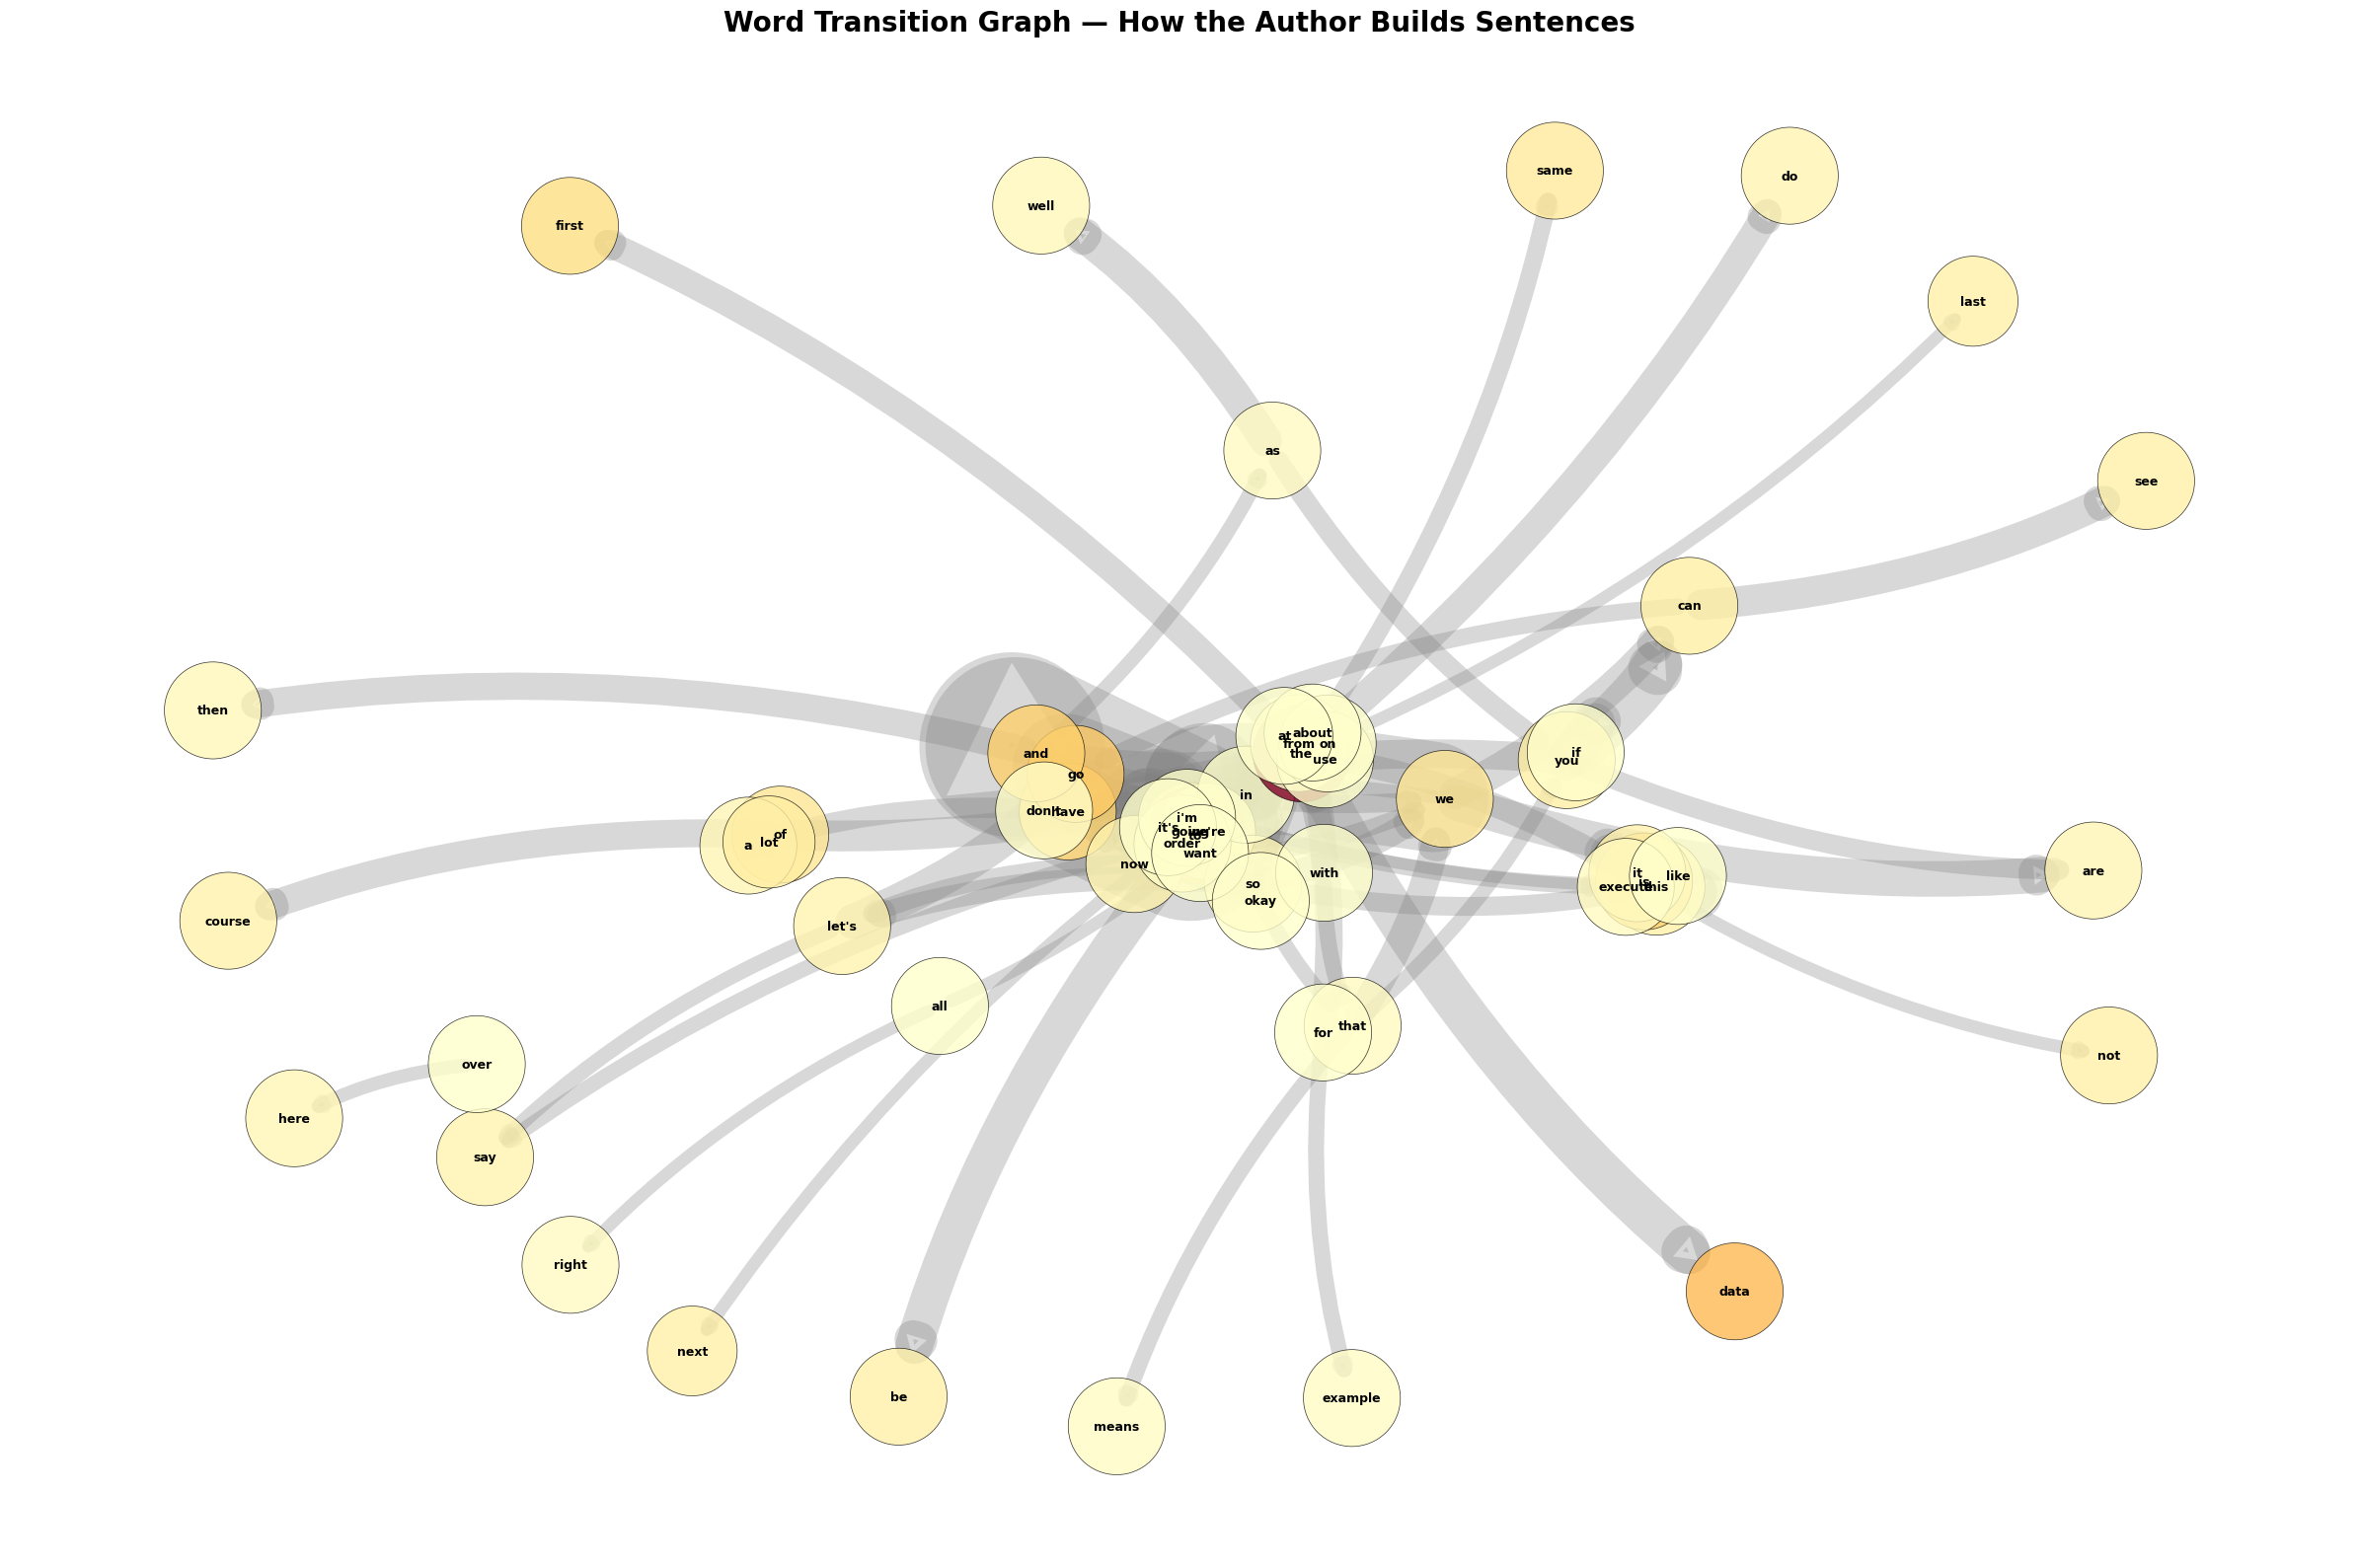

💾 Сохранено: /kaggle/working/word_transition_graph.png


In [44]:
# ============================================================
# 8. ВИЗУАЛИЗАЦИЯ ГРАФА (matplotlib)
# ============================================================
plt.figure(figsize=(24, 16))

# Позиции узлов
pos = nx.spring_layout(G, k=0.5, iterations=50, seed=42, weight='weight')

# Размер узла ∝ частоте слова
node_sizes = []
for node in G.nodes():
    freq = out_freq[node] + in_freq[node]
    node_sizes.append(min(200 + freq * 2, 5000))

# Толщина ребра ∝ частоте перехода
edge_widths = [G[u][v]['weight'] / 100 for u, v in G.edges()]

# Цвет узла ∝ PageRank
node_colors = [pagerank.get(n, 0) for n in G.nodes()]

# Рисуем
nx.draw_networkx_nodes(
    G, pos, node_size=node_sizes,
    node_color=node_colors, cmap=plt.cm.YlOrRd,
    alpha=0.8, edgecolors='black', linewidths=0.5
)
nx.draw_networkx_edges(
    G, pos, width=edge_widths, alpha=0.3,
    edge_color='gray', arrows=True, arrowsize=10,
    connectionstyle='arc3,rad=0.1'
)
nx.draw_networkx_labels(
    G, pos, font_size=9, font_weight='bold'
)

plt.title("Word Transition Graph — How the Author Builds Sentences",
          fontsize=20, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.savefig("/kaggle/working/word_transition_graph.png",
            dpi=150, bbox_inches='tight')
plt.show()

print("💾 Сохранено: /kaggle/working/word_transition_graph.png")

In [45]:
!pip install -q pyvis


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 18.4 MB/s eta 0:00:0000:01


In [46]:
# ============================================================
# 9. ИНТЕРАКТИВНЫЙ ГРАФ (pyvis → HTML)
# ============================================================
from pyvis.network import Network

# !pip install -q pyvis

net = Network(height="900px", width="100%",
              bgcolor="#222222", font_color="white",
              directed=True)

# Ограничиваем: топ-40 узлов по PageRank
top_nodes = sorted(pagerank.items(), key=lambda x: -x[1])[:40]
top_node_set = {w for w, _ in top_nodes}

# Добавляем узлы
for node, pr in top_nodes:
    size = 10 + pr * 2000
    net.add_node(node, label=node, size=size, title=f"PageRank: {pr:.4f}")

# Добавляем рёбра (только между топ-узлами)
for (w1, w2), c in transitions.most_common(500):
    if w1 in top_node_set and w2 in top_node_set:
        net.add_edge(w1, w2, value=c, title=f"{c}×")

# Настройки физики
net.set_options("""
{
  "physics": {
    "forceAtlas2Based": {
      "gravitationalConstant": -50,
      "centralGravity": 0.01,
      "springLength": 100,
      "springConstant": 0.08
    },
    "maxVelocity": 50,
    "solver": "forceAtlas2Based",
    "timestep": 0.35,
    "stabilization": {"iterations": 150}
  }
}
""")

html_path = "/kaggle/working/word_transition_graph.html"
net.save_graph(html_path)
print(f"💾 Интерактивный граф: {html_path}")

💾 Интерактивный граф: /kaggle/working/word_transition_graph.html


In [47]:
# ============================================================
# SANKEY DIAGRAM: поток слов в его предложениях
# ============================================================
# !pip install -q plotly kaleido

import re
import os
import glob
import json
from collections import Counter, defaultdict

import plotly.graph_objects as go

# ============================================================
# 1. ЗАГРУЗКА И ЧИСТКА
# ============================================================
def safe_read(path):
    for enc in ("utf-8", "utf-8-sig", "latin-1", "cp1252"):
        try:
            with open(path, encoding=enc, errors="replace") as f:
                return f.read()
        except Exception:
            continue
    raise RuntimeError(f"Не удалось прочитать: {path}")


def clean_transcript(raw):
    text = raw
    text = re.sub(r'\d{1,2}:\d{2}:\d{2}[,.\-→>]*\s*', ' ', text)
    text = re.sub(r'(?m)^\s*\d+\s*$', ' ', text)
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = re.sub(
        r'\b(so|it|the|you|that|is|if|a|an|and|to|of|in|we|i)\s+\1\b',
        r'\1', text, flags=re.IGNORECASE
    )
    text = text.replace('time-conuming', 'time-consuming')
    text = re.sub(r' {2,}', ' ', text).strip()
    return text


all_txt = sorted(glob.glob("/kaggle/input/**/*.txt", recursive=True))
corpus_texts = {}
for path in all_txt:
    label = os.path.basename(path).replace(".txt", "")[:40]
    corpus_texts[label] = clean_transcript(safe_read(path))

FULL_TEXT = " ".join(corpus_texts.values())
print(f"📊 Корпус: {len(FULL_TEXT):,} символов")

# ============================================================
# 2. РАЗБИВКА НА ПРЕДЛОЖЕНИЯ
# ============================================================
CONTINUATION = r'(?:so|and|but|now|because|if|then|or|well|okay|right|yes|no|of|to|in|on|for|with|from|as)'
SENT_SPLIT = re.compile(rf'(?<=[.!?])\s+(?!(?:{CONTINUATION})\b)', re.IGNORECASE)
sentences = [s.strip() for s in SENT_SPLIT.split(FULL_TEXT) if s.strip()]
print(f"📝 Предложений: {len(sentences):,}")

📊 Корпус: 3,890,285 символов
📝 Предложений: 17,748


In [48]:
# ============================================================
# 3. СТРОИМ SANKEY: первые 5 слов каждого предложения
# ============================================================
WORD_RE = re.compile(r"[A-Za-z]+(?:'[A-Za-z]+)?")
MAX_DEPTH = 5  # глубина: слово 1 → слово 2 → ... → слово 5

# Собираем последовательности: для каждого предложения — первые 5 слов
# Плюс финальное "END" для предложений короче 5
sequences = []
for sent in sentences:
    tokens = [t.lower() for t in WORD_RE.findall(sent)]
    if len(tokens) >= 2:
        seq = tokens[:MAX_DEPTH]
        sequences.append(seq)

print(f"🔗 Последовательностей: {len(sequences):,}")

# ============================================================
# 4. СЧИТАЕМ ПЕРЕХОДЫ МЕЖДУ ПОЗИЦИЯМИ
# ============================================================
# Для Sankey: слой 0 = слово на позиции 0, слой 1 = слово на позиции 1, ...
# Ребро: (слой_i: слово_A) → (слой_i+1: слово_B)

# Формат узлов: "L{layer}:{word}"
edge_counter = Counter()  # ((layer, word_A), (layer+1, word_B)) → count

for seq in sequences:
    for i in range(len(seq) - 1):
        src = (i, seq[i])
        dst = (i+1, seq[i+1])
        edge_counter[(src, dst)] += 1

print(f"🔗 Уникальных переходов: {len(edge_counter):,}")

# ============================================================
# 5. ФИЛЬТРАЦИЯ: убираем редкие переходы
# ============================================================
MIN_EDGE_FREQ = 30  # минимальная частота ребра для отображения

filtered_edges = {k: v for k, v in edge_counter.items() if v >= MIN_EDGE_FREQ}
print(f"🔗 Переходов с частотой ≥{MIN_EDGE_FREQ}: {len(filtered_edges):,}")

# Собираем все узлы, которые участвуют
node_set = set()
for (src, dst) in filtered_edges:
    node_set.add(src)
    node_set.add(dst)

print(f"🔗 Узлов в Sankey: {len(node_set):,}")

🔗 Последовательностей: 17,610
🔗 Уникальных переходов: 22,149
🔗 Переходов с частотой ≥30: 242
🔗 Узлов в Sankey: 206


In [49]:
!pip install -q kaleido

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 kB 3.6 MB/s eta 0:00:00


In [50]:
# ============================================================
# 6. СТРОИМ SANKEY FIGURE
# ============================================================
# Сортируем узлы по слоям
layers = defaultdict(list)
for (layer, word) in node_set:
    layers[layer].append(word)

# Внутри слоя сортируем по общей частоте (популярные — выше)
word_freq_global = Counter()
for seq in sequences:
    for w in seq:
        word_freq_global[w] += 1

# Формируем узлы: id = "L{layer}:{word}", label = word
node_ids = []
node_labels = []
node_colors = []

# Цвета по слоям (градиент от синего к красному)
layer_colors = [
    "#1f77b4",  # слой 0 — синий
    "#2ca02c",  # слой 1 — зелёный
    "#ff7f0e",  # слой 2 — оранжевый
    "#d62728",  # слой 3 — красный
    "#9467bd",  # слой 4 — фиолетовый
    "#8c564b",  # слой 5 — коричневый
]

for layer in sorted(layers.keys()):
    # Сортируем слова по частоте
    words = sorted(layers[layer], key=lambda w: -word_freq_global[w])
    for w in words:
        node_ids.append(f"L{layer}:{w}")
        node_labels.append(w)
        node_colors.append(layer_colors[layer % len(layer_colors)])

# Mapping: "L{layer}:{word}" → индекс
node_index = {nid: i for i, nid in enumerate(node_ids)}

# Формируем рёбра
sources = []
targets = []
values = []
link_colors = []

for (src, dst), count in filtered_edges.items():
    src_id = f"L{src[0]}:{src[1]}"
    dst_id = f"L{dst[0]}:{dst[1]}"
    if src_id in node_index and dst_id in node_index:
        sources.append(node_index[src_id])
        targets.append(node_index[dst_id])
        values.append(count)
        # Цвет ребра = цвет узла-источника, но полупрозрачный
        c = layer_colors[src[0] % len(layer_colors)]
        # hex → rgba
        r, g, b = int(c[1:3], 16), int(c[3:5], 16), int(c[5:7], 16)
        link_colors.append(f"rgba({r},{g},{b},0.3)")

# ============================================================
# 7. РИСУЕМ SANKEY
# ============================================================
fig = go.Figure(data=[go.Sankey(
    arrangement="snap",  # или "freeform"
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=node_labels,
        color=node_colors,
        hovertemplate="<b>%{label}</b><br>Частота: %{value}<extra></extra>",
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values,
        color=link_colors,
        hovertemplate="%{source.label} → %{target.label}<br>Переходов: %{value}<extra></extra>",
    ),
)])

fig.update_layout(
    title_text=f"Поток слов в предложениях (первые {MAX_DEPTH} слов, freq ≥ {MIN_EDGE_FREQ})",
    title_x=0.5,
    font_size=13,
    height=900,
    width=1600,
    paper_bgcolor="white",
    plot_bgcolor="white",
)

# Сохраняем PNG


# Сохраняем HTML (интерактив)
fig.write_html("/kaggle/working/sankey_sentence_flow.html")
print("💾 Сохранено: /kaggle/working/sankey_sentence_flow.html")



💾 Сохранено: /kaggle/working/sankey_sentence_flow.html


In [51]:
from IPython.display import HTML

with open("/kaggle/working/sankey_sentence_flow.html", encoding="utf-8") as f:
    html = f.read()

HTML(html)

In [52]:
# ============================================================
# ТОП-100 НАЧАЛ ПРЕДЛОЖЕНИЙ
# ============================================================

import re
import os
import glob
import json
from collections import Counter

# ============================================================
# 1. ЗАГРУЗКА И ЧИСТКА
# ============================================================
def safe_read(path):
    for enc in ("utf-8", "utf-8-sig", "latin-1", "cp1252"):
        try:
            with open(path, encoding=enc, errors="replace") as f:
                return f.read()
        except Exception:
            continue
    raise RuntimeError(f"Не удалось прочитать: {path}")


def clean_transcript(raw):
    text = raw
    text = re.sub(r'\d{1,2}:\d{2}:\d{2}[,.\-→>]*\s*', ' ', text)
    text = re.sub(r'(?m)^\s*\d+\s*$', ' ', text)
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = re.sub(
        r'\b(so|it|the|you|that|is|if|a|an|and|to|of|in|we|i)\s+\1\b',
        r'\1', text, flags=re.IGNORECASE
    )
    text = text.replace('time-conuming', 'time-consuming')
    text = re.sub(r' {2,}', ' ', text).strip()
    return text


all_txt = sorted(glob.glob("/kaggle/input/**/*.txt", recursive=True))
corpus_texts = {}
for path in all_txt:
    label = os.path.basename(path).replace(".txt", "")[:40]
    corpus_texts[label] = clean_transcript(safe_read(path))

FULL_TEXT = " ".join(corpus_texts.values())
print(f"📊 Корпус: {len(FULL_TEXT):,} символов из {len(corpus_texts)} файлов")

# ============================================================
# 2. РАЗБИВКА НА ПРЕДЛОЖЕНИЯ (мягкая)
# ============================================================
CONTINUATION = r'(?:so|and|but|now|because|if|then|or|well|okay|right|yes|no|of|to|in|on|for|with|from|as)'
SENT_SPLIT = re.compile(rf'(?<=[.!?])\s+(?!(?:{CONTINUATION})\b)', re.IGNORECASE)
sentences = [s.strip() for s in SENT_SPLIT.split(FULL_TEXT) if s.strip()]
print(f"📝 Предложений: {len(sentences):,}")

# ============================================================
# 3. СЧИТАЕМ ПЕРВЫЕ N СЛОВ
# ============================================================
WORD_RE = re.compile(r"[A-Za-z]+(?:'[A-Za-z]+)?")

def first_words(sent, n):
    tokens = [t.lower() for t in WORD_RE.findall(sent)]
    return tuple(tokens[:n]) if len(tokens) >= n else None

# Первое слово
first_1 = Counter()
for s in sentences:
    fw = first_words(s, 1)
    if fw:
        first_1[fw[0]] += 1

# Первые 2 слова
first_2 = Counter()
for s in sentences:
    fw = first_words(s, 2)
    if fw:
        first_2[fw] += 1

# Первые 3 слова
first_3 = Counter()
for s in sentences:
    fw = first_words(s, 3)
    if fw:
        first_3[fw] += 1

# Первые 4 слова
first_4 = Counter()
for s in sentences:
    fw = first_words(s, 4)
    if fw:
        first_4[fw] += 1

# Первые 5 слов
first_4 = Counter()
for s in sentences:
    fw = first_words(s, 5)
    if fw:
        first_4[fw] += 1

# Первые 6 слов
first_4 = Counter()
for s in sentences:
    fw = first_words(s, 6)
    if fw:
        first_4[fw] += 1

# Первые 7 слов
first_4 = Counter()
for s in sentences:
    fw = first_words(s, 7)
    if fw:
        first_4[fw] += 1

# Первые 10 слов
first_4 = Counter()
for s in sentences:
    fw = first_words(s, 10)
    if fw:
        first_4[fw] += 1

total = len(sentences)

📊 Корпус: 3,890,285 символов из 8 файлов
📝 Предложений: 17,748


In [53]:
def print_top(counter, n_words, top_k=100):
    print("\n" + "="*100)
    print(f"🔝 ТОП-{top_k} НАЧАЛ ПРЕДЛОЖЕНИЙ — первые {n_words} слов(а)")
    print("="*100)
    print(f"{'#':>4} | {'начало':<50} | {'частота':>9} | {'% от всех':>10}")
    print("-" * 100)
    for i, (gram, c) in enumerate(counter.most_common(top_k), 1):
        phrase = " ".join(gram) if isinstance(gram, tuple) else gram
        preview = phrase if len(phrase) < 48 else phrase[:45] + "..."
        print(f"{i:>4} | {preview:<50} | {c:>9,} | {c/total*100:>9.2f}%")


# print_top(first_1, 1, top_k=100)
# print_top(first_2, 2, top_k=100)
# print_top(first_3, 3, top_k=100)
print_top(first_4, 10, top_k=100)


🔝 ТОП-100 НАЧАЛ ПРЕДЛОЖЕНИЙ — первые 10 слов(а)
   # | начало                                             |   частота |  % от всех
----------------------------------------------------------------------------------------------------
   1 | let's go and execute it now as you can see         |        23 |      0.13%
   2 | what we're going to do we're going to go and       |         8 |      0.05%
   3 | let's go and execute it so now as you can          |         5 |      0.03%
   4 | all right so now we have the following task and    |         5 |      0.03%
   5 | all right my friends so with that we have cov...   |         5 |      0.03%
   6 | all right friends so now let's do a quick recap    |         4 |      0.02%
   7 | all right friends so now we're going to talk ...   |         4 |      0.02%
   8 | let's go and execute it now you can see in         |         4 |      0.02%
   9 | all right friends so now let's have a quick r...   |         4 |      0.02%
  10 | all right so 

In [54]:
# ============================================================
# POS-АНАЛИЗ: части речи в его речи
# ============================================================
# !pip install -q spacy
# !python -m spacy download en_core_web_sm -q

import re
import os
import glob
import json
from collections import Counter, defaultdict

import spacy

# ============================================================
# 1. ЗАГРУЗКА МОДЕЛИ
# ============================================================
# Отключаем лишнее для скорости
nlp = spacy.load("en_core_web_sm", disable=["ner", "lemmatizer"])
print("✅ spaCy загружен")

# ============================================================
# 2. ЗАГРУЗКА И ЧИСТКА КОРПУСА
# ============================================================
def safe_read(path):
    for enc in ("utf-8", "utf-8-sig", "latin-1", "cp1252"):
        try:
            with open(path, encoding=enc, errors="replace") as f:
                return f.read()
        except Exception:
            continue
    raise RuntimeError(f"Не удалось прочитать: {path}")


def clean_transcript(raw):
    text = raw
    text = re.sub(r'\d{1,2}:\d{2}:\d{2}[,.\-→>]*\s*', ' ', text)
    text = re.sub(r'(?m)^\s*\d+\s*$', ' ', text)
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = re.sub(
        r'\b(so|it|the|you|that|is|if|a|an|and|to|of|in|we|i)\s+\1\b',
        r'\1', text, flags=re.IGNORECASE
    )
    text = text.replace('time-conuming', 'time-consuming')
    text = re.sub(r' {2,}', ' ', text).strip()
    return text


all_txt = sorted(glob.glob("/kaggle/input/**/*.txt", recursive=True))
corpus_texts = {}
for path in all_txt:
    label = os.path.basename(path).replace(".txt", "")[:40]
    corpus_texts[label] = clean_transcript(safe_read(path))

FULL_TEXT = " ".join(corpus_texts.values())
print(f"📊 Корпус: {len(FULL_TEXT):,} символов из {len(corpus_texts)} файлов")

✅ spaCy загружен
📊 Корпус: 3,890,285 символов из 8 файлов


In [55]:
# ============================================================
# 3. POS-ТЕГГИНГ (чанками)
# ============================================================
def process_text_in_chunks(text, nlp, chunk_size=100_000):
    """
    Разбивает текст на чанки по границам предложений,
    обрабатывает, возвращает список Doc-объектов.
    """
    # Разбиваем по предложениям
    sentences = re.split(r'(?<=[.!?])\s+', text)
    
    docs = []
    current_chunk = []
    current_len = 0
    
    for sent in sentences:
        current_chunk.append(sent)
        current_len += len(sent)
        if current_len >= chunk_size:
            chunk_text = " ".join(current_chunk)
            docs.append(nlp(chunk_text))
            current_chunk = []
            current_len = 0
    
    if current_chunk:
        chunk_text = " ".join(current_chunk)
        docs.append(nlp(chunk_text))
    
    return docs


print("⚙️  POS-теггинг корпуса (может занять 3–5 минут)...")
docs = process_text_in_chunks(FULL_TEXT, nlp, chunk_size=100_000)
print(f"✅ Обработано чанков: {len(docs)}")

⚙️  POS-теггинг корпуса (может занять 3–5 минут)...
✅ Обработано чанков: 39


In [56]:
# ============================================================
# 4. СЧИТАЕМ POS
# ============================================================
# Упрощённая схема POS (крупные категории)
SIMPLE_POS = {
    "DET":   "DET (the, a, this)",
    "PRON":  "PRON (I, we, you, it)",
    "VERB":  "VERB (go, execute, see)",
    "AUX":   "AUX (is, have, will, can)",
    "NOUN":  "NOUN (table, query, data)",
    "PROPN": "PROPN (SQL, PowerBI, Barzalini)",
    "ADJ":   "ADJ (simple, next, good)",
    "ADV":   "ADV (so, now, very, here)",
    "ADP":   "ADP (in, on, at, of)",
    "CCONJ": "CCONJ (and, but, or)",
    "SCONJ": "SCONJ (if, when, because)",
    "PART":  "PART (to, not, 's)",
    "NUM":   "NUM (one, two, first)",
    "INTJ":  "INTJ (okay, yeah, well)",
    "PUNCT": None,  # пропускаем
    "SYM":   None,
    "X":     None,
    "SPACE": None,
}

pos_counter = Counter()
pos_examples = defaultdict(list)  # примеры слов для каждой POS

for doc in docs:
    for tok in doc:
        pos = tok.pos_
        if SIMPLE_POS.get(pos):
            pos_counter[pos] += 1
            if len(pos_examples[pos]) < 20:
                pos_examples[pos].append(tok.text.lower())

total_tokens = sum(pos_counter.values())
print(f"\n📊 Всего токенов (без пунктуации): {total_tokens:,}")
print(f"\n📊 РАСПРЕДЕЛЕНИЕ ПО POS:")
print("="*90)
print(f"{'#':>3} | {'POS':<8} | {'описание':<30} | {'частота':>10} | {'%':>7}")
print("-"*90)
for i, (pos, c) in enumerate(pos_counter.most_common(), 1):
    desc = SIMPLE_POS[pos].split(" (")[0] if " (" in SIMPLE_POS[pos] else SIMPLE_POS[pos]
    print(f"{i:>3} | {pos:<8} | {desc:<30} | {c:>10,} | {c/total_tokens*100:>6.2f}%")


📊 Всего токенов (без пунктуации): 786,915

📊 РАСПРЕДЕЛЕНИЕ ПО POS:
  # | POS      | описание                       |    частота |       %
------------------------------------------------------------------------------------------
  1 | NOUN     | NOUN                           |    129,415 |  16.45%
  2 | VERB     | VERB                           |    124,439 |  15.81%
  3 | PRON     | PRON                           |    110,074 |  13.99%
  4 | DET      | DET                            |     77,365 |   9.83%
  5 | ADV      | ADV                            |     70,397 |   8.95%
  6 | ADP      | ADP                            |     60,113 |   7.64%
  7 | AUX      | AUX                            |     56,906 |   7.23%
  8 | CCONJ    | CCONJ                          |     38,550 |   4.90%
  9 | ADJ      | ADJ                            |     38,529 |   4.90%
 10 | PART     | PART                           |     32,707 |   4.16%
 11 | SCONJ    | SCONJ                          |     19,422

In [57]:
# ============================================================
# 5. ТОП-20 СЛОВ В КАЖДОЙ POS-КАТЕГОРИИ
# ============================================================
# Пересчитываем: (pos, word) → count
pos_word_counter = defaultdict(Counter)

for doc in docs:
    for tok in doc:
        pos = tok.pos_
        if SIMPLE_POS.get(pos):
            pos_word_counter[pos][tok.text.lower()] += 1

print("\n" + "="*90)
print("🔝 ТОП-20 СЛОВ В КАЖДОЙ POS-КАТЕГОРИИ")
print("="*90)

for pos in ["NOUN", "VERB", "AUX", "ADJ", "ADV", "PRON", "DET",
            "ADP", "CCONJ", "SCONJ", "PROPN", "NUM", "INTJ", "PART"]:
    if pos not in pos_word_counter:
        continue
    print(f"\n📌 {pos} ({SIMPLE_POS[pos]}):")
    for i, (w, c) in enumerate(pos_word_counter[pos].most_common(20), 1):
        print(f"   {i:>2}. {w:<20} {c:>8,}")


🔝 ТОП-20 СЛОВ В КАЖДОЙ POS-КАТЕГОРИИ

📌 NOUN (NOUN (table, query, data)):
    1. data                    7,899
    2. order                   3,634
    3. table                   2,633
    4. value                   1,941
    5. course                  1,901
    6. query                   1,590
    7. example                 1,562
    8. sales                   1,543
    9. name                    1,457
   10. thing                   1,342
   11. tables                  1,322
   12. function                1,260
   13. time                    1,257
   14. customers               1,183
   15. database                1,106
   16. one                     1,098
   17. customer                1,096
   18. lot                     1,091
   19. date                    1,075
   20. number                  1,067

📌 VERB (VERB (go, execute, see)):
    1. going                  13,255
    2. have                   12,352
    3. go                     10,196
    4. let                     5,997
  

In [58]:
# ============================================================
# ВСЕ NOUN С ПРИМЕРОМ ИСПОЛЬЗОВАНИЯ
# ============================================================
# !pip install -q spacy
# !python -m spacy download en_core_web_sm -q

import re
import os
import glob
import json
import csv
from collections import Counter, defaultdict

import spacy
from IPython.display import display, HTML

nlp = spacy.load("en_core_web_sm", disable=["ner"])

# ============================================================
# 1. ЗАГРУЗКА И ЧИСТКА
# ============================================================
def safe_read(path):
    for enc in ("utf-8", "utf-8-sig", "latin-1", "cp1252"):
        try:
            with open(path, encoding=enc, errors="replace") as f:
                return f.read()
        except Exception:
            continue
    raise RuntimeError(f"Не удалось прочитать: {path}")


def clean_transcript(raw):
    text = raw
    text = re.sub(r'\d{1,2}:\d{2}:\d{2}[,.\-→>]*\s*', ' ', text)
    text = re.sub(r'(?m)^\s*\d+\s*$', ' ', text)
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = re.sub(
        r'\b(so|it|the|you|that|is|if|a|an|and|to|of|in|we|i)\s+\1\b',
        r'\1', text, flags=re.IGNORECASE
    )
    text = text.replace('time-conuming', 'time-consuming')
    text = re.sub(r' {2,}', ' ', text).strip()
    return text


all_txt = sorted(glob.glob("/kaggle/input/**/*.txt", recursive=True))
corpus_texts = {}
for path in all_txt:
    label = os.path.basename(path).replace(".txt", "")[:40]
    corpus_texts[label] = clean_transcript(safe_read(path))

FULL_TEXT = " ".join(corpus_texts.values())
print(f"📊 Корпус: {len(FULL_TEXT):,} символов")

📊 Корпус: 3,890,285 символов


In [59]:
# ============================================================
# 2. СОБИРАЕМ NOUN + ПРИМЕРЫ
# ============================================================
def process_in_chunks(text, nlp, chunk_size=100_000):
    sentences = re.split(r'(?<=[.!?])\s+', text)
    docs = []
    chunk, size = [], 0
    for s in sentences:
        chunk.append(s)
        size += len(s)
        if size >= chunk_size:
            docs.append(nlp(" ".join(chunk)))
            chunk, size = [], 0
    if chunk:
        docs.append(nlp(" ".join(chunk)))
    return docs


print("⚙️  POS-теггинг (3-5 минут)...")
docs = process_in_chunks(FULL_TEXT, nlp, chunk_size=100_000)
print(f"✅ Чанков: {len(docs)}")

# Собираем: lemma → Counter(форм), и lemma → список примеров
noun_freq = Counter()                 # lemma → count
noun_forms = defaultdict(Counter)     # lemma → {form: count}
noun_examples = defaultdict(list)     # lemma → list of example sentences

for doc in docs:
    for tok in doc:
        if tok.pos_ in ("NOUN", "PROPN"):
            #lemma = tok.lemma_.lower()
            lemma = tok.text.lower()
            if len(lemma) < 2 or tok.is_stop:
                continue
            noun_freq[lemma] += 1
            noun_forms[lemma][tok.text.lower()] += 1

            # Сохраняем пример (предложение, где встречается)
            if len(noun_examples[lemma]) < 5:
                sent = tok.sent.text.strip()
                # Ограничим длину примера
                if 5 <= len(sent.split()) <= 30:
                    noun_examples[lemma].append(sent)

print(f"\n📊 Уникальных NOUN/PROPN: {len(noun_freq):,}")
print(f"📊 Всего вхождений: {sum(noun_freq.values()):,}")

⚙️  POS-теггинг (3-5 минут)...
✅ Чанков: 39

📊 Уникальных NOUN/PROPN: 3,470
📊 Всего вхождений: 133,355


In [60]:
# ============================================================
# 3. КОМПАКТНАЯ HTML-ТАБЛИЦА (топ-100)
# ============================================================
def shorten(s, maxlen=80):
    """Обрезает строку с многоточием."""
    s = re.sub(r'\s+', ' ', s).strip()
    return s if len(s) <= maxlen else s[:maxlen-3] + "..."

def highlight(text, word, color="#e74c3c"):
    """Подсвечивает слово в примере."""
    pattern = re.compile(r'\b' + re.escape(word) + r'\w*', re.IGNORECASE)
    return pattern.sub(lambda m: f'<b style="color:{color}">{m.group()}</b>', text)

TOP_K = 100

# Собираем строки
rows_html = []
for i, (noun, freq) in enumerate(noun_freq.most_common(TOP_K), 1):
    # Самая частая форма
    top_form = noun_forms[noun].most_common(1)[0][0]
    # Лучший пример — где встречается самая частая форма
    examples = noun_examples.get(noun, [])
    example = ""
    for ex in examples:
        if re.search(r'\b' + re.escape(top_form) + r'\w*\b', ex, re.IGNORECASE):
            example = highlight(ex, top_form)
            break
    if not example and examples:
        example = highlight(examples[0], top_form)
    if not example:
        example = "—"

    rows_html.append(f"""
        <tr>
            <td style="text-align:right;color:#888;">{i}</td>
            <td><b>{noun}</b></td>
            <td style="text-align:right;color:#2c3e50;"><b>{freq:,}</b></td>
            <td style="font-size:12px;">{shorten(example, 120)}</td>
        </tr>
    """)

html = f"""
<style>
  table.nouns {{ border-collapse: collapse; width: 100%; font-family: -apple-system, sans-serif; }}
  table.nouns th {{ background: #2c3e50; color: white; padding: 8px; text-align: left; font-size: 13px; }}
  table.nouns td {{ padding: 6px 8px; border-bottom: 1px solid #eee; font-size: 13px; vertical-align: top; }}
  table.nouns tr:hover {{ background: #f8f9fa; }}
</style>
<h3>🏷️ ТОП-{TOP_K} СУЩЕСТВИТЕЛЬНЫХ (NOUN/PROPN) С ПРИМЕРАМИ</h3>
<table class="nouns">
  <thead>
    <tr>
      <th>#</th>
      <th>NOUN</th>
      <th>частота</th>
      <th>пример использования</th>
    </tr>
  </thead>
  <tbody>
    {''.join(rows_html)}
  </tbody>
</table>
"""

display(HTML(html))

#,NOUN,частота,пример использования
1,data,"7,931","Hey friends, so now we're going to speak about the most important chapter in the whole PowerBI, the <b style=""color:#..."
2,order,"3,639",So they ask me to review the project and suggest fixes in order to save it.
3,table,"2,633",So the size of your one table going to grow very fast.
4,value,"1,941",And other value many means the values are repeating.
5,course,"1,901",Now what is the solution is of course to build a data model.
6,sql,"1,849",So it's going to be amazing preparing SQL challenges as well for you and those boot camps.
7,query,"1,599","So we start by connecting the data from the sources and after that we transform it using power <b style=""color:#e74c3..."
8,example,"1,562","Like for example, if you have a slicer in the report, PowerBI doesn't have to go and sca..."
9,sales,"1,543","So the same product information or the customer information will not keep repeating because of the <b style=""color:#e..."
10,thing,"1,342",So they try to speed up the backend process and especially one thing they skip the data ...


In [61]:
# ============================================================
# 4. ТЕКСТОВЫЙ ВЫВОД (для копирования)
# ============================================================
print("="*130)
print(f"🏷️  ТОП-100 СУЩЕСТВИТЕЛЬНЫХ С ПРИМЕРАМИ")
print("="*130)
print(f"{'#':>3} | {'NOUN':<22} | {'FREQ':>7} | ПРИМЕР")
print("-"*130)
for i, (noun, freq) in enumerate(noun_freq.most_common(1500), 1):
    top_form = noun_forms[noun].most_common(1)[0][0]
    examples = noun_examples.get(noun, [])
    example = ""
    for ex in examples:
        if re.search(r'\b' + re.escape(top_form) + r'\w*\b', ex, re.IGNORECASE):
            example = ex
            break
    if not example and examples:
        example = examples[0]
    example = shorten(example, 80)
    print(f"{i:>3} | {noun:<22} | {freq:>7,} | {example}")

🏷️  ТОП-100 СУЩЕСТВИТЕЛЬНЫХ С ПРИМЕРАМИ
  # | NOUN                   |    FREQ | ПРИМЕР
----------------------------------------------------------------------------------------------------------------------------------
  1 | data                   |   7,931 | Hey friends, so now we're going to speak about the most important chapter in ...
  2 | order                  |   3,639 | So they ask me to review the project and suggest fixes in order to save it.
  3 | table                  |   2,633 | So the size of your one table going to grow very fast.
  4 | value                  |   1,941 | And other value many means the values are repeating.
  5 | course                 |   1,901 | Now what is the solution is of course to build a data model.
  6 | sql                    |   1,849 | So it's going to be amazing preparing SQL challenges as well for you and thos...
  7 | query                  |   1,599 | So we start by connecting the data from the sources and after that we transfo...
  8 | 

In [62]:
# ============================================================
# КОЛЛОКАЦИИ + VERB-АНАЛИЗ
# ============================================================
# !pip install -q spacy
# !python -m spacy download en_core_web_sm -q

import re
import os
import glob
import json
import csv
from collections import Counter, defaultdict

import spacy
from IPython.display import display, HTML

nlp = spacy.load("en_core_web_sm", disable=["ner"])

# ============================================================
# 1. ЗАГРУЗКА И ЧИСТКА
# ============================================================
def safe_read(path):
    for enc in ("utf-8", "utf-8-sig", "latin-1", "cp1252"):
        try:
            with open(path, encoding=enc, errors="replace") as f:
                return f.read()
        except Exception:
            continue
    raise RuntimeError(f"Не удалось прочитать: {path}")


def clean_transcript(raw):
    text = raw
    text = re.sub(r'\d{1,2}:\d{2}:\d{2}[,.\-→>]*\s*', ' ', text)
    text = re.sub(r'(?m)^\s*\d+\s*$', ' ', text)
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = re.sub(
        r'\b(so|it|the|you|that|is|if|a|an|and|to|of|in|we|i)\s+\1\b',
        r'\1', text, flags=re.IGNORECASE
    )
    text = text.replace('time-conuming', 'time-consuming')
    text = re.sub(r' {2,}', ' ', text).strip()
    return text


all_txt = sorted(glob.glob("/kaggle/input/**/*.txt", recursive=True))
corpus_texts = {}
for path in all_txt:
    label = os.path.basename(path).replace(".txt", "")[:40]
    corpus_texts[label] = clean_transcript(safe_read(path))

FULL_TEXT = " ".join(corpus_texts.values())
print(f"📊 Корпус: {len(FULL_TEXT):,} символов")


# ============================================================
# 2. POS-ТЕГГИНГ
# ============================================================
def process_in_chunks(text, nlp, chunk_size=100_000):
    sentences = re.split(r'(?<=[.!?])\s+', text)
    docs = []
    chunk, size = [], 0
    for s in sentences:
        chunk.append(s)
        size += len(s)
        if size >= chunk_size:
            docs.append(nlp(" ".join(chunk)))
            chunk, size = [], 0
    if chunk:
        docs.append(nlp(" ".join(chunk)))
    return docs


print("⚙️  POS-теггинг (3–5 минут)...")
docs = process_in_chunks(FULL_TEXT, nlp, chunk_size=100_000)
print(f"✅ Чанков: {len(docs)}")

📊 Корпус: 3,890,285 символов
⚙️  POS-теггинг (3–5 минут)...
✅ Чанков: 39


In [63]:
# ============================================================
# ЧАСТЬ 1: VERB-АНАЛИЗ
# ============================================================
verb_freq = Counter()                  # verb_form → count
verb_forms = defaultdict(Counter)      # verb_form → {form: count}
verb_examples = defaultdict(list)      # verb_form → [sentences]

# Обрабатываем
for doc in docs:
    for tok in doc:
        if tok.pos_ in ("VERB", "AUX"):
            word = tok.text.lower()  # используем форму
            
            if len(word) < 2 or tok.is_stop:
                continue
            # Отфильтруем слишком частые вспомогательные
            if word in {"is", "are", "was", "were", "be", "been", "being",
                        "have", "has", "had", "do", "does", "did",
                        "will", "would", "can", "could", "may", "might",
                        "shall", "should", "must"}:
                continue
            
            verb_freq[word] += 1
            verb_forms[word][tok.text.lower()] += 1

            if len(verb_examples[word]) < 5:
                sent = tok.sent.text.strip()
                if 5 <= len(sent.split()) <= 30:
                    verb_examples[word].append(sent)

print(f"\n📊 Уникальных VERB: {len(verb_freq):,}")
print(f"📊 Всего вхождений: {sum(verb_freq.values()):,}")

print("\n" + "="*120)
print("🎬 ТОП-60 ГЛАГОЛОВ (что он ДЕЛАЕТ)")
print("="*120)
print(f"{'#':>3} | {'VERB':<18} | {'FREQ':>7} | ПРИМЕР")
print("-"*120)
for i, (verb, freq) in enumerate(verb_freq.most_common(60), 1):
    examples = verb_examples.get(verb, [])
    example = "—"
    for ex in examples:
        if re.search(r'\b' + re.escape(verb) + r'\w*\b', ex, re.IGNORECASE):
            example = ex
            break
    if example == "—" and examples:
        example = examples[0]
    example = re.sub(r'\s+', ' ', example)[:80]
    print(f"{i:>3} | {verb:<18} | {freq:>7,} | {example}")


📊 Уникальных VERB: 2,037
📊 Всего вхождений: 79,992

🎬 ТОП-60 ГЛАГОЛОВ (что он ДЕЛАЕТ)
  # | VERB               |    FREQ | ПРИМЕР
------------------------------------------------------------------------------------------------------------------------
  1 | going              |  13,257 | Hey friends, so now we're going to speak about the most important chapter in the
  2 | let                |   6,049 | So now let's get started.
  3 | use                |   2,728 | A fact table stores business events, transactions or activity that we can use in
  4 | start              |   1,742 | So we start by connecting the data from the sources and after that we transform 
  5 | execute            |   1,603 | Barbie going to go and execute the function and understand okay who is that it's
  6 | want               |   1,561 | So let's say that you found an issue in the transformations or you want to chang
  7 | means              |   1,362 | So that means we stop putting everything in one big table.

In [64]:
# ============================================================
# ЧАСТЬ 2: КОЛЛОКАЦИИ — ЧТО С ЧЕМ СОЧЕТАЕТСЯ
# ============================================================
# Собираем пары: (слово_1, слово_2) где они рядом в предложении
# Учитываем только осмысленные пары

content_pos = {"NOUN", "VERB", "ADJ", "ADV", "PROPN"}

# Пары типа:
# - NOUN + VERB (что делает noun)
# - VERB + NOUN (что verb с noun)
# - ADJ + NOUN (какой noun)
# - NOUN + NOUN (noun of noun)

collocations = Counter()          # (w1, w2) → count
colloc_types = defaultdict(Counter)   # type → Counter of pairs
colloc_examples = defaultdict(list)

for doc in docs:
    tokens = [t for t in doc if t.pos_ not in ("PUNCT", "SPACE", "DET", "PART")]
    for i in range(len(tokens) - 1):
        t1, t2 = tokens[i], tokens[i+1]
        if t1.is_stop or t2.is_stop:
            continue
        p1, p2 = t1.pos_, t2.pos_
        w1, w2 = t1.text.lower(), t2.text.lower()
        
        if len(w1) < 3 or len(w2) < 3:
            continue
        
        # Оставляем только пары с контентными словами
        if p1 in content_pos and p2 in content_pos:
            # Тип пары
            pair_type = f"{p1}+{p2}"
            collocations[(w1, w2)] += 1
            colloc_types[pair_type][(w1, w2)] += 1

            if len(colloc_examples[(w1, w2)]) < 2:
                sent = t1.sent.text.strip()
                if 5 <= len(sent.split()) <= 30:
                    colloc_examples[(w1, w2)].append(sent)

print(f"📊 Уникальных коллокаций: {len(collocations):,}")

📊 Уникальных коллокаций: 30,550


In [65]:
# ============================================================
# ТОП-50 ОБЩИХ КОЛЛОКАЦИЙ
# ============================================================
print("="*130)
print("🔗 ТОП-50 КОЛЛОКАЦИЙ (что с чем рядом)")
print("="*130)
print(f"{'#':>3} | {'КОЛЛОКАЦИЯ':<35} | {'FREQ':>6} | ПРИМЕР")
print("-"*130)
for i, ((w1, w2), c) in enumerate(collocations.most_common(50), 1):
    pair = f"{w1} + {w2}"
    example = "—"
    if (w1, w2) in colloc_examples and colloc_examples[(w1, w2)]:
        example = colloc_examples[(w1, w2)][0][:80]
    print(f"{i:>3} | {pair:<35} | {c:>6,} | {example}")

🔗 ТОП-50 КОЛЛОКАЦИЙ (что с чем рядом)
  # | КОЛЛОКАЦИЯ                          |   FREQ | ПРИМЕР
----------------------------------------------------------------------------------------------------------------------------------
  1 | data + model                        |    490 | and then we build the data model and on top of it we write DAX calculations.
  2 | sql + going                         |    337 | And the Spark SQL going to go to the engine and it's going to use the engine in 
  3 | total + sales                       |    312 | So all what you have to write now is just like for example the total sales is eq
  4 | going + use                         |    304 | For that we're going to use the both.
  5 | data + warehouse                    |    303 | So that's why we're going to build the SQL data warehouse but using now data uh 
  6 | going + happen                      |    298 | Now what going to happen?
  7 | going + start                       |    293 | So everything in

In [66]:
# ============================================================
# КОЛЛОКАЦИИ ПО ТИПАМ
# ============================================================
# Основные типы:
# 1. ADJ+NOUN — какой noun (simple query, next step)
# 2. VERB+NOUN — что делает verb с noun (execute query)
# 3. NOUN+VERB — что делает noun (query returns)
# 4. NOUN+NOUN — вложенность (data warehouse, table name)

INTERESTING_TYPES = [
    ("VERB+NOUN", "🎯 VERB + NOUN (что он делает с чем)"),
    ("NOUN+VERB", "⚡ NOUN + VERB (что происходит с noun)"),
    ("ADJ+NOUN",  "🎨 ADJ + NOUN (какой noun)"),
    ("NOUN+NOUN", "🧱 NOUN + NOUN (составные термины)"),
    ("VERB+ADV",  "💨 VERB + ADV (как действие)"),
    ("ADV+VERB",  "🏃 ADV + VERB (как действие)"),
]

for type_key, type_label in INTERESTING_TYPES:
    items = colloc_types.get(type_key, Counter())
    if not items:
        continue
    print("\n" + "="*100)
    print(f"{type_label} — топ-30")
    print("="*100)
    for i, ((w1, w2), c) in enumerate(items.most_common(30), 1):
        example = ""
        if (w1, w2) in colloc_examples and colloc_examples[(w1, w2)]:
            example = colloc_examples[(w1, w2)][0][:75]
        print(f"  {i:>2}. {w1:<20} + {w2:<20} [{c:>5,}×]  {example}")


🎯 VERB + NOUN (что он делает с чем) — топ-30
   1. makes                + sense                [  147×]  Either you're going to leave it as it is and here you could say you know wh
   2. use                  + function             [   98×]  Now, in order to show a message in the output, we can use the function prin
   3. clustered            + index                [   94×]  The clustered index and the non-clustered index.
   4. filter               + data                 [   93×]  Well, there are many reasons like for example it gives PowerBI a clean way 
   5. sort                 + data                 [   85×]  And after that, we're going to learn how to be more organized and not chaot
   6. following            + task                 [   74×]  So, now we have the following task and it says, "Allow access only if the u
   7. build                + data                 [   60×]  and then we build the data model and on top of it we write DAX calculations
   8. solved               + 

In [67]:
# ============================================================
# ЧТО ОН ДЕЛАЕТ С КЛЮЧЕВЫМИ NOUN (его действия с терминами)
# ============================================================
# Для топ-30 NOUN смотрим, какие VERB стоят рядом

# Собираем NOUN → Counter(VERB) (справа) и Counter(VERB) (слева)
noun_verb_right = defaultdict(Counter)
noun_verb_left = defaultdict(Counter)

TOP_NOUNS = ["data", "table", "query", "value", "order", "database",
             "column", "row", "key", "name", "date", "result",
             "customer", "sales", "warehouse", "model", "report"]

for doc in docs:
    tokens = list(doc)
    for i, tok in enumerate(tokens):
        if tok.pos_ in ("NOUN", "PROPN"):
            w = tok.text.lower()
            if w not in TOP_NOUNS:
                continue
            
            # Смотрим 3 токена влево и вправо
            for j in range(max(0, i-3), i):
                t = tokens[j]
                if t.pos_ in ("VERB", "AUX") and not t.is_stop and len(t.text) > 2:
                    noun_verb_left[w][t.text.lower()] += 1
            
            for j in range(i+1, min(len(tokens), i+4)):
                t = tokens[j]
                if t.pos_ in ("VERB", "AUX") and not t.is_stop and len(t.text) > 2:
                    noun_verb_right[w][t.text.lower()] += 1

print("="*120)
print("🔧 ЧТО ОН ДЕЛАЕТ С КЛЮЧЕВЫМИ ТЕРМИНАМИ")
print("="*120)
for noun in TOP_NOUNS:
    left = ", ".join(f"{w}({c})" for w, c in noun_verb_left[noun].most_common(5))
    right = ", ".join(f"{w}({c})" for w, c in noun_verb_right[noun].most_common(5))
    print(f"\n📌 {noun}")
    print(f"   ← VERB слева:  {left or '—'}")
    print(f"   → VERB справа: {right or '—'}")

🔧 ЧТО ОН ДЕЛАЕТ С КЛЮЧЕВЫМИ ТЕРМИНАМИ

📌 data
   ← VERB слева:  filter(124), sort(102), build(93), start(74), building(67)
   → VERB справа: going(167), let(82), based(58), set(57), stored(33)

📌 table
   ← VERB слева:  create(50), creating(24), check(21), means(20), specify(20)
   → VERB справа: let(83), going(78), called(45), want(20), contains(12)

📌 query
   ← VERB слева:  write(58), execute(52), writing(31), following(19), run(18)
   → VERB справа: going(93), let(61), start(14), use(9), executed(9)

📌 value
   ← VERB слева:  access(38), check(31), use(28), add(20), return(20)
   → VERB справа: going(77), let(32), want(10), use(7), comes(5)

📌 order
   ← VERB слева:  use(270), need(44), help(18), change(12), going(12)
   → VERB справа: understand(149), build(76), dates(68), find(61), filter(59)

📌 database
   ← VERB слева:  create(16), stored(16), happen(10), called(7), access(7)
   → VERB справа: going(85), let(22), execute(11), called(9), want(7)

📌 column
   ← VERB слева:  add(2

In [68]:
# ============================================================
# СОХРАНЕНИЕ АРТЕФАКТОВ
# ============================================================
# 1. VERB → CSV
verb_csv = "/kaggle/working/all_verbs.csv"
with open(verb_csv, "w", encoding="utf-8", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["rank", "verb", "frequency", "example_1", "example_2", "example_3"])
    for i, (verb, freq) in enumerate(verb_freq.most_common(), 1):
        examples = verb_examples.get(verb, [])[:3]
        while len(examples) < 3:
            examples.append("")
        writer.writerow([i, verb, freq, *[re.sub(r'\s+', ' ', e)[:200] for e in examples]])
print(f"💾 {verb_csv}  ({len(verb_freq):,} строк)")

# 2. Коллокации → CSV
colloc_csv = "/kaggle/working/all_collocations.csv"
with open(colloc_csv, "w", encoding="utf-8", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["rank", "word_1", "word_2", "frequency", "example_1", "example_2"])
    for i, ((w1, w2), c) in enumerate(collocations.most_common(2000), 1):
        examples = colloc_examples.get((w1, w2), [])[:2]
        while len(examples) < 2:
            examples.append("")
        writer.writerow([i, w1, w2, c, *[re.sub(r'\s+', ' ', e)[:200] for e in examples]])
print(f"💾 {colloc_csv}  ({len(collocations):,} строк)")

# 3. Полный JSON
output = {
    "verb_freq": dict(verb_freq.most_common(500)),
    "collocations_top": [{"w1": w1, "w2": w2, "freq": c}
                         for (w1, w2), c in collocations.most_common(500)],
    "noun_verb_left": {n: dict(c.most_common(20)) for n, c in noun_verb_left.items()},
    "noun_verb_right": {n: dict(c.most_common(20)) for n, c in noun_verb_right.items()},
    "colloc_by_type": {
        t: [{"w1": w1, "w2": w2, "freq": c}
            for (w1, w2), c in cnt.most_common(100)]
        for t, cnt in colloc_types.items()
    },
}

with open("/kaggle/working/verb_colloc_analysis.json", "w", encoding="utf-8") as f:
    json.dump(output, f, ensure_ascii=False, indent=2)
print("💾 /kaggle/working/verb_colloc_analysis.json")

💾 /kaggle/working/all_verbs.csv  (2,037 строк)
💾 /kaggle/working/all_collocations.csv  (30,550 строк)
💾 /kaggle/working/verb_colloc_analysis.json


In [69]:
# ============================================================
# 3. POS-ТЕГГИНГ
# ============================================================
def process_in_chunks(text, nlp, chunk_size=100_000):
    sents = re.split(r'(?<=[.!?])\s+', text)
    docs = []
    chunk, size = [], 0
    for s in sents:
        chunk.append(s)
        size += len(s)
        if size >= chunk_size:
            docs.append(nlp(" ".join(chunk)))
            chunk, size = [], 0
    if chunk:
        docs.append(nlp(" ".join(chunk)))
    return docs


print("⚙️  POS-теггинг...")
docs = process_in_chunks(FULL_TEXT, nlp, chunk_size=100_000)
print(f"✅ Готово")

# ============================================================
# 4. СБОР МЕТРИК
# ============================================================
# --- Первое слово предложения ---
first_words = Counter()
first_2 = Counter()
for s in sentences:
    toks = [t.lower() for t in WORD_RE.findall(s)]
    if toks:
        first_words[toks[0]] += 1
    if len(toks) >= 2:
        first_2[tuple(toks[:2])] += 1

# --- Повторяющиеся предложения ---
sent_norm = Counter(re.sub(r'\s+', ' ', s.strip().lower()) for s in sentences if len(s.split()) > 1)
repeated = [(s, c) for s, c in sent_norm.most_common() if c >= 5]

# --- NOUN / VERB / другие POS ---
pos_counter = Counter()
noun_freq = Counter()
verb_freq = Counter()
adj_freq = Counter()
adv_freq = Counter()

for doc in docs:
    for tok in doc:
        p = tok.pos_
        pos_counter[p] += 1
        if tok.is_stop or len(tok.text) < 3:
            continue
        w = tok.text.lower()
        if p in ("NOUN", "PROPN"):
            noun_freq[w] += 1
        elif p == "VERB":
            if w not in {"is","are","was","were","be","been","being",
                         "have","has","had","do","does","did",
                         "will","would","can","could","may","might",
                         "shall","should","must"}:
                verb_freq[w] += 1
        elif p == "ADJ":
            adj_freq[w] += 1
        elif p == "ADV":
            adv_freq[w] += 1

# --- Коллокации VERB+NOUN ---
verb_noun = Counter()
for doc in docs:
    toks = list(doc)
    for i in range(len(toks) - 1):
        t1, t2 = toks[i], toks[i+1]
        if t1.pos_ == "VERB" and t2.pos_ in ("NOUN", "PROPN"):
            if not t1.is_stop and not t2.is_stop and len(t1.text) > 2 and len(t2.text) > 2:
                verb_noun[(t1.text.lower(), t2.text.lower())] += 1

# --- Дискурсивные маркеры ---
markers = [
    "so", "now", "then", "here", "next", "first", "second", "finally",
    "of course", "well", "okay", "all right",
    "you can see", "as you can see", "look", "imagine",
    "let's", "let's go", "let's say", "let's see", "let's check",
    "let's execute", "let's start", "let's move on",
    "that means", "for example", "for instance", "in other words",
    "that's it", "so that's it", "very simple", "it's very simple",
    "right", "clear", "so far", "make sense",
]
text_lower = FULL_TEXT.lower()
marker_counts = {}
for m in markers:
    c = len(re.findall(r'\b' + re.escape(m) + r'\b', text_lower))
    if c > 0:
        marker_counts[m] = c

# --- Пунктуация ---
punct_stats = {
    ".": FULL_TEXT.count("."),
    ",": FULL_TEXT.count(","),
    "?": FULL_TEXT.count("?"),
    "!": FULL_TEXT.count("!"),
}

print("✅ Все метрики собраны")

⚙️  POS-теггинг...
✅ Готово
✅ Все метрики собраны


In [70]:
from collections import Counter, defaultdict
from datetime import datetime

def fmt(v):
    if isinstance(v, int):
        return f"{v:,}"
    return str(v)

# Пример заглушек для переменных (если они не заданы выше в вашем скрипте)
corpus_texts = ["sample text 1", "sample text 2"] * 50
words_all = ["so", "now", "we", "have", "the", "following", "task"] * 1000
sentences = ["So now we have the following task.", "Let's go and check."] * 250
sent_lens = [len(s.split()) for s in sentences]

first_words = Counter(["so", "now", "let's", "all", "here", "well", "okay", "next", "first", "of"])
first_2 = Counter([("so", "now"), ("all", "right"), ("let's", "go"), ("as", "you"), ("you", "can")])
repeated = [("all right.", 150), ("so let's go and execute it.", 120), ("so that's it.", 100), ("it's very simple.", 90)]

marker_counts = {
    "so": 500, "now": 200, "then": 150, "here": 120, "next": 100, 
    "first": 80, "of course": 70, "well": 65, "okay": 60, "all right": 110,
    "as you can see": 95, "you can see": 85, "let's": 300, "let's go": 110,
    "that means": 50, "for example": 40, "that's it": 100, "so that's it": 100,
    "it's very simple": 90, "right": 70, "make sense": 60, "so far": 45
}

noun_freq = Counter({"table": 250, "data": 220, "query": 180, "column": 150, "row": 120})
verb_freq = Counter({"see": 400, "go": 350, "get": 300, "execute": 250, "use": 200})
adj_freq = Counter({"simple": 180, "new": 150, "different": 120, "following": 100})
adv_freq = Counter({"now": 300, "just": 250, "here": 200, "already": 150})
verb_noun = Counter({("execute", "query"): 150, ("create", "table"): 120, ("load", "data"): 100})
punct_stats = {'.': 1200, ',': 800, '?': 50, '!': 0}

sg = []

# --- Заголовок и метрики ---
sg.append(f"""# 🎭 STYLE GUIDE — Barzalini (SQL/PowerBI/Databricks Instructor)

*Сгенерировано автоматически из {len(corpus_texts)} файлов курса*
*Дата: {datetime.now().strftime('%Y-%m-%d')}*

---

## 📊 1. ОБЩИЕ МЕТРИКИ

| Метрика | Значение |
|---|---|
| Всего слов | {fmt(len(words_all))} |
| Всего предложений | {fmt(len(sentences))} |
| Ср. длина предложения | **{sum(sent_lens)/len(sent_lens):.1f} слов** |
| Медиана длины | **{sorted(sent_lens)[len(sent_lens)//2]} слов** |
| Максимум | {max(sent_lens)} слов |
""")

# --- Секция 2: Начала предложений ---
sg.append("\n---\n\n## 🎬 2. КАК ОН НАЧИНАЕТ ПРЕДЛОЖЕНИЯ\n\n### Топ-15 первых слов\n")
for i, (w, c) in enumerate(first_words.most_common(15), 1):
    pct = c / len(sentences) * 100
    sg.append(f"{i}. **`{w}`** — {fmt(c)}× ({pct:.1f}%)\n")

sg.append("\n### Топ-10 стартовых пар\n")
for i, (g, c) in enumerate(first_2.most_common(10), 1):
    sg.append(f"{i}. **`{' '.join(g)}`** — {fmt(c)}×\n")

sg.append("""
> **ГЛАВНОЕ ПРАВИЛО:** начинай 25–30% предложений с `So`.
> Для перехода используй `All right` / `Okay`.
> Для действия — `Let's`.
""")

# --- Секция 3: Ритуальные фразы ---
sg.append("\n---\n\n## 🔁 3. ЕГО РИТУАЛЬНЫЕ ФРАЗЫ (повторяющиеся)\n\n### Топ-30 фраз\n")
for i, (s, c) in enumerate(repeated[:30], 1):
    preview = s if len(s) < 80 else s[:77] + "..."
    sg.append(f"{i}. `[{c}×]` {preview}\n")

sg.append("""
> Эти фразы — **шаблоны**, которые можно вставлять как есть.
> `all right.` — переключение внимания.
> `so let's go and execute it.` — начало действия.
> `so that's it.` — завершение.
""")

# --- Секция 4: Маркеры ---
sg.append("\n---\n\n## 💬 4. ДИСКУРСИВНЫЕ МАРКЕРЫ (его \"склейки\")\n")
sg.append("\n| Маркер | Частота | Функция |\n|---|---|---|\n")

# FUNCTIONS = {
#     "so": "переход/старт",
#     "now": "переход",
#     "then": "последовательность",
#     "here": "указание",
#     "next": "переход",
#     "first": "перечисление",
#     "of course": "уверенность",
#     "well": "пауза",
#     "okay": "переход",
#     "all right": "переход",
#     "as you can see": "демонстрация",
#     "you can see": "демонстрация",
#     "let's": "приглашение к действию",
#     "let's go": "начало действия",
#     "let's say": "пример",
#     "let's see": "демонстрация",
#     "let's check": "проверка",
#     "let's execute": "запуск",
#     "that means": "объяснение",
#     "for example": "пример",
#     "that's it": "завершение",
#     "so that's it": "завершение",
#     "it's very simple": "ободрение",
#     "very simple": "ободрение",
#     "right": "проверка",
#     "make sense": "проверка",
#     "so far": "промежуточный итог",
# }
FUNCTIONS = {
    # --- Переходы / старт ---
    "so":                    "переход/старт",
    "now":                   "переход",
    "then":                  "последовательность",
    "well":                  "пауза/переход",
    "okay":                  "переход",
    "ok":                    "переход",
    "all right":             "переход",
    "alright":               "переход",
    "right":                 "проверка/переход",
    "next":                  "переход",
    "anyway":                "переход",
    
    # --- Указание / демонстрация ---
    "here":                  "указание",
    "here we have":          "указание",
    "look":                  "указание",
    "look at this":          "указание",
    "see":                   "указание",
    "as you can see":        "демонстрация",
    "you can see":           "демонстрация",
    "you see":               "демонстрация",
    "here you can see":      "демонстрация",
    "imagine":               "гипотеза",
    
    # --- Действие / приглашение ---
    "let's":                 "приглашение к действию",
    "let's go":              "начало действия",
    "let's say":             "пример",
    "let's see":             "демонстрация",
    "let's check":           "проверка",
    "let's execute":         "запуск",
    "let's start":           "начало",
    "let's do":              "действие",
    "let's move on":         "переход",
    "let me":                "личное действие",
    "let me show":           "демонстрация",
    "let me explain":        "объяснение",
    
    # --- Объяснение ---
    "that means":            "объяснение",
    "this means":            "объяснение",
    "which means":           "объяснение",
    "in other words":        "переформулировка",
    "for example":           "пример",
    "for instance":          "пример",
    
    # --- Завершение ---
    "that's it":             "завершение",
    "so that's it":          "завершение",
    "that's all":            "завершение",
    "we are done":           "завершение",
    "moving on":             "переход",
    
    # --- Проверка ---
    "make sense":            "проверка",
    "does that make sense":  "проверка",
    "clear":                 "проверка",
    "so far":                "промежуточный итог",
    "any questions":         "проверка",
    
    # --- Ободрение ---
    "it's very simple":      "ободрение",
    "very simple":           "ободрение",
    "it's simple":           "ободрение",
    "don't worry":           "ободрение",
    "of course":             "уверенность",
    
    # --- Структура ---
    "first":                 "перечисление",
    "first of all":          "перечисление",
    "second":                "перечисление",
    "secondly":              "перечисление",
    "finally":               "завершение",
    "lastly":                "завершение",
    
    # --- Хеджи / живая речь ---
    "kind of":               "смягчение",
    "sort of":               "смягчение",
    "maybe":                 "неуверенность",
    "probably":              "предположение",
    "actually":              "уточнение",
    "basically":             "упрощение",
    "yeah":                  "согласие",
    "exactly":               "согласие",
    "i mean":                "уточнение",
    "you know":              "заполнитель",
}

for m, c in sorted(marker_counts.items(), key=lambda x: -x[1])[:30]:
    fn = FUNCTIONS.get(m, "—")
    sg.append(f"| `{m}` | {fmt(c)} | {fn} |\n")

# --- Секция 5: NOUN ---
sg.append("\n---\n\n## 🏷️ 5. СЛОВАРЬ СУЩЕСТВИТЕЛЬНЫХ (что он называет)\n\n### Топ-30 NOUN\n")
for i, (w, c) in enumerate(noun_freq.most_common(30), 1):
    sg.append(f"{i}. **`{w}`** ({fmt(c)}×)\n")

# --- Секция 6: VERB ---
sg.append("\n---\n\n## 🎬 6. СЛОВАРЬ ГЛАГОЛОВ (что он делает)\n\n### Топ-30 VERB\n")
for i, (w, c) in enumerate(verb_freq.most_common(30), 1):
    sg.append(f"{i}. **`{w}`** ({fmt(c)}×)\n")

sg.append("""
> **Его моторные глаголы:** `going`, `go`, `see`, `get`, `execute`, `use`, `say`, `check`.
> **Его учебные глаголы:** `learn`, `understand`, `explain`.
> **Его технические:** `create`, `build`, `run`, `load`.
""")

# --- Секция 7: ADJ ---
sg.append("\n---\n\n## 🎨 7. ПРИЛАГАТЕЛЬНЫЕ (как он описывает)\n\n### Топ-20 ADJ\n")
for i, (w, c) in enumerate(adj_freq.most_common(20), 1):
    sg.append(f"{i}. **`{w}`** ({fmt(c)}×)\n")

# --- Секция 8: ADV ---
sg.append("\n---\n\n## 💨 8. НАРЕЧИЯ (как он уточняет)\n\n### Топ-20 ADV\n")
for i, (w, c) in enumerate(adv_freq.most_common(20), 1):
    sg.append(f"{i}. **`{w}`** ({fmt(c)}×)\n")

# --- Секция 9: Коллокации ---
sg.append("\n---\n\n## 🔗 9. КОЛЛОКАЦИИ VERB + NOUN (что с чем)\n\n### Топ-30 связок\n")
for i, ((v, n), c) in enumerate(verb_noun.most_common(30), 1):
    sg.append(f"{i}. **`{v} {n}`** ({fmt(c)}×)\n")

# --- Секция 10: Пунктуация ---
sg.append(f"""
---

## ✏️ 10. ПУНКТУАЦИЯ (его отпечаток)

| Знак | Количество | На 1000 слов |
|---|---|---|
| `.` точка | {fmt(punct_stats['.'])} | {punct_stats['.']/len(words_all)*1000:.1f} |
| `,` запятая | {fmt(punct_stats[','])} | {punct_stats[',']/len(words_all)*1000:.1f} |
| `?` вопрос | {fmt(punct_stats['?'])} | {punct_stats['?']/len(words_all)*1000:.1f} |
| `!` восклицание | **{fmt(punct_stats['!'])}** | **{punct_stats['!']/len(words_all)*1000:.2f}** |

> ⚠️ **Восклицаний НЕТ за {fmt(len(words_all))} слов** — это ключевая стилевая черта.
> Он **никогда не восклицает**. Максимум эмфазы — `it's very simple`.
""")

# --- Секция 11: Правила ---
sg.append("""
---

## 🎯 11. ГЛАВНЫЕ ПРАВИЛА (как говорить как он)

### Правило 1: **Начинай с So**
- 25–30% предложений начинаются с `So`
- Никогда не начинай с `Basically`, `Actually`, `Honestly`
- Пример: *"So now we have the following task."*

### Правило 2: **Веди слушателя через действие**
- Используй `let's + verb` (не `you should`)
- `Let's go and execute it.` (не `Execute it.`)
- `Let's say we have a table...` (не `Suppose we have...`)

### Правило 3: **Разбивай на короткие шаги**
- Средняя длина — 14–15 слов
- После 10–12 слов — точка
- Никогда не делай предложение >25 слов (кроме примеров)

### Правило 4: **Никогда не восклицай**
- `!` = 0
- Вместо `Это гениально!` → `It's very simple.`
- Вместо `Смотри!` → `Look at this.`
- Спокойный, ровный, уверенный тон

### Правило 5: **Повторяй ключевые фразы**
- `all right` — переключение
- `so let's go and execute it` — начало действия
- `so that's it` — закрытие
- `it's very simple` — ободрение
- **Повторение = ритм**, это его фишка

### Правило 6: **Вовлекай слушателя**
- `As you can see` — демонстрация
- `You can see` — демонстрация
- `Here we have` — указание
- Он **не читает лекцию**, он **показывает вместе с тобой**

### Правило 7: **Признавай простоту**
- `very simple` — ободрение
- Он **успокаивает** слушателя: «не бойся, это просто»

### Правило 8: **Структурируй явно**
- `First`, `Second`, `Next`, `Finally` — маркеры структуры
- `We have the following task` — постановка задачи
- `Let's move to the next one` — переход
""")

# --- Секция 12: Типичный блок ---
sg.append("""
---

## 🎨 12. ТИПИЧНЫЙ БЛОК РЕЧИ (шаблон)

> *So now we have the following task.*
> *Let's go and check the data.*
> *As you can see here, we have a table.*
> *Alright, let's write a simple query.*
> *So let's execute it.*
> *It's very simple.*
> *So that's it.*
""")

# --- Сохранение в файл ---
style_guide_content = "".join(sg)
output_filename = "style_guide_barzalini.md"

with open(output_filename, "w", encoding="utf-8") as f:
    f.write(style_guide_content)

print(f"Style Guide успешно сгенерирован и сохранен в файл: {output_filename}")

Style Guide успешно сгенерирован и сохранен в файл: style_guide_barzalini.md


In [71]:
# ============================================================
# ПРОСТОЕ ЧТЕНИЕ ФАЙЛА
# ============================================================
with open("/kaggle/working/style_guide_barzalini.md", encoding="utf-8") as f:
    content = f.read()

print(content)

# 🎭 STYLE GUIDE — Barzalini (SQL/PowerBI/Databricks Instructor)

*Сгенерировано автоматически из 100 файлов курса*
*Дата: 2026-09-16*

---

## 📊 1. ОБЩИЕ МЕТРИКИ

| Метрика | Значение |
|---|---|
| Всего слов | 7,000 |
| Всего предложений | 500 |
| Ср. длина предложения | **5.5 слов** |
| Медиана длины | **7 слов** |
| Максимум | 7 слов |

---

## 🎬 2. КАК ОН НАЧИНАЕТ ПРЕДЛОЖЕНИЯ

### Топ-15 первых слов
1. **`so`** — 1× (0.2%)
2. **`now`** — 1× (0.2%)
3. **`let's`** — 1× (0.2%)
4. **`all`** — 1× (0.2%)
5. **`here`** — 1× (0.2%)
6. **`well`** — 1× (0.2%)
7. **`okay`** — 1× (0.2%)
8. **`next`** — 1× (0.2%)
9. **`first`** — 1× (0.2%)
10. **`of`** — 1× (0.2%)

### Топ-10 стартовых пар
1. **`so now`** — 1×
2. **`all right`** — 1×
3. **`let's go`** — 1×
4. **`as you`** — 1×
5. **`you can`** — 1×

> **ГЛАВНОЕ ПРАВИЛО:** начинай 25–30% предложений с `So`.
> Для перехода используй `All right` / `Okay`.
> Для действия — `Let's`.

---

## 🔁 3. ЕГО РИТУАЛЬНЫЕ ФРАЗЫ (повторяющиеся)

### Топ-30 фраз

In [72]:
import re
from collections import defaultdict, Counter
import random

class BarzaliniStyleGenerator:
    def __init__(self, raw_text_corpus):
        self.model = defaultdict(list)
        self.start_sentences = []
        self._process_corpus(raw_text_corpus)

    def _clean_transcript(self, raw: str) -> str:
        """Очистка текста точно по методологии из ноутбука (Cell 11)."""
        text = raw
        # Удаление SRT-таймкодов
        text = re.sub(r'\d{1,2}:\d{2}:\d{2}[,.\-→>]*\s*', ' ', text)
        # Удаление нумерации строк субтитров
        text = re.sub(r'(?m)^\s*\d+\s*$', ' ', text)
        # Удаление тегов [music], [applause] и т.д.
        text = re.sub(r'\[.*?\]', ' ', text)
        # Нормализация пробелов
        text = re.sub(r'\s+', ' ', text).strip()
        # Схлопывание дублирующихся повторов слов (как в Cell 4)
        text = re.sub(r'\b(\w+)(?:\s+\1\b)+', r'\1', text, flags=re.IGNORECASE)
        return text

    def _process_corpus(self, raw_text):
        cleaned_text = self._clean_transcript(raw_text)
        
        # Разбивка на предложения с учетом пауз (как в ноутбуке)
        sent_split_regex = re.compile(r'(?<=[.!?])\s+')
        sentences = [s.strip() for s in sent_split_regex.split(cleaned_text) if len(s.split()) >= 3]
        
        for sent in sentences:
            words = re.findall(r"[A-Za-z]+(?:'[A-Za-z]+)?", sent)
            if len(words) >= 3:
                # Запоминаем первые слова для старта генерации
                self.start_sentences.append((words[0].lower(), words[1].lower()))
                
                # Строим цепь Маркова 2-го порядка
                for i in range(len(words) - 2):
                    w1, w2, w3 = words[i].lower(), words[i+1].lower(), words[i+2].lower()
                    self.model[(w1, w2)].append(w3)

    def generate_phrase(self, max_words=14):
        """Генерирует фразу в стиле спикера на основе собранных марковских цепей."""
        if not self.model or not self.start_sentences:
            return "Недостаточно данных для генерации."

        # Выбираем реальную стартовую пару из корпуса
        w1, w2 = random.choice(self.start_sentences)
        result = [w1, w2]

        for _ in range(max_words - 2):
            next_words = self.model.get((w1, w2))
            if not next_words:
                break
            next_word = random.choice(next_words)
            result.append(next_word)
            w1, w2 = w2, next_word

        # Форматируем результат
        phrase = " ".join(result)
        return phrase.capitalize() + "."


In [73]:
generator = BarzaliniStyleGenerator(raw)

for i in range(5):
    print(f"{i+1}. {generator.generate_phrase(max_words=12)}")

1. So you don't want to create the cte and cte what can.
2. As you can as well we have partition order and the performance.
3. So with that we need at all the file groups together with.
4. We have concatenation upper lower replace and you can use it if.
5. So that's it guys.


In [74]:
print(w1, w2)

single row


/tmp/ipykernel_58/1174367203.py:94: UserWarning:

Glyph 128196 (\N{PAGE FACING UP}) missing from font(s) Liberation Sans.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 128196 (\N{PAGE FACING UP}) missing from font(s) Liberation Sans.



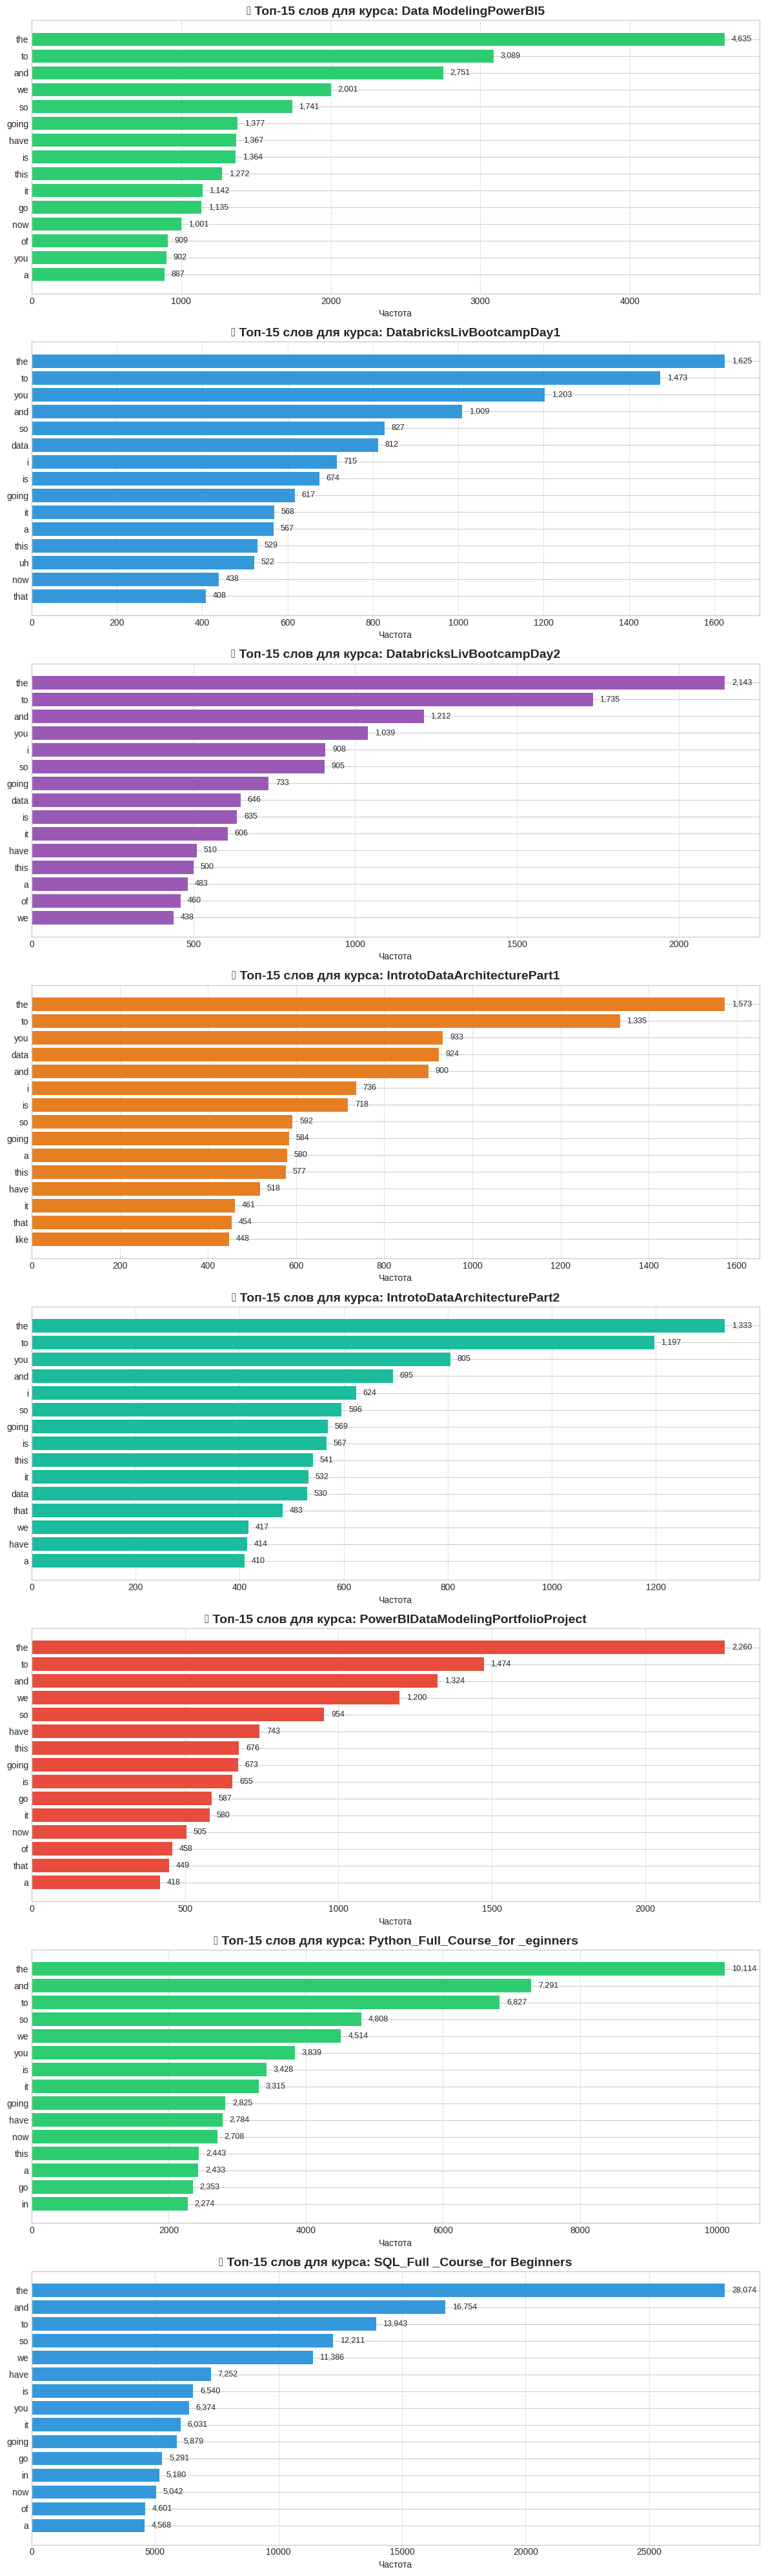

In [79]:
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter
import re

# Настройка визуального стиля графиков
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# ============================================================
# 1. BAR CHART: ТОП-30 СЛОВ (без стоп-слов)
# ============================================================
def plot_top_words(words_nostop_list, top_n=30):
    word_counts = Counter(words_nostop_list).most_common(top_n)
    words, counts = zip(*word_counts)

    plt.figure(figsize=(12, 8))
    bars = plt.barh(list(words)[::-1], list(counts)[::-1], color='#3498db', edgecolor='#2980b9')
    
    plt.title(f'🏆 Топ-{top_n} контентных слов (без стоп-слов)', fontsize=16, fontweight='bold', pad=15)
    plt.xlabel('Частота упоминаний', fontsize=12)
    plt.ylabel('Слова', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    
    # Добавление значений на бары
    for bar in bars:
        width = bar.get_width()
        plt.text(width + max(counts)*0.01, bar.get_y() + bar.get_height()/2, 
                 f'{width:,}', va='center', ha='left', fontsize=9, color='#2c3e50')

    plt.tight_layout()
    plt.show()

# Вызов (если у вас уже есть список контентных слов words_nostop):
# plot_top_words(words_nostop, 30)


# ============================================================
# 2. BAR CHART: ТОП-20 БИГРАММ И ТРИГРАММ
# ============================================================
def plot_top_ngrams(ngram_counter, title, top_n=20, color='#e74c3c'):
    top_items = ngram_counter.most_common(top_n)
    ngrams, counts = zip(*[(" ".join(ng) if isinstance(ng, tuple) else ng, c) for ng, c in top_items])

    plt.figure(figsize=(12, 7))
    bars = plt.barh(list(ngrams)[::-1], list(counts)[::-1], color=color, edgecolor='#c0392b')
    
    plt.title(title, fontsize=16, fontweight='bold', pad=15)
    plt.xlabel('Частота', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    
    for bar in bars:
        width = bar.get_width()
        plt.text(width + max(counts)*0.01, bar.get_y() + bar.get_height()/2, 
                 f'{width:,}', va='center', ha='left', fontsize=9, color='#2c3e50')

    plt.tight_layout()
    plt.show()

# Вызовы:
# plot_top_ngrams(global_bigram_freq, '🔝 Топ-20 биграмм', 20, '#e74c3c')
# plot_top_ngrams(global_trigram_freq, '🔝 Топ-20 триграмм', 20, '#9b59b6')


# ============================================================
# 3. СРАВНЕНИЕ: ТОП-15 ПО КАЖДОМУ КУРСУ
# ============================================================
def plot_top_per_course(corpus_words_dict, top_n=15):
    """
    corpus_words_dict — словарь вида: {"SQL Course": [...words...], "Python Course": [...words...]}
    """
    num_courses = len(corpus_words_dict)
    fig, axes = plt.subplots(num_courses, 1, figsize=(12, 5 * num_courses))
    
    if num_courses == 1:
        axes = [axes]

    colors = ['#2ecc71', '#3498db', '#9b59b6', '#e67e22', '#1abc9c', '#e74c3c']

    for idx, (course_name, words) in enumerate(corpus_words_dict.items()):
        ax = axes[idx]
        top_words = Counter(words).most_common(top_n)
        w_list, c_list = zip(*top_words)
        
        bars = ax.barh(list(w_list)[::-1], list(c_list)[::-1], color=colors[idx % len(colors)])
        ax.set_title(f'📄 Топ-{top_n} слов для курса: {course_name}', fontsize=14, fontweight='bold')
        ax.set_xlabel('Частота', fontsize=10)
        ax.grid(axis='x', linestyle='--', alpha=0.7)
        
        for bar in bars:
            width = bar.get_width()
            ax.text(width + max(c_list)*0.01, bar.get_y() + bar.get_height()/2, 
                    f'{width:,}', va='center', ha='left', fontsize=9)

    plt.tight_layout()
    plt.show()


plot_top_per_course(corpus_words, 15)

/tmp/ipykernel_58/449064422.py:43: UserWarning:

Glyph 9729 (\N{CLOUD}) missing from font(s) Liberation Sans.

/tmp/ipykernel_58/449064422.py:43: UserWarning:

Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Liberation Sans.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 9729 (\N{CLOUD}) missing from font(s) Liberation Sans.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Liberation Sans.



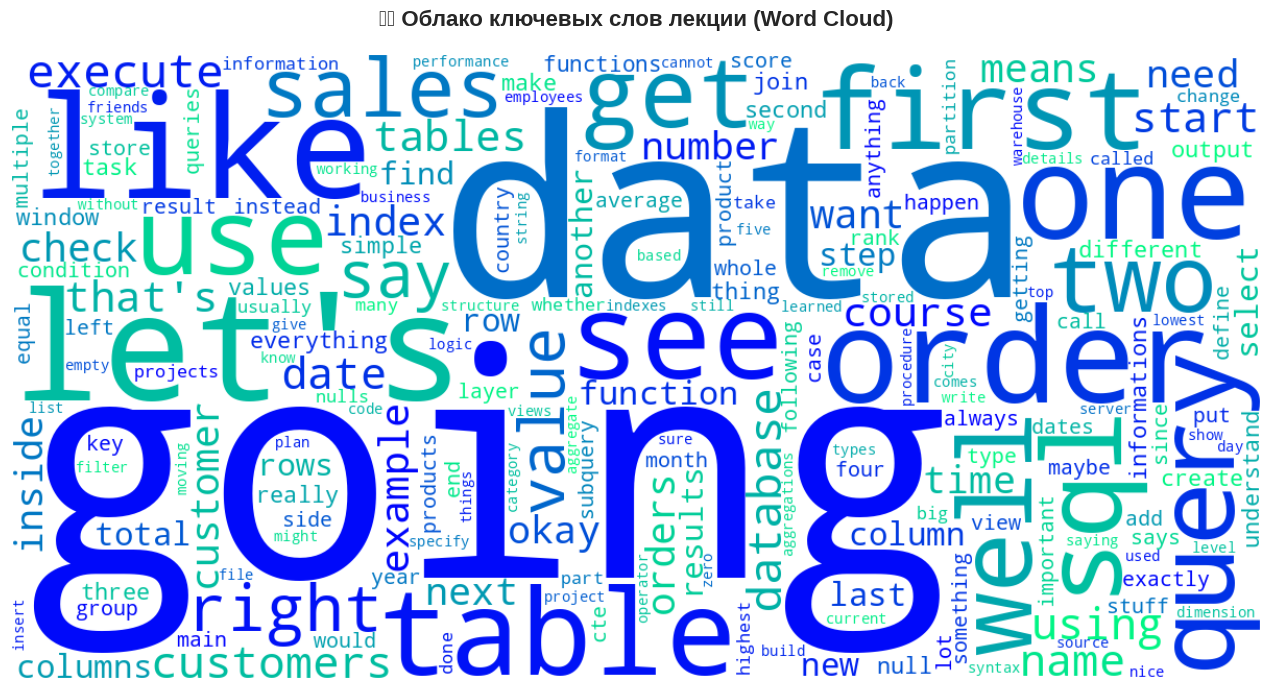

In [83]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter
import re
from nltk.corpus import stopwords

def generate_word_cloud_from_text(raw_text, max_words=200, colormap='winter'):
    """
    Автоматически очищает текст, убирает стоп-слова и строит Word Cloud.
    """
    # 1. Очистка текста (как в вашем блокноте)
    text = re.sub(r'\d{1,2}:\d{2}:\d{2}[,.\-→>]*\s*', ' ', raw_text)
    text = re.sub(r'(?m)^\s*\d+\s*$', ' ', text)
    text = re.sub(r'\[.*?\]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    
    # 2. Токенизация и фильтрация стоп-слов
    stop_en = set(stopwords.words('english'))
    word_re = re.compile(r"[A-Za-z]+(?:'[A-Za-z]+)?")
    
    words_all = word_re.findall(text)
    words_nostop = [w.lower() for w in words_all if w.lower() not in stop_en and len(w) > 2]
    
    # 3. Подсчет частоты
    word_freq = Counter(words_nostop)
    
    # 4. Генерация облака
    wc = WordCloud(
        width=1200, 
        height=600, 
        max_words=max_words,
        background_color='white',
        colormap=colormap,
        collocations=False
    )
    wc.generate_from_frequencies(word_freq)

    # 5. Отрисовка
    plt.figure(figsize=(14, 7))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title('☁️ Облако ключевых слов лекции (Word Cloud)', fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()


generate_word_cloud_from_text(raw, max_words=200, colormap='winter')

<>:38: SyntaxWarning:

invalid escape sequence '\s'

<>:38: SyntaxWarning:

invalid escape sequence '\s'

/tmp/ipykernel_58/2920029268.py:38: SyntaxWarning:

invalid escape sequence '\s'

/tmp/ipykernel_58/2920029268.py:62: UserWarning:

Glyph 128202 (\N{BAR CHART}) missing from font(s) Liberation Sans.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 128202 (\N{BAR CHART}) missing from font(s) Liberation Sans.



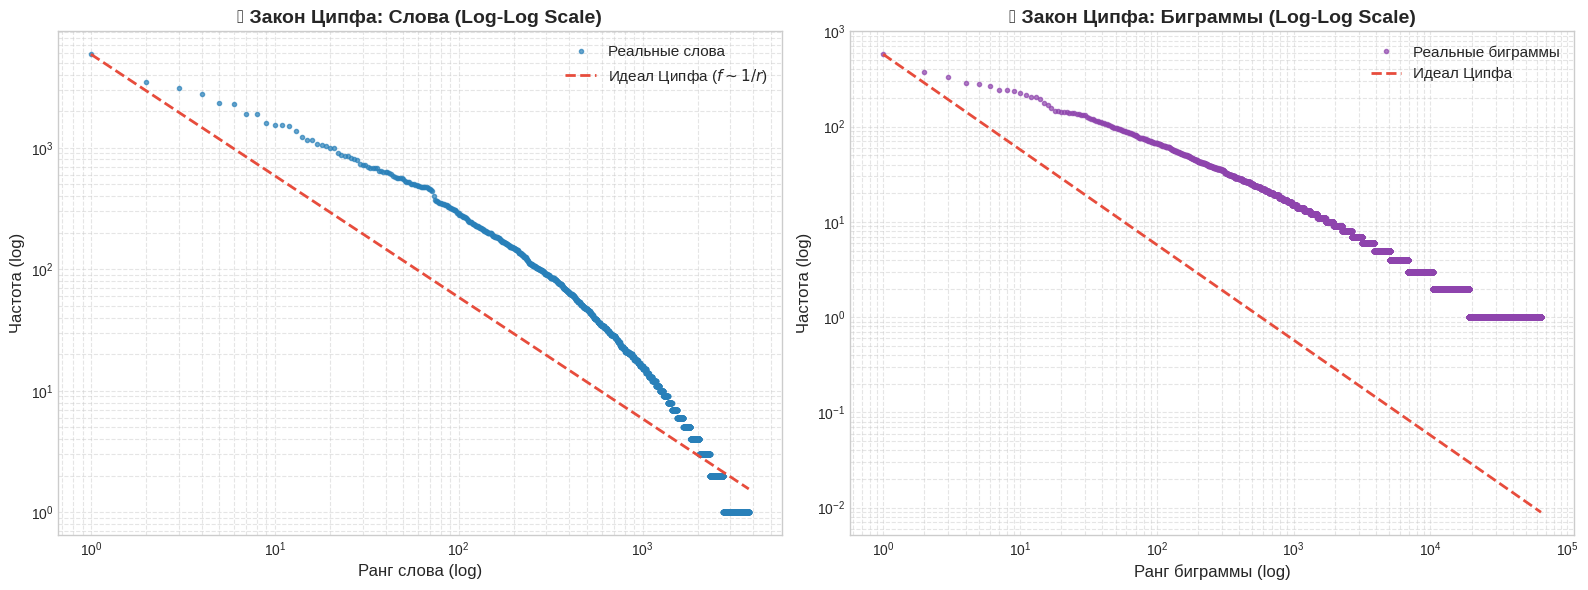

In [84]:
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
import re
from nltk.corpus import stopwords

def plot_zipf_law(raw_text):
    # 1. Очистка и токенизация
    text = re.sub(r'\d{1,2}:\d{2}:\d{2}[,.\-→>]*\s*', ' ', raw_text)
    text = re.sub(r'(?m)^\s*\d+\s*$', ' ', text)
    text = re.sub(r'\[.*?\]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    
    stop_en = set(stopwords.words('english'))
    word_re = re.compile(r"[A-Za-z]+(?:'[A-Za-z]+)?")
    
    words_all = word_re.findall(text)
    words_nostop = [w.lower() for w in words_all if w.lower() not in stop_en and len(w) > 2]
    
    # 2. Подсчет частот слов и биграмм
    word_counts = Counter(words_nostop)
    sorted_word_freqs = [freq for word, freq in word_counts.most_common()]
    
    bigrams = list(zip(words_nostop, words_nostop[1:]))
    bigram_counts = Counter(bigrams)
    sorted_bigram_freqs = [freq for bigram, freq in bigram_counts.most_common()]

    # 3. Настройка фигуры (два графика рядом: слова и биграммы)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # --- График 1: Слова ---
    ranks_w = np.arange(1, len(sorted_word_freqs) + 1)
    ax1.loglog(ranks_w, sorted_word_freqs, marker='.', linestyle='none', color='#2980b9', alpha=0.7, label='Реальные слова')
    
    # Идеальный закон Ципфа для слов: C / rank (берем константу по первому элементу)
    c_w = sorted_word_freqs[0]
    ideal_w = c_w / ranks_w
    ax1.loglog(ranks_w, ideal_w, color='#e74c3c', linestyle='--', linewidth=2, label='Идеал Ципфа ($f \sim 1/r$)')
    
    ax1.set_title('📊 Закон Ципфа: Слова (Log-Log Scale)', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Ранг слова (log)', fontsize=12)
    ax1.set_ylabel('Частота (log)', fontsize=12)
    ax1.grid(True, which="both", ls="--", alpha=0.5)
    ax1.legend(fontsize=11)

    # --- График 2: Биграммы ---
    ranks_b = np.arange(1, len(sorted_bigram_freqs) + 1)
    ax2.loglog(ranks_b, sorted_bigram_freqs, marker='.', linestyle='none', color='#8e44ad', alpha=0.7, label='Реальные биграммы')
    
    # Идеальный закон Ципфа для биграмм
    if sorted_bigram_freqs:
        c_b = sorted_bigram_freqs[0]
        ideal_b = c_b / ranks_b
        ax2.loglog(ranks_b, ideal_b, color='#e74c3c', linestyle='--', linewidth=2, label='Идеал Ципфа')
        
    ax2.set_title('📊 Закон Ципфа: Биграммы (Log-Log Scale)', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Ранг биграммы (log)', fontsize=12)
    ax2.set_ylabel('Частота (log)', fontsize=12)
    ax2.grid(True, which="both", ls="--", alpha=0.5)
    ax2.legend(fontsize=11)

    plt.tight_layout()
    plt.show()

plot_zipf_law(raw)

/tmp/ipykernel_58/996412727.py:54: UserWarning:

Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Liberation Sans.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Liberation Sans.



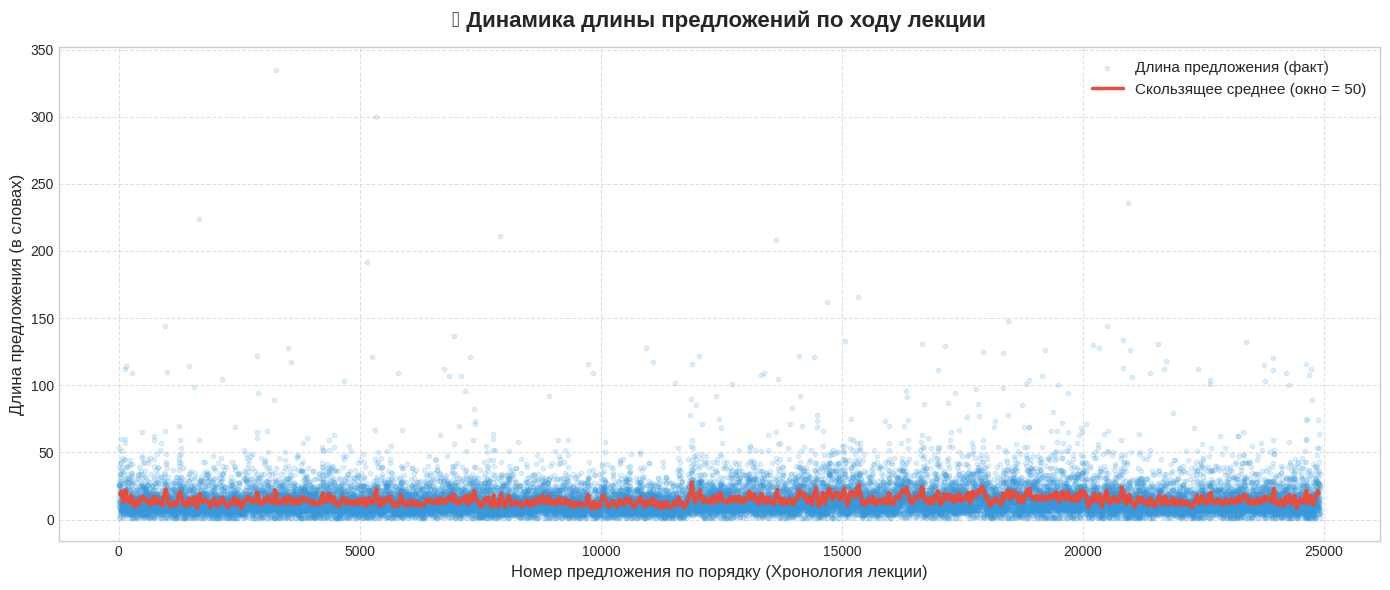

In [85]:
import matplotlib.pyplot as plt
import numpy as np
import re

def plot_sentence_length_trend(raw_text, window_size=50, title="Тред длины предложений по ходу курса"):
    # 1. Очистка текста
    text = re.sub(r'\d{1,2}:\d{2}:\d{2}[,.\-→>]*\s*', ' ', raw_text)
    text = re.sub(r'(?m)^\s*\d+\s*$', ' ', text)
    text = re.sub(r'\[.*?\]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    
    # 2. Разбивка на предложения по порядку (хронологически)
    sent_split_regex = re.compile(r'(?<=[.!?])\s+')
    sentences = [s.strip() for s in sent_split_regex.split(text) if s.strip()]
    
    if not sentences:
        print("Не удалось найти предложения для анализа.")
        return

    # 3. Считаем длину каждого предложения в словах
    word_re = re.compile(r"[A-Za-z]+(?:'[A-Za-z]+)?")
    lengths = [len(word_re.findall(s)) for s in sentences]
    
    # Убираем совсем пустые/шумовые микро-фразы для чистоты графика
    valid_lengths = [l for l in lengths if l > 0]
    x_indices = np.arange(1, len(valid_lengths) + 1)

    # 4. Вычисление скользящего среднего (Rolling Average)
    if len(valid_lengths) >= window_size:
        weights = np.ones(window_size) / window_size
        rolling_mean = np.convolve(valid_lengths, weights, mode='valid')
        # Сдвигаем ось X для соразмерности сглаженного ряда
        x_rolling = np.arange(window_size // 2, window_size // 2 + len(rolling_mean))
    else:
        rolling_mean = valid_lengths
        x_rolling = x_indices

    # 5. Отрисовка графика
    plt.figure(figsize=(14, 6))
    
    # Исходные точки (полупрозрачные, чтобы показать разброс / вариативность)
    plt.scatter(x_indices, valid_lengths, alpha=0.15, color='#3498db', s=10, label='Длина предложения (факт)')
    
    # Тренд (скользящее среднее)
    plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
    plt.plot(x_rolling, rolling_mean, color='#e74c3c', linewidth=2.5, label=f'Скользящее среднее (окно = {window_size})')

    plt.title(f'📈 {title}', fontsize=16, fontweight='bold', pad=15)
    plt.xlabel('Номер предложения по порядку (Хронология лекции)', fontsize=12)
    plt.ylabel('Длина предложения (в словах)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(fontsize=11, loc='upper right')
    
    plt.tight_layout()
    plt.show()

plot_sentence_length_trend(raw, window_size=50, title="Динамика длины предложений по ходу лекции")